## Parameter Calibration

### Import Libraries

In [1]:
import folium
import gurobipy as gp
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from branca.colormap import linear
from folium.plugins import HeatMap
from gurobipy import GRB
from gurobipy import GRB
from scipy import stats
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import zscore
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf
# from pmdarima import auto_arima
import openpyxl
import sklearn

### Import Data
Datasets used in this notebook are to calculate the following parameters:
1) County-level infections
2) County-level vaccinations
3) County-level pharmacies
4) County-level demad
5) State-level vaccinations
6) State-level vaccine allocations

Additionally, there were some discrepancies in the amount of vaccine administration for states: 'TX', 'NH', 'CO'


In [2]:
## County Cases
remote_path='/home/kimiya/PycharmProjects/pythonProject1/'
# remote_path=''
county_cases2020=pd.read_csv(remote_path+'us-counties-2020.csv')
county_cases2021=pd.read_csv(remote_path+'us-counties-2021.csv')
## State Cases
state_cases_cdc=pd.read_csv(remote_path+'Weekly_United_States_COVID-19_Cases_and_Deaths_by_State_-_ARCHIVED_20250619.csv')

## Allocations

actual_allocations_jan=pd.read_csv(remote_path+"COVID-19_Vaccine_Distribution_Allocations_by_Jurisdiction_-_Janssen_20250619 (2).csv")
actual_allocations_mod=pd.read_csv(remote_path+"COVID-19_Vaccine_Distribution_Allocations_by_Jurisdiction_-_Moderna_20250619 (1).csv")
actual_allocations_pfi=pd.read_csv(remote_path+"COVID-19_Vaccine_Distribution_Allocations_by_Jurisdiction_-_Pfizer_20250619 (1).csv")

## Vaccinations
county_vaccines=pd.read_csv(remote_path+"COVID-19_Vaccinations_in_the_United_States_County_20250619 (2).csv")

Colorado_vaccine=pd.read_csv(remote_path+'covid19_vaccine_2021-08-23.csv')
NewHampshire_vaccine=pd.read_csv(remote_path+'NH-AtLeast1DoseVaccinatedTotal.csv')

## Data formatting
county_vaccines['Date'] = pd.to_datetime(county_vaccines['Date'], format='%m/%d/%Y')
actual_allocations_pfi['Week of Allocations']= pd.to_datetime(actual_allocations_pfi['Week of Allocations'], format='%m/%d/%Y')
actual_allocations_mod['Week of Allocations']= pd.to_datetime(actual_allocations_mod['Week of Allocations'], format='%m/%d/%Y')
actual_allocations_jan['Week of Allocations']= pd.to_datetime(actual_allocations_jan['Week of Allocations'], format='%m/%d/%Y')
county_cases2020['date'] = pd.to_datetime(county_cases2020['date'])
# county_cases2020['date']=county_cases2020['date'].dt.strftime('%m-%d-%Y')
county_cases2021['date'] = pd.to_datetime(county_cases2021['date'])
# county_cases2021['date']=county_cases2021['date'].dt.strftime('%m-%d-%Y')
state_cases_cdc[ 'end_date'] = pd.to_datetime(state_cases_cdc[ 'end_date'])
state_cases_cdc[ 'date_updated'] = pd.to_datetime(state_cases_cdc[ 'date_updated'])
state_cases_cdc[ 'start_date'] = pd.to_datetime(state_cases_cdc[ 'start_date'])
#sort the data
county_cases2020=county_cases2020.sort_values(by=['state','fips','date'])
county_cases2021=county_cases2021.sort_values(by=['state','fips','date'])
actual_allocations_jan=actual_allocations_jan.sort_values(by=['Jurisdiction','Week of Allocations'])
actual_allocations_mod=actual_allocations_mod.sort_values(by=['Jurisdiction','Week of Allocations'])
actual_allocations_pfi=actual_allocations_pfi.sort_values(by=['Jurisdiction','Week of Allocations'])
county_vaccines=county_vaccines.sort_values(by=['Recip_State', 'FIPS', 'Date'])
state_cases_cdc=state_cases_cdc.sort_values(by=['state','end_date'])
allocation_dfs = [actual_allocations_jan, actual_allocations_mod, actual_allocations_pfi]

all_dfs = {name: obj for name, obj in globals().items() if isinstance(obj, pd.DataFrame)}

### Define Terminology

In [3]:
state_abbreviations = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO",
    "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "Washington, D.C.": "DC", "District of Columbia": "DC"
}
major_cities={'Chicago':'Illinois','New York City':'New York','Philadelphia':'Pennsylvania'}

states = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY',
          'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH',
          'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']

regions={
    'New_England':['CT','ME','MA','NH','RI','VT'],
    'Middle_Atlantic':['DE','MD','NJ','NY','PA','DC'],
    'South':['AL','AR','FL','GA','KY','LA','MS','MO','NC','SC','TN','VA','WV'],
    'Midwest':['IL','IN','IA','KS','MI','MN','NE','ND','OH','SD','WI'],
    'Southwest':['AZ','NM','OK','TX'],
    'West':['AK','CA','CO','HI','ID','MT','NV','OR','UT','WA','WY']
        }
Scale=10000

### DateFrame Integration

In [4]:
### Create a unique ID

time_data={}
categorical_data={}
numerical_data={}
for df in all_dfs:
    time_data[df]=list(all_dfs[df].select_dtypes(include=['datetime64[ns]']).columns)
    categorical_data[df]=list(all_dfs[df].select_dtypes(include=['object']).columns)
    numerical_data[df]=list(all_dfs[df].select_dtypes(include=['number']).columns)

In [5]:
cvi_num={'A':1,'B':2,'C':3,'D':4}
county_vaccines['SVI_CTGY']=county_vaccines['SVI_CTGY'].map(cvi_num)

In [6]:
mask = county_cases2020['fips'].notna()
county_cases2020.loc[mask, 'fips'] = county_cases2020.loc[mask, 'fips'].astype(str).str.replace(r'\.0$', '', regex=True)
county_cases2020.loc[mask, 'fips'] = county_cases2020.loc[mask, 'fips'].astype(str).str.zfill(5)
county_cases2020['fips'] = county_cases2020['fips'].replace('00UNK', 'UNK')
mask = county_cases2021['fips'].notna()
county_cases2021.loc[mask, 'fips'] = county_cases2021.loc[mask, 'fips'].astype(str).str.replace(r'\.0$', '', regex=True)
county_cases2021.loc[mask, 'fips'] = county_cases2021.loc[mask, 'fips'].astype(str).str.zfill(5)
county_cases2021['fips']=county_cases2021['fips'].fillna('UNK')
county_cases2021['fips'] = county_cases2021['fips'].replace('00UNK', 'UNK')

for df in allocation_dfs:
    df['State']=df['Jurisdiction'].map(state_abbreviations)
    print(df[df['State'].isna()]['Jurisdiction'].unique())
for df in [county_cases2020,county_cases2021]:
    df['State']=df['state'].map(state_abbreviations)
    print(df[df['State'].isna()]['state'].unique())
def roll_up_city_to_state(df: pd.DataFrame,
                          time_col: str = "Week of Allocations",
                          j_col: str   = "Jurisdiction",
                          value_col: str = "1st Dose Allocations",
                          city: str = "Chicago",
                          state: str = "Illinois",
                          drop_city: bool = True,
                          in_place: bool = True) -> pd.DataFrame:
    if not in_place:
        df = df.copy()
    # build masks
    city_mask  = (df[j_col] == city)
    state_mask = (df[j_col] == state)
    # guard: nothing to do?
    if not city_mask.any():
        return df
    # aggregate city values per time
    city_sum = df.loc[city_mask].groupby(time_col)[value_col].sum()
    # add them to state rows that share the same time
    for t, add_val in city_sum.items():
        df.loc[state_mask & (df[time_col] == t), value_col] += add_val
    # optionally drop the city rows
    if drop_city:
        df.drop(df.index[city_mask], inplace=True)
    return df
for df in allocation_dfs:
    for city, state in major_cities.items():
        roll_up_city_to_state(df, city=city, state=state)

/tmp/ipykernel_160426/2594692182.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1001' '1001' '1001' ... '56045' '56045' '56045']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  county_cases2020.loc[mask, 'fips'] = county_cases2020.loc[mask, 'fips'].astype(str).str.replace(r'\.0$', '', regex=True)
/tmp/ipykernel_160426/2594692182.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1001' '1001' '1001' ... '56045' '56045' '56045']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  county_cases2021.loc[mask, 'fips'] = county_cases2021.loc[mask, 'fips'].astype(str).str.replace(r'\.0$', '', regex=True)


['American Samoa' 'Chicago' 'Federal Entities' 'Guam' 'Mariana Islands'
 'Marshall Islands' 'Micronesia' 'New York City' 'Palau' 'Philadelphia'
 'Puerto Rico' 'U.S. Virgin Islands']
['American Samoa' 'Chicago' 'Federal Entities' 'Guam' 'Mariana Islands'
 'Marshall Islands' 'Micronesia' 'New York City' 'Palau' 'Philadelphia'
 'Puerto Rico' 'U.S. Virgin Islands']
['American Samoa' 'Chicago' 'Federal Entities' 'Guam' 'Mariana Islands'
 'Marshall Islands' 'Micronesia' 'New York City' 'Palau' 'Philadelphia'
 'Puerto Rico' 'U.S. Virgin Islands']
['Guam' 'Northern Mariana Islands' 'Puerto Rico' 'Virgin Islands']
['American Samoa' 'Guam' 'Northern Mariana Islands' 'Puerto Rico'
 'Virgin Islands']


In [7]:
NY_svi=sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'NY') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0]*county_vaccines.loc[(county_vaccines['Recip_State'] == 'NY') & (county_vaccines['FIPS']==c)]['SVI_CTGY'].values[0] for c in ['36081', '36085', '36005', '36047', '36061'])/sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'NY') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0] for c in ['36081', '36085', '36005', '36047', '36061'])
NY_pop=sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'NY') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0] for c in ['36081', '36085', '36005', '36047', '36061'])

nyc_fips_parts = ['36081', '36085', '36005', '36047', '36061']
combined_fips = '36061'  # or pick your preferred representative
mask = (county_vaccines['Recip_State'] == 'NY') & (county_vaccines['FIPS'].isin(nyc_fips_parts))
nyc_rows = county_vaccines[mask]
nyc_summed = nyc_rows.groupby('Date')['Administered_Dose1_Recip'].sum().reset_index()
nyc_summed['FIPS'] = combined_fips
nyc_summed['Recip_County'] = 'New York City'  # optional label
nyc_summed['Recip_State'] = 'NY'
county_vaccines = county_vaccines[~mask]
county_vaccines = pd.concat([county_vaccines, nyc_summed], ignore_index=True)

mask = (county_cases2021['county'] == 'New York City') & (county_cases2021['fips']=='UNK')
county_cases2021.loc[mask, 'fips'] = '36061'
mask = (county_cases2020['county'] == 'New York City') & (county_cases2020['fips'].isna())
county_cases2020.loc[mask, 'fips'] = '36061'
# Fill SVI_CTGY
county_vaccines.loc[
    (county_vaccines['Recip_County'] == 'New York City') &
    (county_vaccines['SVI_CTGY'].isna()),
    'SVI_CTGY'
] = NY_svi

# Fill Census2019_12PlusPop
county_vaccines.loc[
    (county_vaccines['Recip_County'] == 'New York City') &
    (county_vaccines['Census2019_12PlusPop'].isna()),
    'Census2019_12PlusPop'
] = NY_pop


In [8]:
alsk_svi=sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'AK') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0]*county_vaccines.loc[(county_vaccines['Recip_State'] == 'AK') & (county_vaccines['FIPS']==c)]['SVI_CTGY'].values[0] for c in ['02282', '02105', '02164', '02060'])/sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'AK') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0] for c in ['02282', '02105', '02164', '02060'])
alsk_pop=sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'AK') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0] for c in ['02282', '02105', '02164', '02060'])

alsk_fips_parts = ['02282', '02105', '02164', '02060']
combined_fips = '02060'  # or pick your preferred representative
mask = (county_vaccines['Recip_State'] == 'AK') & (county_vaccines['FIPS'].isin(alsk_fips_parts))
alsk_rows = county_vaccines[mask]
alsk_summed = alsk_rows.groupby('Date')['Administered_Dose1_Recip'].sum().reset_index()
alsk_summed['FIPS'] = combined_fips
alsk_summed['Recip_County'] = 'Alaska Integrated Counties'  # optional label
alsk_summed['Recip_State'] = 'AK'
county_vaccines = county_vaccines[~mask]
county_vaccines = pd.concat([county_vaccines, alsk_summed], ignore_index=True)

alsk_fips_parts = ['02997', '02998']
combined_fips = '02060'  # or pick your preferred representative
mask = (county_cases2021['State'] == 'AK') & (county_cases2021['fips'].isin(alsk_fips_parts))
alsk_rows = county_cases2021[mask]
alsk_summed = alsk_rows.groupby('date')['cases'].sum().reset_index()
alsk_summed['fips'] = combined_fips
alsk_summed['county'] = 'Alaska Integrated Counties'  # optional label
alsk_summed['State'] = 'AK'
county_cases2021 = county_cases2021[~mask]
county_cases2021 = pd.concat([county_cases2021, alsk_summed], ignore_index=True)

alsk_fips_parts = ['02997', '02998']
combined_fips = '02060'  # or pick your preferred representative
mask = (county_cases2020['State'] == 'AK') & (county_cases2020['fips'].isin(alsk_fips_parts))
alsk_rows = county_cases2020[mask]
alsk_summed = alsk_rows.groupby('date')['cases'].sum().reset_index()
alsk_summed['fips'] = combined_fips
alsk_summed['county'] = 'Alaska Integrated Counties'  # optional label
alsk_summed['State'] = 'AK'
county_cases2020 = county_cases2020[~mask]
county_cases2020 = pd.concat([county_cases2020, alsk_summed], ignore_index=True)

county_vaccines.loc[
    county_vaccines['Recip_County'] == 'Alaska Integrated Counties',
    'SVI_CTGY'
] = county_vaccines.loc[
    county_vaccines['Recip_County'] == 'Alaska Integrated Counties',
    'SVI_CTGY'
].fillna(alsk_svi)

county_vaccines.loc[
    county_vaccines['Recip_County'] == 'Alaska Integrated Counties',
    'Census2019_12PlusPop'
] = county_vaccines.loc[
    county_vaccines['Recip_County'] == 'Alaska Integrated Counties',
    'Census2019_12PlusPop'
].fillna(alsk_pop)


In [9]:
hi_fips_parts = ['15001', '15003', '15005', '15007', '15009']
hi_mask = (county_vaccines['Recip_State'] == 'HI') & (county_vaccines['FIPS'].isin(hi_fips_parts))
hi_df = county_vaccines[hi_mask].copy()

hi_df['SVI_CTGY'] = pd.to_numeric(hi_df['SVI_CTGY'], errors='coerce')
hi_df['Census2019_12PlusPop'] = pd.to_numeric(hi_df['Census2019_12PlusPop'], errors='coerce')
hi_df['Administered_Dose1_Recip'] = hi_df['Administered_Dose1_Recip'].fillna(0)

HI_pop =sum(county_vaccines.loc[(county_vaccines['Recip_State'] == 'HI') & (county_vaccines['FIPS']==c)]['Census2019_12PlusPop'].values[0] for c in hi_fips_parts)
HI_svi = (hi_df['Census2019_12PlusPop'] * hi_df['SVI_CTGY']).sum() / HI_pop

hi_summed = hi_df.groupby('Date')['Administered_Dose1_Recip'].sum().reset_index()
hi_summed['Recip_County'] = 'Hawaii'
hi_summed['Recip_State'] = 'HI'
hi_summed['FIPS'] = '15000'

county_vaccines = county_vaccines[~hi_mask]
county_vaccines = pd.concat([county_vaccines, hi_summed], ignore_index=True)

mask = (county_cases2021['State'] == 'HI') & (county_cases2021['fips'].isin(hi_fips_parts))
hi_rows = county_cases2021[mask]
hi_summed = hi_rows.groupby('date')['cases'].sum().reset_index()
hi_summed['fips'] = '15000'
hi_summed['county'] = 'Hawaii'  # optional label
hi_summed['State'] = 'HI'
county_cases2021 = county_cases2021[~mask]
county_cases2021 = pd.concat([county_cases2021, hi_summed], ignore_index=True)


mask = (county_cases2020['State'] == 'HI') & (county_cases2020['fips'].isin(hi_fips_parts))
hi_rows = county_cases2020[mask]
hi_summed = hi_rows.groupby('date')['cases'].sum().reset_index()
hi_summed['fips'] = '15000'
hi_summed['county'] = 'Hawaii'  # optional label
hi_summed['State'] = 'HI'
county_cases2020 = county_cases2020[~mask]
county_cases2020 = pd.concat([county_cases2020, hi_summed], ignore_index=True)

county_cases2021.loc[
    (county_cases2021['county'] == 'Hawaii') & (county_cases2021['fips'] == 'UNK'),
    'fips'
] = '15000'

county_cases2020.loc[
    (county_cases2020['county'] == 'Hawaii') & (county_cases2020['fips'].isna()),
    'fips'
] = '15000'

county_vaccines.loc[
    (county_vaccines['Recip_County'] == 'Hawaii') &
    (county_vaccines['SVI_CTGY'].isna()),
    'SVI_CTGY'
] = HI_svi

county_vaccines.loc[
    (county_vaccines['Recip_County'] == 'Hawaii') &
    (county_vaccines['Census2019_12PlusPop'].isna()),
    'Census2019_12PlusPop'
] = HI_pop


In [10]:
county_vaccines[
    (county_vaccines['Recip_State'] == 'NE') &
    (county_vaccines['Administered_Dose1_Recip'].isna())
]

county_vaccines['Administered_Dose1_Recip'] = county_vaccines.groupby('FIPS')['Administered_Dose1_Recip'].ffill()
county_vaccines[
    (county_vaccines['Recip_State'] == 'NE') &
    (county_vaccines['Administered_Dose1_Recip'].isna())
]

,Date,FIPS,MMWR_week,Recip_County,Recip_State,Completeness_pct,Administered_Dose1_Recip,Administered_Dose1_Pop_Pct,Administered_Dose1_Recip_5Plus,Administered_Dose1_Recip_5PlusPop_Pct,...,Census2019_18PlusPop,Census2019_65PlusPop,Bivalent_Booster_5Plus,Bivalent_Booster_5Plus_Pop_Pct,Bivalent_Booster_12Plus,Bivalent_Booster_12Plus_Pop_Pct,Bivalent_Booster_18Plus,Bivalent_Booster_18Plus_Pop_Pct,Bivalent_Booster_65Plus,Bivalent_Booster_65Plus_Pop_Pct


### Date Quality Validation

In [11]:
state_cases_cdc['change'] = state_cases_cdc.groupby('state')['tot_cases'].diff()

county_vaccines['vac1_change'] = county_vaccines.groupby('FIPS')['Administered_Dose1_Recip'].diff()

county_cases2020['change'] = county_cases2020.groupby('fips')['cases'].diff()

def enforce_non_decreasing(group):
    values = group['cases'].values
    for i in range(1, len(values)):
        if values[i] < values[i-1]:
            values[i] = values[i-1]
    group['cases'] = values
    return group
# Apply per group
county_cases2020 = county_cases2020.groupby('fips', group_keys=False).apply(enforce_non_decreasing)
county_cases2020['new_change'] = county_cases2020.groupby('fips')['cases'].diff()
county_cases2021['change'] = county_cases2021.groupby('fips')['cases'].diff()
def enforce_non_decreasing(group):
    values = group['cases'].values
    for i in range(1, len(values)):
        if values[i] < values[i-1]:
            values[i] = values[i-1]
    group['cases'] = values
    return group
# Apply per group
county_cases2021 = county_cases2021.groupby('fips', group_keys=False).apply(enforce_non_decreasing)
county_cases2021['new_change'] = county_cases2021.groupby('fips')['cases'].diff()
county_vaccines.update(county_vaccines[county_vaccines['Recip_State'].isin(states)].loc[county_vaccines['FIPS']!='UNK'][county_vaccines['SVI_CTGY'].isna()]['SVI_CTGY'].fillna(1))

/tmp/ipykernel_160426/1487979870.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  county_cases2020 = county_cases2020.groupby('fips', group_keys=False).apply(enforce_non_decreasing)
/tmp/ipykernel_160426/1487979870.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  county_cases2021 = county_cases2021.groupby('fips', group_keys=False).apply(enforce_non_decreasing)
/tmp/ipykernel_160426/1487979870.py:28: UserWarn

In [12]:
dates=[]
a= pd.to_datetime('2020-12-16')
for i in range(20):
    dates.append(a)
    a=a+pd.Timedelta(days=14)


In [13]:
counties={}
for s in states:
    counties[s]=list(county_vaccines[county_vaccines['Recip_State'].isin([s])]['FIPS'].unique())
    if 'UNK' in counties[s]:
        counties[s].remove('UNK')

In [14]:
county_cases_merged = pd.concat([county_cases2020, county_cases2021], ignore_index=True)
county_cases_merged = county_cases_merged.sort_values(['State', 'fips', 'date'])

In [15]:
county_vaccines.loc[county_vaccines['Census2019_12PlusPop'].isna()]['Recip_County'].unique()
mask = (county_vaccines['Recip_County'] == 'Kusilvak Census Area') & (county_vaccines['Census2019_12PlusPop'].isna())
county_vaccines.loc[mask, 'Census2019_12PlusPop'] = (county_vaccines['Census2019']+county_vaccines['Census2019_18PlusPop'])/2
county_vaccines.loc[county_vaccines['Census2019_12PlusPop'].isna()]['Recip_County'].unique()


array(['Unknown County', 'St. Croix Island', 'St. John Island',
       'St. Thomas Island'], dtype=object)


### Population Data

In [16]:
# Filter upfront to save time
vaccine_filtered = county_vaccines[county_vaccines['Date'].isin(dates[1:])]
cases_filtered = county_cases_merged[county_cases_merged['date'].isin(dates)]
# Group vaccines: sum doses per (state, county)
vaccination_grouped = vaccine_filtered.groupby(['Recip_State', 'FIPS'])['Administered_Dose1_Recip'].apply(list)

# Population: take the first valid value per (state, county)
pop_grouped = vaccine_filtered.groupby(['Recip_State', 'FIPS'])['Census2019_12PlusPop'].first()

svi_grouped = vaccine_filtered.groupby(['Recip_State', 'FIPS'])['SVI_CTGY'].first()


# Group cases: sum by (state, county, date), then get list per (state, county)
cases_grouped = (
    cases_filtered.sort_values('date')
    .groupby(['State', 'fips'])['cases']
    .apply(list)
)
vaccination = vaccination_grouped.to_dict()
popplus12 = pop_grouped.to_dict()
infections = cases_grouped.to_dict()
SVI=svi_grouped.to_dict()
for s in states:
    for c in counties[s]:
        vaccination[s,c].insert(0, 0)

In [17]:
# Pre-filter by date
vaccine_filtered = county_vaccines[county_vaccines['Date'].isin(dates[1:])]
cases_filtered = state_cases_cdc[state_cases_cdc['end_date'].isin(dates)]
# Assumes pop is constant across dates, so just take first per state

# Assumes pop is constant across dates, so just take first per state
popplus12_s = (
    county_vaccines[county_vaccines['Date'].isin([dates[10]])]
    .groupby('Recip_State')['Census2019_12PlusPop']
    .sum()
    .to_dict()
)
vaccine_grouped = (
    vaccine_filtered
    .groupby(['Recip_State', 'Date'])['Administered_Dose1_Recip']
    .sum()
    .unstack(fill_value=0)
)

# Convert each state's time series into a list
state_vaccine = {state: vaccine_grouped.loc[state].tolist() for state in vaccine_grouped.index}
cases_grouped = (
    cases_filtered
    .groupby(['state', 'end_date'])['tot_cases']  # Adjust column name if needed
    .sum()
    .unstack(fill_value=0)
)

state_cases0 = {state: cases_grouped.loc[state].tolist() for state in cases_grouped.index}

for s in states:
    state_vaccine[s].insert(0, 0)

In [18]:
state_vaccine_prev={}
state_vaccine_prev['CO']=state_vaccine['CO']

In [19]:
# Step 1: Read Excel, set correct index, and clean
HI_vaccines = pd.read_excel(remote_path+'Hawaii.xlsx', index_col=0)
HI_vaccines.columns = HI_vaccines.iloc[0]   # Promote first row to header
HI_vaccines = HI_vaccines.T[1:]             # Transpose and remove old header row
HI_vaccines = HI_vaccines.reset_index(drop=True)

# Step 2: Convert 'Dimension' column to datetime
HI_vaccines['Dimension'] = pd.to_datetime(HI_vaccines['Dimension'])

# Step 3: Filter by dates and convert 'Total' to numeric
filtered = HI_vaccines[HI_vaccines['Dimension'].isin(dates[1:])].copy()
filtered['Total'] = pd.to_numeric(filtered['Total'], errors='coerce').fillna(0)

# Step 4: Compute cumulative sum directly
state_vaccine['HI'] = filtered['Total'].cumsum().tolist()
state_vaccine['HI'].insert(0, 0)

In [20]:
NewHampshire_vaccine['At Least 1 Dose Vaccinated Date'] = pd.to_datetime(NewHampshire_vaccine['At Least 1 Dose Vaccinated Date'])

state_vaccine['NH']=[int(v.replace(',', '')) for v in list(NewHampshire_vaccine[NewHampshire_vaccine['At Least 1 Dose Vaccinated Date'].isin(dates)]['At Least 1 Dose Vaccinated: Cumulative Total'])]



/tmp/ipykernel_160426/1947112244.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  NewHampshire_vaccine['At Least 1 Dose Vaccinated Date'] = pd.to_datetime(NewHampshire_vaccine['At Least 1 Dose Vaccinated Date'])


In [21]:
### Correcting TX, NH, and CO
Texas_data=pd.read_csv(remote_path+'Texas-data.csv')
# !git clone https://github.com/shiruken/covid-texas.git
Vac_TX=[0,205463, 610667,870895,943542,567960,1497157,1711009,2027595,1849865,955496,792447,783461,583813,453895,351140]
atex=[]
for g in range(len(Vac_TX)):
    atex.append(sum(Vac_TX[j] for j in range(g)))
state_vaccine['TX']=atex


Colorado_vaccine['date'] = pd.to_datetime(Colorado_vaccine['date'])
# df['week'] = df['date'].dt.to_period('W').apply(lambda r: r.start_time)

Colorado_vaccine.loc[(Colorado_vaccine['type']=='All COVID Vaccines')]['date'][100]+pd.Timedelta(days=14)

state_vaccine['CO']=[]
for i in range(4):
    state_vaccine['CO'].append(state_vaccine_prev['CO'][i])

i=4
for path in ['covid19_vaccine_2021-01-13.csv','covid19_vaccine_2021-01-27.csv','covid19_vaccine_2021-02-10.csv','covid19_vaccine_2021-02-24.csv','covid19_vaccine_2021-03-10.csv','covid19_vaccine_2021-03-24.csv','covid19_vaccine_2021-04-07.csv','covid19_vaccine_2021-04-21.csv','covid19_vaccine_2021-05-05.csv','covid19_vaccine_2021-05-19.csv']:
    i+=1
    df=pd.read_csv(remote_path+path)
    state_vaccine['CO'].append(list(df.loc[df['metric']=='People Immunized with One Dose']['value'])[0])


In [22]:


"""
Distances are defined for calculating the cost
"""
distance={'AL':625,'AK':3050,'AZ':1850,'AR':725,'CA':2150,'CO':1150,'CT':725,'DE':675,'FL':1250,'GA':750,'HI':4250,'ID':1650,'IL':115,'IN':145,'IA':350,'KS':725,'KY':350,'LA':875,'ME':1025,'MD':625,'MA':825,'MI':50,'MN':400,'MS':775,'MO':500,'MT':1450,'NE':675,'NV':1750,'NH':875,'NJ':675,'NM':1450,'NY':660,'NC':575,'ND':750,'OH':275,'OK':875,'OR':2150,'PA':525,'RI':825,'SC':725,'SD':650,'TN':425,'TX':1250,'UT':1450,'VT':825,'VA':625,'WA':2150,'WV':425,'WI':50,'WY':1250,'DC':590}

"""
Vaccine administration data
"""
Pfizer_dose1={}
Moderna_dose1={}
Janssen={}
suppliers = [1,2,3]

### Calculate the Allocations

In [23]:
# Ensure datetime
actual_allocations_pfi['Week of Allocations'] = pd.to_datetime(actual_allocations_pfi['Week of Allocations'])

# Initialize results
allocations_by_date_state = {}
Pi_pfi = {}
Pi_mod = {}
Pi_jan = {}

dates_all=[]
dates_all.extend(dates)
dates_all.insert(0,dates[0]-pd.Timedelta(days=14))
dates_all[1]=dates_all[1]-pd.Timedelta(days=7)
for s in states:
    # Pfizer
    Pi_pfi[s] = {}
    Pi_mod[s] = {}
    Pi_jan[s] = {}
    Pi_pfi[s][0]=0
    Pi_mod[s][0]=0
    Pi_jan[s][0]=0
    for t in range(1,12):
        Pi_pfi[s][t]=actual_allocations_pfi[(actual_allocations_pfi['Week of Allocations']<dates_all[t+2]-pd.Timedelta(days=7))&(actual_allocations_pfi['State']==s)]['1st Dose Allocations'].sum()/Scale

        Pi_mod[s][t]=actual_allocations_mod[(actual_allocations_mod['Week of Allocations']<dates_all[t+2]-pd.Timedelta(days=7))&(actual_allocations_mod['State']==s)]['1st Dose Allocations'].sum()/Scale

        Pi_jan[s][t]=actual_allocations_jan[(actual_allocations_jan['Week of Allocations']<dates_all[t+2]-pd.Timedelta(days=7))&(actual_allocations_jan['State']==s)]['1st Dose Allocations'].sum()/Scale
    # Pi_pfi[s][10]=Pi_pfi[s][10]+actual_allocations_pfi[(actual_allocations_pfi['Week of Allocations']==(dates_all[10]+pd.Timedelta(days=5)))&(actual_allocations_pfi['State']==s)]['1st Dose Allocations'].sum()/Scale
    # Pi_mod[s][10]=Pi_mod[s][10]+actual_allocations_mod[(actual_allocations_mod['Week of Allocations']==(dates_all[10]+pd.Timedelta(days=5)))&(actual_allocations_mod['State']==s)]['1st Dose Allocations'].sum()/Scale
    # Pi_jan[s][10]=Pi_jan[s][10]+actual_allocations_jan[(actual_allocations_jan['Week of Allocations']==(dates_all[10]+pd.Timedelta(days=5)))&(actual_allocations_jan['State']==s)]['1st Dose Allocations'].sum()/Scale
for s in states:
    for t in range(1,12):
        Pi_pfi[s][12-t]-=Pi_pfi[s][12-t-1]
        Pi_mod[s][12-t]-=Pi_mod[s][12-t-1]
        Pi_jan[s][12-t]-=Pi_jan[s][12-t-1]

In [24]:
# sum(Pi[t,i] for t in range(0,11) for i in [1,2,3])
Pi = {}
for t in range(11):
    Pi[t, 1] = sum(Pi_pfi[s][t] for s in states)
    Pi[t, 2] = sum(Pi_mod[s][t] for s in states)
    Pi[t, 3] = sum(Pi_jan[s][t] for s in states)

### Local Pharmacies

In [25]:

pharmacies=pd.read_csv(remote_path+'Pharmacies-CBP2020.CB2000CBP-Data.csv')
pharmacies['NAME']
pharmacies[['county','state']] = pharmacies['NAME'].str.split(', ', expand=True)
pharmacies['state']=pharmacies['state'].astype(str)
pharmacies['state']=pharmacies['state'].map(state_abbreviations)
pharmacies['state'].unique()
pharmacies['fips'] = pharmacies['GEO_ID'].astype(str).str[-5:]
pharmacies[pharmacies['ESTAB'].isna()]

pharmacies=pharmacies[pharmacies['EMPSZES_LABEL'].isin(['Establishments with less than 5 employees',
       'Establishments with 5 to 9 employees',
       'Establishments with 10 to 19 employees',
       'Establishments with 20 to 49 employees',
       'Establishments with 50 to 99 employees',
       'Establishments with 100 to 249 employees',
       'Establishments with 250 to 499 employees',
       'Establishments with 500 to 999 employees'])]
pharmacies=pharmacies[pharmacies['state'].isin(states)]

pharmacies['employees']=pharmacies['EMPSZES_LABEL'].str.replace('Establishments with ', '', regex=False)
pharmacies['employees']=pharmacies['employees'].str.replace(' to ', '-', regex=False)
pharmacies['employees']=pharmacies['employees'].str.replace(' employees', '', regex=False)
pharmacies['employees']=pharmacies['employees'].str.replace('less than ', '0-', regex=False)
def average_range(s):
    try:
        a, b = map(int, s.split('-'))
        return (a + b) / 2
    except:
        return None  # or np.nan

pharmacies['employees']= pharmacies['employees'].apply(average_range)
pharmacies['size']= pharmacies['employees'].astype(int)* pharmacies['ESTAB'].astype(int)

pharmacies=pharmacies.groupby('fips')['size'].sum().reset_index()
pharmacies['FIPS']=pharmacies['fips']

/tmp/ipykernel_160426/354797206.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df=county_vaccines[county_vaccines['Date'].isin(['02-24-2021'])]


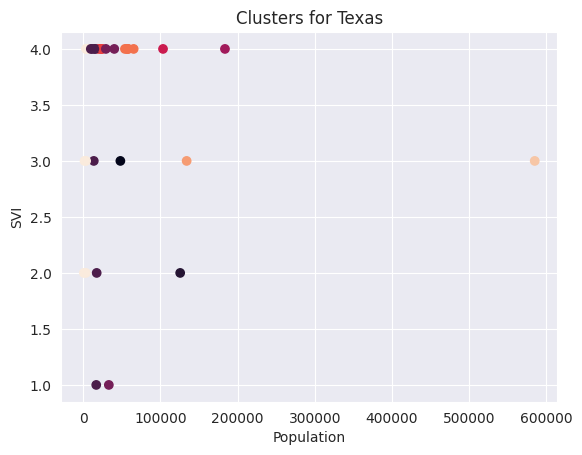

In [26]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
cluster_results = []
df=county_vaccines[county_vaccines['Date'].isin(['02-24-2021'])]
df=df[df['Recip_State'].isin(states)][['Recip_State','FIPS','SVI_CTGY','Census2019_12PlusPop']]
df=df.dropna()
for state, group in df.groupby('Recip_State'):
    X = group[['Census2019_12PlusPop', 'SVI_CTGY']].values

    if len(group) >= 1:  # At least 3 counties to cluster
        kmeans = KMeans(n_clusters=int(np.ceil(len(counties[state])/3)), random_state=0)
        group['Cluster'] = int(len(counties[state])/3)-kmeans.fit_predict(X)
    else:
        group['Cluster'] = -1  # Mark as unclustered

    cluster_results.append(group)
clustered_df = pd.concat(cluster_results)
state_df = clustered_df[clustered_df['Recip_State'] == 'NM']
plt.scatter(state_df['Census2019_12PlusPop'], state_df['SVI_CTGY'], c=state_df['Cluster'])
plt.title('Clusters for Texas')
plt.xlabel('Population')
plt.ylabel('SVI')
plt.show()

In [27]:
merged_df = pd.merge(clustered_df, pharmacies, on='FIPS', how='outer')
merged_df = merged_df.combine_first(clustered_df)

merged_df['size'] = merged_df.groupby('Cluster')['size'].transform(
    lambda x: x.fillna(x.median())
)
merged_df[merged_df['size'].isna()]
merged_df['size'] = merged_df['size'].fillna(merged_df['size'].median())
# Get average size for each cluster in Florida
fl_means = (
    merged_df[merged_df['Recip_State'] == 'FL']
    .groupby('SVI_CTGY')['size']
    .mean()
    .to_dict()
)
def fill_from_fl(row):
    if pd.isna(row['size']) and row['Recip_State'] == 'TX':
        return fl_means.get(row['SVI_CTGY'], row['size'])  # fallback to NaN if cluster not found
    else:
        return row['size']


merged_df['size'] = merged_df.apply(fill_from_fl, axis=1)

merged_df[merged_df['size'].isna()]
merged_df.update(merged_df[merged_df['size'].isna()].dropna())


/home/kimiya/.virtualenvs/Paper1_validation_Run/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/kimiya/.virtualenvs/Paper1_validation_Run/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/kimiya/.virtualenvs/Paper1_validation_Run/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/kimiya/.virtualenvs/Paper1_validation_Run/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [28]:
unique_counties=[]
for s in states:
    unique_counties.extend(counties[s])
local_centers={}
# clustered_df['pharmacies']=pharmacies[pharmacies['fips'].isin([x for x in unique_counties if x not in list(pharmacies['fips'].unique())])]
for s in states:
    for c in counties[s]:
        local_centers[s,c]=list(merged_df.loc[(merged_df['Recip_State']==s)&(merged_df['FIPS']==c)]['size'])[0]
    # for c in [x for x in counties[s] if x not in list(pharmacies['fips'].unique())]:
    #     print(pharmacies[pharmacies['fips'].isin([c])])

        # local_centers[s,c]=range(int(np.floor(3*popplus12[s,c]/10000)))
county_cap={}
shift=8
workdays=12
vacperhour=6
for s in states:
    for c in counties[s]:
        county_cap[s,c]=np.ceil(1*local_centers[s,c]*shift*workdays*vacperhour/Scale)

In [29]:
# pharmacies['EMPSZES_LABEL'].unique()
for s in states:
    for c in counties[s]:
        if np.isnan(local_centers[s,c]):
            print(s,c)
            # local_centers[s,c]=popplus12[s,c]/1000
for s in states:
    for c in counties[s]:
        if np.isnan(county_cap[s,c]):
            print(s,c)
            # county_cap[s,c]=5
            # local_centers[s,c]=popplus12[s,c]/1000


### Vaccine Demand and Hesitancy

### Data Preprocessing

In [30]:
hes_data=pd.read_csv(remote_path+'Vaccine_Hesitancy_for_COVID-19__County_and_local_estimates.csv')
hes_data['State']=hes_data['State'].astype(str)
hes_data['State']=hes_data['State'].map({k.upper(): v for k, v in state_abbreviations.items()})
hes_data=hes_data[hes_data['State'].isin(states)]
hes_data['FIPS Code']=hes_data['FIPS Code'].astype(str)
hes_data['FIPS Code']=hes_data['FIPS Code'].apply(lambda x: x.zfill(5) if len(x) == 4 else x)

print(len([x for x in set(hes_data['FIPS Code'].unique()) if x not in set(unique_counties)]))
print(len([x for x in set(unique_counties) if x not in set(hes_data['FIPS Code'].unique())]))

vac_hes={}
for s in states:
    for c in counties[s]:
        if c in list(hes_data['FIPS Code'].unique()):
            vac_hes[s,c]=hes_data.loc[hes_data['FIPS Code']==c]['Estimated hesitant or unsure'].values[0]
vac_hes['HI','15000']=0.098
vac_hes['AK','02060']=0.236
vac_hes['NY','35000']=0.065
est_demand={}

for s in states:
    for t in range(14):
        est_demand[t,s]=1/(14)*0.8*sum((1-vac_hes[s,c])*popplus12[s,c] for c in counties[s])/Scale


12
1


In [31]:
"""
Access Data from US News
"""
Access=[12,2,7,11,25,16,47,40,35,5,6,49,30,19,21,41,31,28,29,36,43,48,34,32,1,8,20,24,0,44,38,9,37,27,18,23,3,22,42,46,14,13,15,10,17,45,35,39,26,33,4]
access1={}
i=0
access={}
for s in states:
    access1[s]=50-Access[i]
    i+=1
access_log={}
for s in states:
    access_log[s]=np.log(access1[s])
for s in states:
    access_log[s]=access_log[s]/max(access_log.values())


In [32]:
# test_data = pd.read_csv('COVID-19_Diagnostic_Laboratory_Testing__PCR_Testing__Time_Series_20250710.csv')
# test_data
# test_data['date'] = pd.to_datetime(test_data['date'])
# test_data = test_data.sort_values(by=['state', 'overall_outcome', 'date'])
# tested_n = {}
# tested_i = {}
# tested_p = {}
# i = 0
# for s in states:
#     tested_n[s] = []
#     tested_i[s] = []
#     tested_p[s] = []
#     a = test_data[test_data['state'].isin([s])]
#     for t in list(dates0):
#         if len(a[(a['date'].isin([t])) & (a['overall_outcome'] == 'Negative')]['total_results_reported'].values) == 0:
#             tested_n[s].append(0)
#         else:
#             tested_n[s].append(
#                 a[(a['date'].isin([t])) & (a['overall_outcome'] == 'Negative')]['total_results_reported'].values[0])
#     for t in list(dates0):
#         if len(a[(a['date'].isin([t])) & (a['overall_outcome'] == 'Positive')]['total_results_reported'].values) == 0:
#             tested_p[s].append(0)
#         else:
#             tested_p[s].append(
#                 a[(a['date'].isin([t])) & (a['overall_outcome'] == 'Positive')]['total_results_reported'].values[0])
#     for t in list(dates0):
#         if len(a[(a['date'].isin([t])) & (a['overall_outcome'] == 'Inconclusive')][
#                    'total_results_reported'].values) == 0:
#             tested_i[s].append(0)
#         else:
#             tested_i[s].append(
#                 a[(a['date'].isin([t])) & (a['overall_outcome'] == 'Inconclusive')]['total_results_reported'].values[0])
#     i += 1
# tested_tot = {}
# for s in states:
#     tested_tot[s] = []
#     for t in range(0, 36):
#         tested_tot[s].append(
#             tested_p[s][t] + tested_i[s][t] + tested_n[s][t] - tested_p[s][t - 1] + tested_i[s][t - 1] + tested_n[s][
#                 t - 1])
#         print(s, state_cases00[s][t], tested_p[s][t], tested_i[s][t], tested_n[s][t], beta_s[s][t])
#
# stat_case_per = {}
# for s in states:
#     state_cases00[s][-1]=0
#     state_cases00[s][-2]=0
#     state_cases00[s][-3]=0
#     stat_case_per[s]=[]
#     for t in range(5,36):
#         stat_case_per[s].append((1.5*state_cases00[s][t-1]-1.5*state_cases00[s][t-5])/4)
#
# beta_log={}
# for s in states:
#     beta_log[s]=[]
#     for t in range(36):
#         beta_log[s].append(np.log(beta_s[s][t]*popplus12_s[s]))

### Defining Epidemic Parameters

In [33]:
effec=0.2
vac_eff=0.2
mu=14/(75*365)
gamma = 1
gamma1=1
reinf_rate=1/6
reinf_period=6
mu=14/75/365



### Calculating Effective Infection Rate

#### States

In [34]:
#Initial periods effective infection rate
state_cases00={}
dates0=[]
a= pd.to_datetime('2020-01-29')
for i in range(40):
    dates0.append(a)
    a=a+pd.Timedelta(days=14)
dates0.sort()
# Pre-filter by date
cases_filtered = state_cases_cdc[state_cases_cdc['end_date'].isin(dates0)]
cases_grouped = (
    cases_filtered
    .groupby(['state', 'end_date'])['tot_cases']  # Adjust column name if needed
    .sum()
    .unstack(fill_value=0)
)
state_cases00 = {state: cases_grouped.loc[state].tolist() for state in states}

cases_filtered=county_cases_merged[county_cases_merged['State'].isin(states)]
cases_filtered = cases_filtered[cases_filtered['date'].isin(dates0)]
# Group vaccines: sum doses per (state, county)

# Group cases: sum by (state, county, date), then get list per (state, county)
cases_grouped = (
    cases_filtered.sort_values('date')
    .groupby(['State', 'fips'])['cases']
    .apply(list)
)
infections0 = cases_grouped.to_dict()
cases_filtered['Days_Diff'] = cases_filtered.groupby('fips')['date'].diff().dt.days
delayed_data=list(cases_filtered.loc[cases_filtered['Days_Diff']!=14]['fips'].unique())
for s in states:
    for c in counties[s]:
        if c in delayed_data:
            while len(infections0[s,c])<25:
                infections0[s,c].insert(0,0)


In [35]:
coefs={}
for s in states:
    coefs[s]=1.5*state_cases00[s][23]/popplus12_s[s]
T =35
S0={}
V0={}
I0={}
beta_s={}
for s in states:
    beta_s[s]=[0 for t in range(T+4)]
beta={}
Vac={}
infs={}
inf1s={}
reinfection={}
underreported={}
for s in states:
    for t in range(-1,T+2):
        if t<=5:
            underreported[t,s]=1.5
        else:
            underreported[t,s]=1.5

for s in states:
    # S0[0,s] = S01[23,s]
    # I0[0,s]= I01[23,s]
    V0[0,s]=0
    Vac[0,s]=(1-coefs[s])*0
    Vac[0,s]=0
    S0[0,s] = popplus12_s[s]-1
    I0[0,s]= 1
    I0[-1,s]= 0
    state_cases00[s][-1]=0
epidemic_condition=1 #can be anything
for t in range(0,T+1):
    for s in states:
        if state_cases00[s][t+1]-state_cases00[s][t]<=0:
            I0[t+1,s] = (1-mu-gamma)*I0[t,s] + underreported[t+1,s]*epidemic_condition
        else:
            I0[t+1,s] = (1-mu-gamma)*I0[t,s] +underreported[t+1,s]*state_cases00[s][t+1]-underreported[t,s]*state_cases00[s][t]
for s in states:
    Vac[34,s]=0
    for t in range(24):
        Vac[-1,s]=0
        Vac[t,s]=0

    for t in range(24,T-1):
        Vac[t,s]= (1-coefs[s])*(state_vaccine[s][t-23]-state_vaccine[s][t-24])


x={}
reinfection={}
for t in range(0,T+1):
    for s in states:
        x[t,s]=[]
        if t<=6:
            reinfection[t,s]=0
            # reinfection[t,s]=reinf_rate*1.5*(state_cases00[s][t-reinf_period]-state_cases00[s][t-1-reinf_period])*0
        else:
            reinfection[t,s]=reinf_rate*beta_s[s][t-reinf_period]*S0[t-reinf_period,s]*I0[t-reinf_period,s]
            reinfection[t,s]=reinf_rate*(underreported[t+1-reinf_period,s]*state_cases00[s][t+1-reinf_period]-underreported[t-reinf_period,s]*state_cases00[s][t-reinf_period])
        a = np.array([[effec*I0[t,s]*V0[t,s], 1, 0], [(I0[t,s]*S0[t,s] +vac_eff*I0[t,s]*V0[t,s]),0, 0],[(I0[t,s]*S0[t,s]),0, 1]])
        if state_cases00[s][t+1]-state_cases00[s][t]>0:
            b = np.array([((1-mu)*V0[t,s] +Vac[t-gamma1,s]) , I0[t+1,s]-(1-mu-gamma)*I0[t,s],(1-mu)*S0[t,s] +mu - Vac[t-gamma1,s]+reinfection[t,s]])
        else:
            b = np.array([((1-mu)*V0[t,s] +Vac[t-gamma1,s]) , underreported[t+1,s]*epidemic_condition,(1-mu)*S0[t,s] +mu - Vac[t-gamma1,s]+reinfection[t,s]])
        x[t,s] = list(np.linalg.solve(a, b))
        [beta_s[s][t],V0[t+1,s],S0[t+1,s]]=x[t,s]
for s in states:
    for t in range(23,38):
        beta[t-23,s]=beta_s[s][t]
print(beta)
S0101={}
I0101={}
for s in states:
    S0101[0,s]=S0[23,s]
    I0101[0,s]=I0[23,s]

{(0, 'AL'): np.float64(2.82149776690521e-07), (1, 'AL'): np.float64(2.907630063867531e-07), (2, 'AL'): np.float64(1.9742366872370688e-07), (3, 'AL'): np.float64(2.026456211197887e-07), (4, 'AL'): np.float64(1.5370539267290733e-07), (5, 'AL'): np.float64(2.4138243862538206e-07), (6, 'AL'): np.float64(3.172648920318665e-07), (7, 'AL'): np.float64(1.3869695376067564e-07), (8, 'AL'): np.float64(4.854450889504145e-07), (9, 'AL'): np.float64(2.6843216953723955e-07), (10, 'AL'): np.float64(8.414682647420197e-07), (11, 'AL'): np.float64(1.2970773162010016e-07), (12, 'AL'): np.float64(4.155843604922628e-07), (13, 'AL'): 0, (14, 'AL'): 0, (0, 'AK'): np.float64(9.070177954926128e-07), (1, 'AK'): np.float64(1.8926544892947025e-06), (2, 'AK'): np.float64(1.2067757081785232e-06), (3, 'AK'): np.float64(1.4616222571303961e-06), (4, 'AK'): np.float64(1.7433552144216196e-06), (5, 'AK'): np.float64(2.2788873198626355e-06), (6, 'AK'): np.float64(2.3589005021546385e-06), (7, 'AK'): np.float64(3.10648760191

In [36]:
T=12


wills={}
for s in states:
    wills[s]=(1-coefs[s])*state_vaccine[s][T-1]/popplus12_s[s]
    if (wills[s]>=1):
        wills[s]=1

coef_c={}
inf_will={}
for s in states:
    for c in counties[s]:
        inf_will[s,c]=1-vac_hes[s,c]
        coef_c[s,c]=1.5*infections[s,c][0]/popplus12[s,c]
        for t in range(0,T):
            if vaccination[s,c][t] >= popplus12[s,c]:
                print(s,c)
                vaccination[s,c][t]=popplus12[s,c]
will={}
for s in states:
    for c in counties[s]:
        will[s,c]=[(1-coef_c[s,c])*vaccination[s,c][T-2]/popplus12[s,c]]
        if (will[s,c][0]>=1):
            will[s,c][0]=1
o=0


# print(beta_c0)

S00={}
V00={}
I00={}
beta_c={}
beta_c1={}
Vac_c={}
# inf={}
# inf1={}
epidemic_condition={}
for s in states:
    for c in counties[s]:
        epidemic_condition[s,c]=np.ceil(0.00001*popplus12[s,c])
for s in states:
    for c in counties[s]:
        if (infections[s,c][1]-infections[s,c][0])<=0:
            if infections[s,c][0]==0:
                hzero=1
            else:
                hzero=0
            S00[0,s,c] = popplus12[s,c]-(1-reinf_rate)*underreported[t+23,s]*infections[s,c][0]- hzero*epidemic_condition[s,c]
            I00[0,s,c]= reinf_rate* underreported[t+23,s]*infections[s,c][0]+hzero*epidemic_condition[s,c]
        else:
            S00[0,s,c] = popplus12[s,c]-(1-reinf_rate)*underreported[t+23,s]*(infections[s,c][1])
            I00[0,s,c]= underreported[t+23,s]*(infections[s,c][1]-infections[s,c][0])
        Vac_c[-1,s,c]=0
        V00[0,s,c]=0
        Vac_c[0,s,c]=(1-coef_c[s,c])*(vaccination[s,c][1]-vaccination[s,c][0])
for t in range(0,T):
    for s in states:
        for c in counties[s]:
            # if t>=3:
            #     epidemic_condition=underreported[t+23,s]*(infections[s,c][t-1]-infections[s,c][t-2])
            # else:
            epidemic_condition[s,c]=np.ceil(0.00001*popplus12[s,c])
            if infections[s,c][t]-infections[s,c][t-1]<=0:
                I00[t+1,s,c] = (1-mu-gamma)*I00[t,s,c] + epidemic_condition[s,c]
            else:
                I00[t+1,s,c] = (1-mu-gamma)*I00[t,s,c] + underreported[t+23,s]*(infections[s,c][t+1]-infections[s,c][t])
            # I00[t+1,s,c] = infections[s,c][t+8+1]
            if (vaccination[s,c][t]-vaccination[s,c][t-1])<=0:
                Vac_c[t,s,c]=0
            else:
                Vac_c[t,s,c]= (1-coef_c[s,c])*(vaccination[s,c][t]-vaccination[s,c][t-1])

x={}
reinfection={}
for t in range(0,T):
    for s in states:
        for c in counties[s]:
            x[t,s,c]=[]
            if t>=7:
                reinfection[t,s,c]=(reinf_rate)*1.5*(infections[s,c][t-6]-infections[s,c][t-7])
            else:
                reinfection[t,s,c]=0
            if ((infections[s,c][t+1]-infections[s,c][t])<=0):
                epidemic_condition[s,c]=1
                a = np.array([[vac_eff*I00[t,s,c]*V00[t,s,c], 1, 0], [(I00[t,s,c]*S00[t,s,c] +vac_eff*I00[t,s,c]*V00[t,s,c]),0, 0],[(I00[t,s,c]*S00[t,s,c]),0, 1]])
                b = np.array([((1-mu)*V00[t,s,c] +Vac_c[t-gamma1,s,c]) , 1*epidemic_condition[s,c],(1-mu)*S00[t,s,c] +mu - Vac_c[t-gamma1,s,c]+reinfection[t,s,c]])
            else:
                a = np.array([[vac_eff*I00[t,s,c]*V00[t,s,c], 1, 0], [(I00[t,s,c]*S00[t,s,c] +vac_eff*I00[t,s,c]*V00[t,s,c]),0, 0],[(I00[t,s,c]*S00[t,s,c]),0, 1]])
                b = np.array([((1-mu)*V00[t,s,c] +Vac_c[t-gamma1,s,c]) , underreported[t+23,s]*(infections[s,c][t+1]-infections[s,c][t]),(1-mu)*S00[t,s,c] +mu- Vac_c[t-gamma1,s,c]+reinfection[t,s,c]])
            x[t,s,c] = list(np.linalg.solve(a, b))
            [beta_c[t,s,c],V00[t+1,s,c],S00[t+1,s,c]]=x[t,s,c]
            if S00[t+1,s,c]<0:
                S00[t+1,s,c]=0
for s in states:
    for c in counties[s]:
        for t in range(0,T+1):
            if S00[t,s,c] <0:
                print(S00[t,s,c],I00[t,s,c],beta_c[t,s,c],beta_c[t-1,s,c]*popplus12[s,c],s,c,t,infections[s,c][t],infections[s,c][t],infections[s,c][t-1],popplus12[s,c],vaccination[s,c][t])
                o+=1
beta_c0={c:beta_c[0,s,c] for s in states for c in counties[s]}

GA 13053
GA 13053
GA 13053
GA 13053
GA 13053


### Knapsack Weights

       FIPS      Beta  SVI  Population
0     01001  0.000024   60       47574
1     01003  0.000006   40      192649
2     01005  0.000051  100       21404
3     01007  0.000058   80       19480
4     01009  0.000023   60       49234
...     ...       ...  ...         ...
3126  56037  0.000032   60       35200
3127  56039  0.000056   40       20665
3128  56041  0.000068   60       16531
3129  56043  0.000172   60        6764
3130  56045  0.000185   60        6005

[3131 rows x 4 columns]


/tmp/ipykernel_160426/1984014557.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['FIPS']=dataset['FIPS'].astype(int)
/tmp/ipykernel_160426/1984014557.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['FIPS']=dataset['FIPS'].astype(int)
/tmp/ipykernel_160426/1984014557.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

{('AL', '01001'): 0.006287268604787935, ('AL', '01003'): 0.008581549976780723, ('AL', '01005'): 0.017478693135628106, ('AL', '01007'): 0.012576976868857769, ('AL', '01009'): 0.006288208693727406, ('AL', '01011'): 0.021413778303128128, ('AL', '01013'): 0.018039013324071346, ('AL', '01015'): 0.017252807111855818, ('AL', '01017'): 0.011816069278517485, ('AL', '01019'): 0.00729471879190264, ('AL', '01021'): 0.017006649417753886, ('AL', '01023'): 0.019339017152943467, ('AL', '01025'): 0.017673631720673877, ('AL', '01027'): 0.015028894560196538, ('AL', '01029'): 0.014233502910782916, ('AL', '01031'): 0.011520638926827434, ('AL', '01033'): 0.006297886985085444, ('AL', '01035'): 0.01989734075087788, ('AL', '01037'): 0.015956155316451857, ('AL', '01039'): 0.017102666636956882, ('AL', '01041'): 0.0147039332136285, ('AL', '01043'): 0.011617294826193796, ('AL', '01045'): 0.016976224111302132, ('AL', '01047'): 0.01710056607863136, ('AL', '01049'): 0.016982256746607912, ('AL', '01051'): 0.0115991052

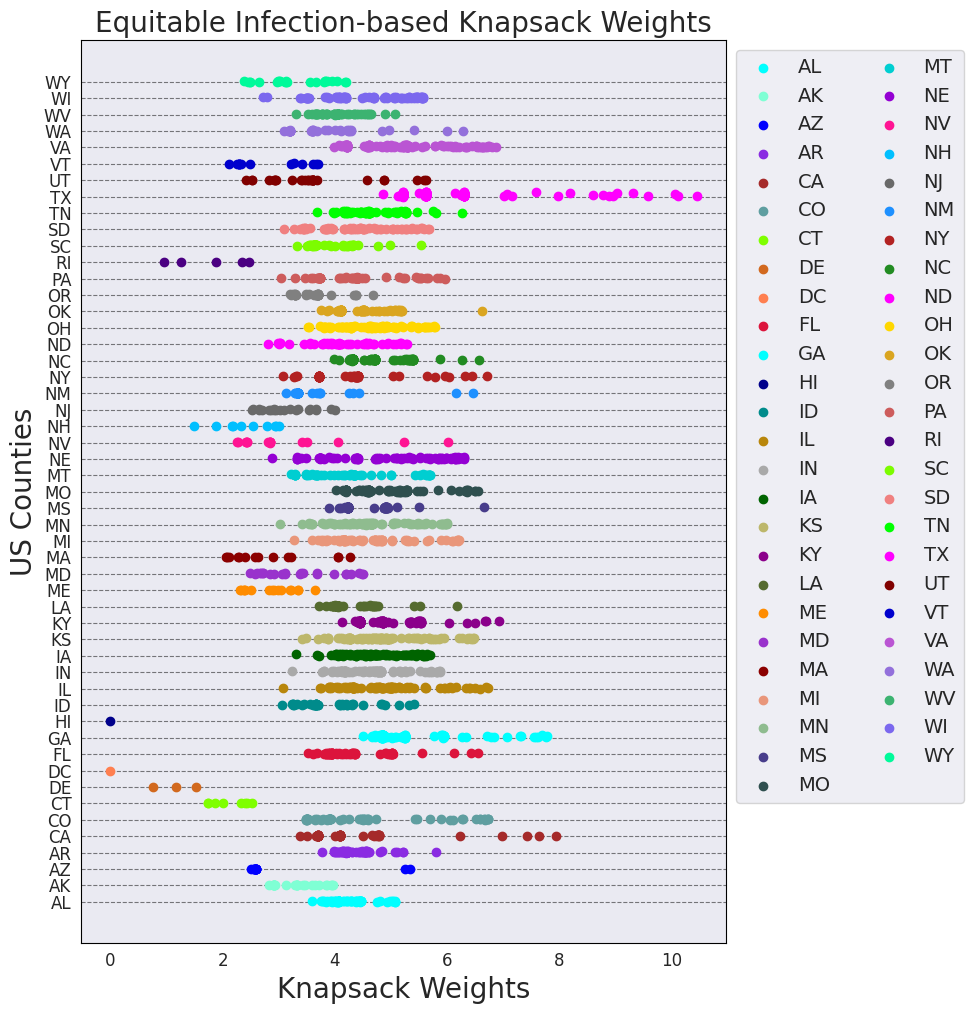

[0.022988361076252226, 0.03276378132044766, 0.025918781681699105, 0.024158361202274756, 0.03286270606354062, 0.020335449724983173, 0.0047594424604216114, 0.019250107353385483, 0.02864713802753391, 0.03106797033485163, 0.027056517556437364, 0.015466131695991545, 0.014844636051089561, 0.020289991821268134, 0.01759711096146703, 0.007769377928294867, 0.012853338091157188, 0.013459813064949424, 0.013350193040783694, 0.020417729409830013, 0.006061453888749829, 0.005487717970074664, 0.011577164071178231, 0.011002591670310178, 0.02987815758524407, 0.025176368679070943, 0.02268057780677885, 0.017450195262776448, 0.030083564081358104, 0.014411405326411223, 0.009302932415883874, 0.025365069223385137, 0.016202844588321146, 0.015333040131666729, 0.024672927703487568, 0.017816215616737775, 0.028370143691113823, 0.01683845128168236, 0.010348295621259399, 0.01635311251824256, 0.021826544423760322, 0.02820497806343476, 0.02119044859365423, 0.031519752296260896, 0.02033153191149393, 0.02961099098220018,

<Figure size 640x480 with 0 Axes>

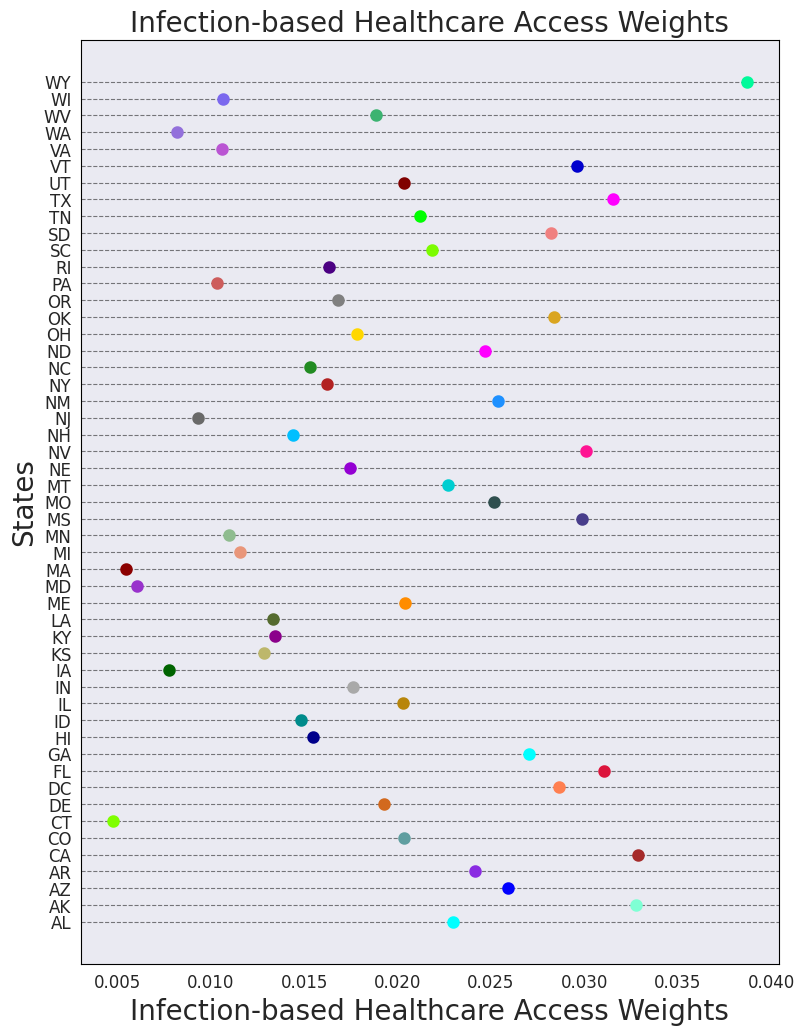

[0.02864713802753391]
1.0
{'AL': 0.022988361076252226, 'AK': 0.03276378132044766, 'AZ': 0.025918781681699105, 'AR': 0.024158361202274756, 'CA': 0.03286270606354062, 'CO': 0.020335449724983173, 'CT': 0.0047594424604216114, 'DE': 0.019250107353385483, 'DC': 0.02864713802753391, 'FL': 0.03106797033485163, 'GA': 0.027056517556437364, 'HI': 0.015466131695991545, 'ID': 0.014844636051089561, 'IL': 0.020289991821268134, 'IN': 0.01759711096146703, 'IA': 0.007769377928294867, 'KS': 0.012853338091157188, 'KY': 0.013459813064949424, 'LA': 0.013350193040783694, 'ME': 0.020417729409830013, 'MD': 0.006061453888749829, 'MA': 0.005487717970074664, 'MI': 0.011577164071178231, 'MN': 0.011002591670310178, 'MS': 0.02987815758524407, 'MO': 0.025176368679070943, 'MT': 0.02268057780677885, 'NE': 0.017450195262776448, 'NV': 0.030083564081358104, 'NH': 0.014411405326411223, 'NJ': 0.009302932415883874, 'NM': 0.025365069223385137, 'NY': 0.016202844588321146, 'NC': 0.015333040131666729, 'ND': 0.024672927703487568,

In [37]:
##################################################Clustering


county_pop=[]
SVInew=[]
for s in states:
    for c in beta_c0.keys():
        if c in counties[s]:
            county_pop.append(int(popplus12[s,c]))
            SVInew.append(int(SVI[s,c]*20+20))
data=pd.DataFrame( columns=['FIPS','Beta','SVI','Population'])
data['FIPS']=beta_c0.keys()
data['Population']=county_pop
data['Beta']=beta_c0.values()
data['SVI']=SVInew
print(data)
list1=[]
list2=[]
list3=[]
colors = [
    'Aqua', 'Aquamarine', 'Blue', 'BlueViolet', 'Brown', 'CadetBlue', 'Chartreuse', 'Chocolate',
    'Coral', 'Crimson', 'Cyan', 'DarkBlue', 'DarkCyan', 'DarkGoldenRod', 'DarkGray', 'DarkGreen',
    'DarkKhaki', 'DarkMagenta', 'DarkOliveGreen', 'DarkOrange', 'DarkOrchid', 'DarkRed',
    'DarkSalmon', 'DarkSeaGreen', 'DarkSlateBlue', 'DarkSlateGray', 'DarkTurquoise', 'DarkViolet',
    'DeepPink', 'DeepSkyBlue', 'DimGray', 'DodgerBlue', 'FireBrick', 'ForestGreen', 'Fuchsia',
    'Gold', 'GoldenRod', 'Gray', 'IndianRed', 'Indigo', 'LawnGreen', 'LightCoral', 'Lime',
    'Magenta', 'Maroon', 'MediumBlue', 'MediumOrchid', 'MediumPurple', 'MediumSeaGreen',
    'MediumSlateBlue', 'MediumSpringGreen'
]

d={}
%matplotlib inline

for s in states:
    list1=[]
    list2=[]
    list3=[]
    dataset=data.loc[data.isin(counties[s])['FIPS']==True]
    dataset['FIPS']=dataset['FIPS'].astype(int)
    dataset= dataset.apply(zscore)
    list1=list(dataset['SVI'])
    list2=list(dataset['Beta'])
    list3=list(dataset['Population'])
    for c in range(0,len(counties[s])):
        list1[c]-=min(list(dataset['SVI']))
        list2[c]-=min(list(dataset['Beta']))
        list3[c]-=min(list(dataset['Population']))
    #Check the head after scaling
    # print(dataset)
    labelList = list(dataset['FIPS'].unique())
    for c in range(0,len(counties[s])):
        if s=='DC':
            d['DC', '11001']=1
        elif s=='HI':
            d['HI', '15000']=1
        else:
            d[s,counties[s][c]]=(((list1[c]/max(list1))**2+(list2[c]/max(list2))**2+(list3[c]/max(list2))**2)**(0.5))/sum(((list1[c]/max(list1))**2+(list2[c]/max(list2))**2+(list3[c]/max(list2))**2)**(0.5) for c in  range(0,len(counties[s])))
print(d)


# Sample dictionary
ordered_counties={}
data1={}
weights={}
plt.figure(facecolor='none',figsize=(10, 12))
# fig(figsize=(6, 10))
tick=[]
num=1
for s in states:
    # data={}

    data1[s]=[]
    ordered_counties[s]=[]
    for c in counties[s]:
        data1[s].append(-np.log(d[s,c]))
        ordered_counties[s].append(-np.log(d[s,c]))
        weights[s,c]=d[s,c]
    x = range(num*1000,num*1000+len(counties[s]))
    y = data1[s]
    print(data1[s])
    # Create a scatter plot

    plt.scatter(y, x,label=f'{s}',c=colors[num-1],linewidth=1)
    plt.grid(False)
    plt.ylabel('US Counties',fontsize=20)
    plt.xlabel('Knapsack Weights',fontsize=20)

    plt.title('Equitable Infection-based Knapsack Weights',fontsize=20)
    plt.gcf().set_facecolor('white')
    # Move the legend outside the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1),fontsize=14,ncol=2)

    # Adjust layout to make space for the legend
    plt.tight_layout(rect=[0, 0, 1, 0.85])

    # Show the plot
    #
    # data1.clear()
    tick.append(num*1000)
    num+=1
    # cmap='viridis')
# plt.scatter(1.2,1000)

# for s in states:
#     tick.append(num*1000)
plt.yticks(ticks=tick,labels=states,fontsize=12
           )
plt.xticks(fontsize=12)
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.grid(axis='y', linestyle='--', alpha=0.5,color='black')  # Customize style and transparency

print(ordered_counties)
# plt.legend(loc=1,fontsize=6)
plt.show()

access=access1
beta_0=[beta[0,s] for s in states]
states_pop=[]
for s in states:
    states_pop.append(popplus12_s[s])
data_s=pd.DataFrame( columns=['State','Beta_s','Access','Population_s'])

data_s['State']=states
data_s['Population_s']=states_pop
data_s['Beta_s']=beta_0
data_s['Access']=access.values()
d_s=[]

list10=[]
list20=[]
list30=[]
dataset0=data_s.drop('State',axis=1)
dataset0 = dataset0.apply(zscore)
dataset0.insert(0,'State',states)

list10=list(dataset0['Access'])
list20=list(dataset0['Beta_s'])
list30=list(dataset0['Population_s'])
for s in range(0,len(states)):
    list10[s]-=min(list(dataset0['Access']))
    list20[s]-=min(list(dataset0['Beta_s']))
    list30[s]-=min(list(dataset0['Population_s']))
#Check the head after scaling
for s in range(0,len(states)):
    d_s.append((((list10[s]/max(list10))**2+(list20[s]/max(list20))**2+(list30[s]/max(list30))**2)**(0.5))/sum(((list10[s]/max(list10))**2+(list20[s]/max(list20))**2+(list30[s]/max(list30))**2)**(0.5) for s in  range(0,len(states))))
    #d_s.append(((list10[s]**2+list20[s]**2)**(0.5))/sum((list10[s]**2+list20[s]**2)**(0.5) for s in  range(0,len(states))))
print(d_s)
        # d.loc[d["FIPS"]==counties[s][c]]["Distance"]=(list1[c]**2+list2[c]**2+list3[c]**2)**(0.5)
# print(d['DC', 11001])
# print(counties['DC'])

# Sample dictionary
ordered_states={}
data1={}
# weights={}

# data={}
data10=[]
T1=0
T2=T
for s in range(len(states)):
    ordered_states[states[s]]=[]
    data10.append(d_s[s])
    ordered_states[states[s]].append(d_s[s])
print(data10)
x = states
y = data10
# print(data1[s]),
# Create a scatter plot
fig = plt.figure(facecolor='white')
plt.figure(figsize=(9, 12))
n=0
for s in states:
    plt.scatter(y[n], x[n],c=colors[n],label=f'{s}',linewidth=3)
    n+=1
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
# Add labels and title
plt.grid(False)
plt.ylabel('States',fontsize=20)
# ax.spines['bottom'].set_color('black')  # Bottom x-axis
# ax.spines['left'].set_color('black')    # Left y-axis
# ax.spines['top'].set_color('black')     # Top axis (optional)
# ax.spines['right'].set_color('black')
# plt.gcf().set_axis_off()
plt.rcParams['axes.facecolor'] = 'none'
# plt.box()
# plt.xlim(0,0.06)
# plt.ylim()
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
plt.xlabel('Infection-based Healthcare Access Weights',fontsize=20)
plt.title('Infection-based Healthcare Access Weights',fontsize=20)
plt.gcf().set_facecolor('none')
# plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5),fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5,color='black')  # Customize style and transparency

# Show the plot
plt.show()
print(ordered_states['DC'])

access={}
i=0
for s in states:
    access[s]=d_s[i]
    i+=1
print(sum(access[s] for s in states))
print(access)

## Model Implementation Parameters

In [38]:
B=[500000,200000,750000,1000000,1200000]


M = 1000000000/10000
supply=1000000/10000
cost_param=pd.DataFrame({"w":[1,1,1,1],
                "g":[1,1,1,1],
                "c":[20,20,19,15]})
actual_beta = {}
for s in states:
    for t in range(0, 14):
        actual_beta[t, s] = beta[t, s]
T = 12
T1=0
T2=T


tau={}
Scale = 10000
for s in states:
    i=0
    tau[s]=0.01*(popplus12_s[s])/Scale
    i+=1
T1=0
T2=T
M = 100000000000/Scale
supply=1000000/Scale
Demand={}
for t in range(0,10):
    for s in states:
        Demand[t,s]=est_demand[t,s]
mu=mu/Scale
time=range(12)

## Model Validation

### Model Validation 1

In [42]:
wastage=0
time=range(12)
sol_time={}
T=12
S={}
V={}
I={}
R={}
Vac={}
reinf={}
Results={}
mu=14/75/365
model0 = gp.Model()
model0.reset()

for s in states:
    for t in range(0,T+1):
        S[t,s] = model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
    for t in range(-1,T):
        Vac[t,s] = model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[0, s] == S0101[0,s],name=f'S0{s}')
    model0.addConstr(V[0, s] == 0,name=f'V0{s}')
    model0.addConstr(I[0, s] == I0101[0,s],name=f'I0{s}')
for s in states:
    model0.addConstr(Vac[-1, s] == 0,name=f'Vac0{s}')
    model0.addConstr(Vac[0, s] == 0,name=f'Vac0{s}')
    model0.addConstr(Vac[T-1, s] == 0,name=f'Vac0{s}')
    for t in range(1,T-1):
        model0.addConstr(Vac[t, s] == (state_vaccine[s][t]-state_vaccine[s][t-1]),name=f'V{t,s}')
    for t in range(0,T):
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*beta[t,s]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + beta[t,s]*S[t,s] *I[t,s]+effec*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
        if t>=reinf_period:
            model0.addConstr(reinf[t,s]==reinf_rate*(beta[t-reinf_period,s]*S[t-reinf_period,s] *I[t-reinf_period,s]))
        else:
            model0.addConstr(reinf[t,s]==(reinf_rate*(underreported[t+24-reinf_period,s]*state_cases00[s][24+t-reinf_period]-underreported[t+24-1-reinf_period,s]*state_cases00[s][24+t-1-reinf_period])))
model0.setObjective(0*sum((beta[t,s] * S[t, s] * I[t, s] + effec*beta[t,s] *  V[t, s] * I[t, s]) for t in range(0, T) for s in states), GRB.MAXIMIZE)
# model0.setObjective(sum(I[T2,s] for s in states) , GRB.MINIMIZE)
# Set optimization parameters
#
model0.setParam(GRB.Param.Heuristics, 0)

# model0.Params.TIME_LIMIT = 3600*24
# model0.setParam(GRB.Param.PoolSearchMode, 2)      # Find multiple solutions
# model0.setParam(GRB.Param.PoolSolutions, 2)
model0.reset()
model0.optimize()
model0.getObjective()
if model0.status == GRB.INFEASIBLE:

    model0.computeIIS()
    model0.write("model.ilp")
    for c in model0.getConstrs():
        if c.IISConstr:
            print(f"Infeasible constraint: {c.constrName}")

    for v in model0.getVars():
        if v.IISLB:
            print(f"Infeasible lower bound: {v.varName}")
        if v.IISUB:
            print(f"Infeasible upper bound: {v.varName}")
else:
    inf={(t,s): (beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x) for t in range(0, T) for s in states  }
    print(sum((beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x) for t in range(0, T) for s in states ))

    Vac_i={(t, s): Vac[t, s].x for t in range(T1-1,T2-1)  for s in states }
    vac_r={}
    for s in states:
        for t in range(T1,T2):
            if sum(Vac[t-1, s].x for s in states)==0:
                vac_r[t-1,s]=0
            else:
                vac_r[t-1,s]=(Vac[t-1, s]).x/sum(Vac[t-1, s].x for s in states)
    S1={(t, s): S[t, s].x for t in range(T1+1,T2+1)  for s in states }
    I1={(t, s): I[t, s].x for t in range(T1+1,T2+1)  for s in states }
    V1={(t, s): V[t, s].x for t in range(T1+1,T2+1) for s in states }
    Vac_df=pd.DataFrame({"States":states})
    sol_time[T1]=model0.Runtime


Set parameter Username
Academic license - for non-commercial use only - expires 2026-12-14
Discarded solution information
Set parameter Heuristics to value 0
Discarded solution information
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: Intel(R) Xeon(R) Gold 6326 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 32 threads

Non-default parameters:
Heuristics  0

Optimize a model with 1122 rows, 3315 columns and 1122 nonzeros
Model fingerprint: 0xfe130187
Model has 2142 quadratic constraints
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  QMatrix range    [3e-09, 4e-06]
  QLMatrix range   [5e-04, 1e+00]
  Objective range  [0e+00, 0e+00]
  Bounds range     [5e+05, 3e+07]
  RHS range        [2e+01, 3e+07]
  QRHS range       [5e-04, 5e-04]
Presolve removed 1122 rows and 1785 columns

Continuous model is non-convex -- solving as a MIP

Presolve removed 1122 rows 

In [ ]:
for s in states:
    print(s,beta[0,s],I0101[0,s],S0101[0,s],popplus12_s[s])

In [ ]:
for s in states:
    for t in range(12):
        print(s,t,beta[t,s],S[t,s].x,I[t,s].x,V[t,s].x,Vac[t,s].x,reinf[t,s].x,Scale*beta[t,s]*S[t,s].x*I[t,s].x)
sum(Scale*beta[t,s]*S[t,s].x*I[t,s].x+effec*Scale*beta[t,s]*V[t,s].x*I[t,s].x for s in states for t in range(0,12))
# sum(Vac[t,s].x for s in states for t in range(T))

In [ ]:

actual_values={}
optimized_values={}
for s in states:
    actual_values[s]=[]
    optimized_values[s]=[]
    for t in range(0,12):
        optimized_values[s].append((beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x))
        actual_values[s].append(1.5*(state_cases00[s][24+t]-state_cases00[s][23+t]))
        print(s,(optimized_values[s][t]-actual_values[s][t])/actual_values[s][t]*100)

print(sum(beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x for s in states for t in range(0, 12)),sum(1.5*(state_cases00[s][24+t]-state_cases00[s][23+t]) for s in states for t in range(0,12)))

# Simulated data for demonstration
# Plot 1: Total Actual vs. Optimized Results
fig, ax = plt.subplots(figsize=(8, 8))

actual_time = []
optimized_time = []

for t in range(12):
    actual_time.append(sum(actual_values[s][t] for s in states))
    optimized_time.append(sum(optimized_values[s][t] for s in states))

ax.plot(actual_time, optimized_time, linewidth=2.0, label="Total Results")
ax.set_facecolor("white")
ax.set(xlim=(1000000, 5000000),
       ylim=(1000000, 5000000))
ax.set_title('Comparison of Total Actual vs. Optimized Results', fontsize=20)
ax.set_xlabel('Actual Results (million cases)', fontsize=20)
ax.set_ylabel('Optimized Results (million cases)', fontsize=20)

# Customize spines
for spine in ax.spines.values():
    spine.set_color('black')
plt.tick_params(labelsize=14)
# Legend outside
# ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
# plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout for legend space
plt.grid(True)
plt.show()

# Plot 2: Individual State Comparison
fig, ax = plt.subplots(figsize=(9, 8))

for s in states:
    ax.plot(actual_values[s], optimized_values[s], linewidth=1.5, label=s)

ax.set_facecolor("white")
ax.set(xlim=(0, 500000), xlabel="Actual Results (million cases)",
       ylim=(0, 500000), ylabel="Optimized Results (million cases)")
ax.set_title('Comparison of State Actual vs. Optimized Results', fontsize=20)
ax.set_xlabel('Actual Results (million cases)', fontsize=20)
ax.set_ylabel('Optimized Results (million cases)', fontsize=20)

# Customize spines
for spine in ax.spines.values():
    spine.set_color('black')
plt.tick_params(labelsize=14)
# Legend outside
# ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=8)
plt.legend(fontsize=12,ncol=2,loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout for legend space
plt.grid(True)
plt.show()

# Sample data: Two sets of related data (e.g., before and after measurements)
before = {}
after = {}
for t in range(0,T):
    before[t]=[]
    after[t]=[]
    before[t].append(sum(actual_values[s][t] for s in states))
    after[t].append(sum(optimized_values[s][t]for s in states))
# Perform paired t-test
for t in range(0,T):
    t_stat, p_value = stats.ttest_rel(before[t], after[t])
    if p_value<0.025:
        print(f"T-statistic: {t_stat}",t)
        print(f"P-value: {p_value}")
for s in states:
    t_stat, p_value = stats.ttest_rel(actual_values[s], optimized_values[s],alternative='two-sided')
    if p_value<0.025:
        print(f"T-statistic: {t_stat}",s)
        print(f"P-value: {p_value}")



### Model Validation 2

In [ ]:
from pmdarima import auto_arima

historical_beta={}
for s in states:
    historical_beta[s]={}
    for t in range(5,24):
        historical_beta[s][dates0[t]]=np.log(beta_s[s][t]*popplus12_s[s]*10)
df=pd.DataFrame(historical_beta)
best_m_value={}
p=0
# m_mode=[6,11,5,11,6,5,5,5,6,5,6,11,3,4,5,3,3,7,5,5,6,5,6,5,4,3,4,5,6,6,6,4,6,4,6,4,5,5,6,6,4,5,5,6,5,4,6,6,2,6,2]
m_mode=[10,15,15,16,16,8,12,16,8,8,16,16,8,6,8,4,6,8,8,10,8,16,8,8,16,8,8,8,8,16,16,8,16,10,8,8,8,10,10,8,16,16,16,16,8,10,10,10,16,16,8]
for s in states:
    best_m_value[s]=m_mode[p]
    p+=1

m=12
suggested_m = {
    "ME": 5,  # Includes significant lags and some residual patterns
    "NH": 6,  # Captures early oscillations and significant correlations
    "NJ": 8,  # Includes significant and oscillatory lags
    "NY": 8,  # Captures meaningful lags and persistent negative correlations
    "PA": 6,  # Balances capturing structure with simplicity
    "CT": 7,  # Includes extended significant lags
    "RI": 6,  # Captures early dependencies
    "VT": 5,  # Focuses on sharp declines and initial correlations
    "MA": 7,  # Captures significant lags and minor oscillations
    "MD": 6,  # Balances capturing dependencies without overfitting
    "DC": 6,  # Includes significant patterns without unnecessary lags
    "DE": 5   # Accounts for dependencies and early oscillations
}
suggested_m = {
    'ME': 2,
    'NH': 2,
    'NJ': 2,
    'NY': 2,
    'PA': 2,
    'CT': 2,
    'RI': 1,
    'VT': 6,
    'MA': 2,
    'MD': 2,
    'DC': 1,
    'DE': 2
}


def SARIMA(s):
    date_range = range(5,24)
    time_series = pd.Series(list(df[s]), index=date_range)

    # Plot the time series data
    time_series.plot(title="Time Series Data")
    plt.show()
    m=2
    if s in ['DC']:
        m=5
    if s in ['NY']:
        m=6
    if s in ['DE',  'NH', 'VT']:
        m=10
    if s in ['NJ', 'ME', 'RI']:
        m=11
    # m=6
    # Step 1: Automatically find the best SARIMA model
    model = auto_arima(time_series, seasonal=True, m=  3,  # 'm=12' for monthly seasonality
                       trace=True,  # Show the iterations
                       error_action='ignore',  # Ignore certain warnings
                       suppress_warnings=True,  # Suppress warnings
                       stepwise=True)  # Stepwise fit for fast computation

    # Print the best model summary
    print(model.summary())

    # Step 2: Fit the model
    sarima_model = SARIMAX(time_series,
                           order=model.order,
                           seasonal_order=model.seasonal_order)
    sarima_result = sarima_model.fit()

    # Print the fitted model summary
    print(sarima_result.summary())
    sigma[s]=sarima_result.scale
    # Step 3: Forecast for the next 11 periods
    forecast = sarima_result.get_forecast(steps=20)
    forecast_values[s] = forecast.predicted_mean
    confidence_intervals[s] = forecast.conf_int()

    # forecast_range[s] = max(predicted_mean) - min(predicted_mean)
    # Plot the forecast
    plt.figure(figsize=(10, 6))
    plt.plot(time_series, label='Observed')
    plt.plot(forecast_values[s], label='Forecast', color='red')
    plt.fill_between(forecast_values[s].index,
                     confidence_intervals[s].iloc[:, 0],
                     confidence_intervals[s].iloc[:, 1], color='pink', alpha=0.3)
    plt.title(f'Forecast with SARIMA Model with seasonality {m} in state {s}')
    plt.legend()
    plt.savefig(f'state{s}-SARIMA-final-{m}.png')
    plt.show()
    plot_acf(time_series, lags=18)
    plt.title(f'ACF in state {s}')
    plt.savefig(f'state{s}-ACF-{m}.png')
    plt.show()
    # Print the forecasted values
    print(forecast_values[s])
# Simulated example: Replace this with real data loading for each state.

    # Plot PACF for each state with adjusted lags
    fig, ax = plt.subplots(figsize=(6, 4))
    plot_pacf(time_series, ax=ax, method='ywmle', lags=8, zero=False)  # Adjust lags as needed
    ax.set_title(f"PACF in state {s}")
    plt.show()

plt.show()

sigma = {}
forecast_values = {}
forecast_range = {}
confidence_intervals = {}
for s in states:
    SARIMA(s)

lower_beta = {}
upper_beta = {}

for s in states:
    for t in range(3, 13):
        print(s, t,  f'the predicted mean is {round(np.exp(forecast_values[s][t + 21])*10**6 / popplus12_s[s] / 10,2)}',
                  f'the actual value is {round(actual_beta[t, s]*10**6,2)}',f'the confidence interval is',
                  round(np.exp(confidence_intervals[s]['lower y'][t + 21]) *10**6/ popplus12_s[s] / 10,2),'to',round(10**6*np.exp(confidence_intervals[s]['upper y'][t + 21]) / popplus12_s[s] / 10,2))


### New SARIMA

In [ ]:
states = []
# states.extend(regions['Middle_Atlantic'])
states.extend(regions['West'])

In [ ]:
T_init=0
T_end=24
historical_beta={}
for s in states:
    historical_beta[s]={}
    for t in range(T_init,T_end):
        historical_beta[s][dates0[t]]=np.log(beta_s[s][t]*popplus12_s[s])
df=pd.DataFrame(historical_beta)
from statsmodels.tsa.stattools import adfuller

# Optional: Test stationarity before modeling
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
suggested_m={}
for s in states:
    suggested_m[s]=3

In [ ]:
forecast_values0=forecast_values
forecast_values0


In [ ]:
T_init=5
T_end=23+6

for s in states:
    for t in range(T_end-6,T_end):
        historical_beta[s][dates0[t]]=forecast_values[s][t]
df=pd.DataFrame(historical_beta)


In [ ]:
df.to_csv('beta.csv', index=False)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")  # Suppress convergence warnings

# Define your regions beforehand
# states = []
# states.extend(regions['Midwest'])
# states.extend(regions['New_England'])
#
# Global outputs
sigma = {}
forecast_values = {}
forecast_range = {}
confidence_intervals = {}
best_m_value = {}

# --- SARIMA Grid Search ---
def sarima_grid_search(series, seasonal_period,
                       p_range=range(0, 2), d_range=[1], q_range=range(0, 2),
                       P_range=range(0, 2), D_range=[0, 1], Q_range=range(0, 2)):
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model = None

    for order in product(p_range, d_range, q_range):
        for seasonal_order in product(P_range, D_range, Q_range):
            try:
                model = SARIMAX(series,
                                order=order,
                                seasonal_order=seasonal_order + (seasonal_period,),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                result = model.fit(disp=False)
                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order
                    best_seasonal_order = seasonal_order + (seasonal_period,)
                    best_model = result
            except Exception:
                continue
    return best_order, best_seasonal_order, best_model

# --- Find Best m ---
def find_best_m(series, candidate_m_values=range(1, 9)):
    best_aic = float('inf')
    best_m = None
    best_model = None
    best_order = None
    best_seasonal_order = None

    for m in candidate_m_values:
        try:
            order, seasonal_order, model = sarima_grid_search(series, seasonal_period=m)
            if model is not None and model.aic < best_aic:
                best_aic = model.aic
                best_m = m
                best_model = model
                best_order = order
                best_seasonal_order = seasonal_order
        except Exception:
            continue
    return best_m, best_order, best_seasonal_order, best_model

# --- Stationarity Test ---
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF: {result[0]:.3f}, p-value: {result[1]:.3f}")
    if result[1] > 0.05:
        print("Warning: Series may be non-stationary")

# --- SARIMA Forecasting Wrapper ---
def SARIMA(s):
    date_range = range(T_init, T_end)
    time_series = pd.Series([df[s][a] for a in range(T_end-T_init)], index=date_range)

    print(f"\nFitting SARIMA for state {s}...")
    check_stationarity(time_series)

    best_m, order, seasonal_order, best_model = find_best_m(time_series)
    best_m_value[s] = best_m

    if best_model is None:
        print(f"No valid SARIMA model found for {s}")
        return

    print(f"Best SARIMA model for {s}: {order} x {seasonal_order}, AIC = {best_model.aic:.2f}")
    sigma[s] = best_model.scale

    forecast = best_model.get_forecast(steps=13)
    forecast_values[s] = forecast.predicted_mean
    confidence_intervals[s] = forecast.conf_int()

    # --- Plot Forecast ---
    plt.figure(figsize=(10, 6))
    plt.plot(time_series, label='Observed')
    plt.plot(forecast_values[s].index, forecast_values[s], label='Forecast', color='red')
    plt.fill_between(forecast_values[s].index,
                     confidence_intervals[s].iloc[:, 0],
                     confidence_intervals[s].iloc[:, 1],
                     color='pink', alpha=0.3)
    plt.title(f'SARIMA Forecast for {s} (best m={best_m})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'state{s}-SARIMA-forecast.png')
    plt.show()

    # --- Plot ACF ---
    plot_acf(time_series, lags= len(time_series)-1)
    plt.title(f'ACF for {s}')
    plt.tight_layout()
    plt.savefig(f'state{s}-ACF.png')
    plt.show()

    # --- Plot PACF ---
    fig, ax = plt.subplots(figsize=(6, 4))
    plot_pacf(time_series, ax=ax, method='ywmle', lags=min(np.floor((T_end-T_init)/2)-1, len(time_series)-1), zero=False)
    ax.set_title(f"PACF for {s}")
    plt.tight_layout()
    plt.savefig(f'state{s}-PACF.png')
    plt.show()

# --- Run for All States ---
for s in states:
    SARIMA(s)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")  # Suppress convergence warnings

# You should define these elsewhere
states = []
states.extend(regions['Middle_Atlantic'])
states.extend(regions['New_England'])

# Outputs
sigma = {}
forecast_values = {}
forecast_range = {}
confidence_intervals = {}
best_m_value = {}

# --- Grid Search Function ---
def sarima_grid_search(series, seasonal_period,
                       p_range=range(0, 2), d_range=[1], q_range=range(0, 2),
                       P_range=range(0, 2), D_range=[0, 1], Q_range=range(0, 2)):
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model = None

    for order in product(p_range, d_range, q_range):
        for seasonal_order in product(P_range, D_range, Q_range):
            try:
                model = SARIMAX(series,
                                order=order,
                                seasonal_order=seasonal_order + (seasonal_period,),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                result = model.fit(disp=False)
                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order
                    best_seasonal_order = seasonal_order + (seasonal_period,)
                    best_model = result
            except Exception:
                continue
    return best_order, best_seasonal_order, best_model

# --- Find Best m by Minimizing AIC ---
def find_best_m(series, candidate_m_values=range(4,24)):
    best_aic = float('inf')
    best_m = None
    best_model = None
    best_order = None
    best_seasonal_order = None

    for m in candidate_m_values:
        try:
            order, seasonal_order, model = sarima_grid_search(series, seasonal_period=m)
            if model is not None and model.aic < best_aic:
                best_aic = model.aic
                best_m = m
                best_model = model
                best_order = order
                best_seasonal_order = seasonal_order
        except:
            continue
    return best_m, best_order, best_seasonal_order, best_model

# --- Stationarity Check ---
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF: {result[0]:.3f}, p-value: {result[1]:.3f}")
    if result[1] > 0.05:
        print("Series may be non-stationary")

# --- Main SARIMA Wrapper ---
def SARIMA(s):
    date_range = range(T_init, T_end)
    time_series = pd.Series(list(df[s]), index=date_range)

    print(f"Selecting best m for state {s}...")
    best_m, order, seasonal_order, best_model = find_best_m(time_series)
    best_m_value[s] = best_m

    if best_model is None:
        print(f"No valid SARIMA model found for state {s}")
        return

    print(f"Best model for {s}: SARIMA{order}x{seasonal_order} with AIC {best_model.aic:.2f}")
    sigma[s] = best_model.scale

    forecast = best_model.get_forecast(steps=12)
    forecast_values[s] = forecast.predicted_mean
    confidence_intervals[s] = forecast.conf_int()

    plt.figure(figsize=(10, 6))
    plt.plot(time_series, label='Observed')
    plt.plot(forecast_values[s], label='Forecast', color='red')
    plt.fill_between(forecast_values[s].index,
                     confidence_intervals[s].iloc[:, 0],
                     confidence_intervals[s].iloc[:, 1],
                     color='pink', alpha=0.3)
    plt.title(f'SARIMA Forecast for {s} (best m={best_m})')
    plt.legend()
    plt.savefig(f'state{s}-SARIMA-final.png')
    plt.show()

    plot_acf(time_series, lags=T_end-T_init-1)
    plt.title(f'ACF in state {s}')
    plt.savefig(f'state{s}-ACF.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_pacf(time_series, ax=ax, method='ywmle', lags=11, zero=False)
    ax.set_title(f"PACF in state {s}")
    plt.show()

# --- Run for All States ---
for s in states:
    SARIMA(s)

In [ ]:
forecast_values

In [ ]:
# --- Optional: Print Forecast Comparison ---
lower_beta = {}
upper_beta = {}

for s in states:

    if s not in forecast_values:
        continue
    lower_beta[s]={}
    upper_beta[s]={}
    for t in range(1, 13):
        pred_mean = forecast_values[s][t + 23]
        lower = confidence_intervals[s].iloc[t-1 , 0]
        upper = confidence_intervals[s].iloc[t-1 , 1]

        pred_val = np.exp(pred_mean) * 10**6 / popplus12_s[s]
        actual_val = beta[t, s] * 10**6
        lower_val = np.exp(lower) * 10**6 / popplus12_s[s]
        upper_val = np.exp(upper) * 10**6 / popplus12_s[s]
        lower_beta[s][t] = np.exp(lower) / popplus12_s[s]
        upper_beta[s][t] = np.exp(upper) / popplus12_s[s]
        print(s, t,
              f'Predicted: {round(pred_val, 2)}',
              f'Actual: {round(actual_val, 2)}',
              f'CI: {round(lower_val, 2)} to {round(upper_val, 2)}')

In [ ]:
confidence_intervals

In [ ]:

T1=0
beta={}
ranked_beta={}
for s in  ['CT','ME','MA','NH','RI','VT','DE','MD','NJ','NY','PA','DC']:
    ranked_beta[s]=[]
    for t in range(6,23):
        ranked_beta[s].append(beta_s[s][t])
for t in range(0,14):
    for s in ['CT','ME','MA','NH','RI','VT','DE','MD','NJ','NY','PA','DC']:
        for s in ['CT','ME','MA','NH','RI','VT','DE','MD','NJ','NY','PA','DC']:
            for t in range(3,13):
                beta[t,s]=(np.exp((1*confidence_intervals[s]['lower y'][t]+1*confidence_intervals[s]['upper y'][t])/2.00)/popplus12_s[s]/10)
    T1=t
    T2=t+1
Scale=10000

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")  # Suppress convergence warnings

# Outputs
sigma = {}
forecast_values = {}
forecast_range = {}
confidence_intervals = {}

# --- Grid Search Function ---
def sarima_grid_search(series, seasonal_period=2,
                       p_range=range(0, 2), d_range=[1], q_range=range(0, 2),
                       P_range=range(0, 2), D_range=[0, 1], Q_range=range(0, 2)):
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model = None

    for order in product(p_range, d_range, q_range):
        for seasonal_order in product(P_range, D_range, Q_range):
            try:
                model = SARIMAX(series,
                                order=order,
                                seasonal_order=seasonal_order + (seasonal_period,),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
                result = model.fit(disp=False)
                if np.isfinite(result.aic) and result.aic < best_aic:
                    best_aic = result.aic
                    best_order = order
                    best_seasonal_order = seasonal_order + (seasonal_period,)
                    best_model = result
            except Exception:
                continue
    return best_order, best_seasonal_order, best_model

# --- Stationarity Check ---
def check_stationarity(series):
    result = adfuller(series)
    print(f"ADF: {result[0]:.3f}, p-value: {result[1]:.3f}")
    if result[1] > 0.05:
        print("Series may be non-stationary")

# --- Main SARIMA Wrapper ---
def SARIMA(s):
    date_range = range(5, 24)
    time_series = pd.Series(list(df[s]), index=date_range)

    print(f"Running SARIMA grid search for state {s}...")
    seasonal_period = suggested_m.get(s, 2)

    order, seasonal_order, best_model = sarima_grid_search(time_series, seasonal_period)

    if best_model is None:
        print(f"No valid SARIMA model found for state {s}")
        return

    print(f"Best model for {s}: SARIMA{order}x{seasonal_order} with AIC {best_model.aic:.2f}")
    sigma[s] = best_model.scale

    forecast = best_model.get_forecast(steps=20)
    forecast_values[s] = forecast.predicted_mean
    confidence_intervals[s] = forecast.conf_int()

    plt.figure(figsize=(10, 6))
    plt.plot(time_series, label='Observed')
    plt.plot(forecast_values[s], label='Forecast', color='red')
    plt.fill_between(forecast_values[s].index,
                     confidence_intervals[s].iloc[:, 0],
                     confidence_intervals[s].iloc[:, 1],
                     color='pink', alpha=0.3)
    plt.title(f'SARIMA Forecast for {s}')
    plt.legend()
    plt.savefig(f'state{s}-SARIMA-final.png')
    plt.show()

    plot_acf(time_series, lags=18)
    plt.title(f'ACF in state {s}')
    plt.savefig(f'state{s}-ACF.png')
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    plot_pacf(time_series, ax=ax, method='ywmle', lags=8, zero=False)
    ax.set_title(f"PACF in state {s}")
    plt.show()

# --- Run for All States ---
for s in states:
    SARIMA(s)

# --- Optional: Print Forecast Comparison ---
lower_beta = {}
upper_beta = {}

for s in states:
    if s not in forecast_values:
        continue
    for t in range(3, 13):
        pred_mean = forecast_values[s][t + 23]
        lower = confidence_intervals[s].iloc[t + 23, 0]
        upper = confidence_intervals[s].iloc[t + 23, 1]

        pred_val = np.exp(pred_mean) * 10**6 / popplus12_s[s] / 10
        actual_val = actual_beta[t, s] * 10**6
        lower_val = np.exp(lower) * 10**6 / popplus12_s[s] / 10
        upper_val = np.exp(upper) * 10**6 / popplus12_s[s] / 10

        print(s, t,
              f'Predicted: {round(pred_val, 2)}',
              f'Actual: {round(actual_val, 2)}',
              f'CI: {round(lower_val, 2)} to {round(upper_val, 2)}')


In [ ]:
forecast_values


### SARIMA RUN

In [ ]:
# --- Optional: Print Forecast Comparison ---
T=12
lower_beta = {}
upper_beta = {}

for s in states:

    if s not in forecast_values:
        continue
    lower_beta[s]={}
    upper_beta[s]={}
    for t in range(1, T):
        pred_mean = forecast_values[s][t + 23]
        lower = confidence_intervals[s].iloc[t-1 , 0]
        upper = confidence_intervals[s].iloc[t-1 , 1]

        pred_val = np.exp(pred_mean) * 10**6 / popplus12_s[s]
        actual_val = beta[t, s] * 10**6
        lower_val = np.exp(lower)/ popplus12_s[s]
        upper_val = np.exp(upper) / popplus12_s[s]
        lower_beta[s][t] = np.exp(lower) / popplus12_s[s]
        upper_beta[s][t] = np.exp(upper) / popplus12_s[s]
        print(s, t,
              f'Predicted: {round(pred_val, 2)}',
              f'Actual: {round(actual_val, 2)}',
              f'CI: {round(lower_val, 2)} to {round(upper_val, 2)}')
forecasted_beta={}
for s in states:
    forecast_values[s][23]=np.log(beta[0,s]*popplus12_s[s])
    lower_beta[s][0]=beta[0,s]
    upper_beta[s][0]=beta[0,s]
    forecasted_beta[s]={}
    for t in range(T):
        forecasted_beta[s][t]=np.exp(forecast_values[s][t+23])/popplus12_s[s]
        forecasted_beta[s][t]=(0.22*upper_beta[s][t]+0.78*np.exp(forecast_values[s][t+23])/popplus12_s[s])

        # forecasted_beta[s][t]=upper_beta[s][t]

In [ ]:
# lower_beta = {}
# upper_beta = {}
#
# for s in states:
#
#     if s not in forecast_values:
#         continue
#     lower_beta[s]={}
#     upper_beta[s]={}
#     for t in range(0, 7):
#         pred_mean = forecast_values[s][t + 23]
#         lower = confidence_intervals[s].iloc[t , 0]
#         upper = confidence_intervals[s].iloc[t , 1]
#
#         pred_val = np.exp(pred_mean) * 10**6 / popplus12_s[s]
#         actual_val = beta[t, s] * 10**6
#         lower_val = np.exp(lower)  / popplus12_s[s]
#         upper_val = np.exp(upper)  / popplus12_s[s]
#         lower_beta[s][t] = np.exp(lower) / popplus12_s[s]
#         upper_beta[s][t] = np.exp(upper) / popplus12_s[s]
#         print(s, t,
#               f'Predicted: {round(pred_val, 2)}',
#               f'Actual: {round(actual_val, 2)}',
#               f'CI: {round(lower_val, 2)} to {round(upper_val, 2)}')
# forecasted_beta={}
# for s in states:
#     forecasted_beta[s]={}
#     for t in range(7):
#         print(lower_beta[s][t]/beta[t,s])
#         forecasted_beta[s][t]=np.exp(forecast_values[s][t+23])/popplus12_s[s]
#         forecasted_beta[s][t]=lower_beta[s][t]
#     # for t in range(6,12):
#     #     forecasted_beta[s][t]=np.exp(forecast_values[s][t+23])/popplus12_s[s]

In [ ]:
wastage=0
time=range(12)
sol_time={}
S={}
V={}
I={}
R={}
Vac={}
reinf={}
Results={}
mu=14/75/365
model0 = gp.Model()
model0.reset()

for t in range(0,T+1):
    for s in states:
        S[t,s] = model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
        Vac[t-1,s] = model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[0, s] == S0101[0,s],name=f'S0{s}')
    model0.addConstr(V[0, s] == 0,name=f'V0{s}')
    model0.addConstr(I[0, s] == I0101[0,s],name=f'I0{s}')
    model0.addConstr(Vac[-1, s] == 0,name=f'Vac0{s}')
    model0.addConstr(Vac[0, s] == 0,name=f'Vac0{s}')
    model0.addConstr(Vac[T-1, s] == 0,name=f'Vac0{s}')
for t in range(1,T-1):
        model0.addConstr(Vac[t, s] == (state_vaccine[s][t]-state_vaccine[s][t-1]),name=f'V{t,s}')
for t in range(0,T):
    for s in states:
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu -  forecasted_beta[s][t]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*forecasted_beta[s][t]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + forecasted_beta[s][t]*S[t,s] *I[t,s]+effec*forecasted_beta[s][t]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
        if t>=reinf_period:
            model0.addConstr(reinf[t,s]==reinf_rate*forecasted_beta[s][t-reinf_period]*S[t-reinf_period,s] *I[t-reinf_period,s])
        else:
            model0.addConstr(reinf[t,s]==(reinf_rate*(underreported[t+24-reinf_period,s]*state_cases00[s][24+t-reinf_period]-underreported[t+24-1-reinf_period,s]*state_cases00[s][24+t-1-reinf_period])))
model0.setObjective(0*sum((forecasted_beta[s][t] * S[t, s] * I[t, s] + effec*forecasted_beta[s][t] *  V[t, s] * I[t, s]) for t in range(0, T) for s in states), GRB.MAXIMIZE)
# model0.setObjective(sum(I[T2,s] for s in states) , GRB.MINIMIZE)
# Set optimization parameters
#
model0.setParam(GRB.Param.Heuristics, 0)

# model0.Params.TIME_LIMIT = 3600*24
# model0.setParam(GRB.Param.PoolSearchMode, 2)      # Find multiple solutions
# model0.setParam(GRB.Param.PoolSolutions, 2)
model0.reset()
model0.optimize()
model0.getObjective()
if model0.status == GRB.INFEASIBLE:
    print('infeasible')
    # model0.computeIIS()
    # model0.write("model.ilp")
    # for c in model0.getConstrs():
    #     if c.IISConstr:
    #         print(f"Infeasible constraint: {c.constrName}")
    #
    # for v in model0.getVars():
    #     if v.IISLB:
    #         print(f"Infeasible lower bound: {v.varName}")
    #     if v.IISUB:
    #         print(f"Infeasible upper bound: {v.varName}")
else:
    inf={(t,s): (forecasted_beta[s][t] * S[t, s].x * I[t, s].x + effec*forecasted_beta[s][t] *  V[t, s].x * I[t, s].x) for t in range(0, T) for s in states  }
    print(sum((forecasted_beta[s][t] * S[t, s].x * I[t, s].x + effec*forecasted_beta[s][t] *  V[t, s].x * I[t, s].x) for t in range(0, T) for s in states ))

    Vac_i={(t, s): Vac[t, s].x for t in range(T1-1,T2-1)  for s in states }
    vac_r={}
    for s in states:
        for t in range(T1,T2):
            if sum(Vac[t-1, s].x for s in states)==0:
                vac_r[t-1,s]=0
            else:
                vac_r[t-1,s]=(Vac[t-1, s]).x/sum(Vac[t-1, s].x for s in states)
    S1={(t, s): S[t, s].x for t in range(T1+1,T2+1)  for s in states }
    I1={(t, s): I[t, s].x for t in range(T1+1,T2+1)  for s in states }
    V1={(t, s): V[t, s].x for t in range(T1+1,T2+1) for s in states }
    Vac_df=pd.DataFrame({"States":states})
    sol_time[T1]=model0.Runtime


In [ ]:

actual_values={}
optimized_values={}
for s in states:
    actual_values[s]=[]
    optimized_values[s]=[]
    for t in range(0,T):
        optimized_values[s].append((Scale*beta[t,s] * S[t, s].x * I[t, s].x + effec*Scale*beta[t,s] *  V[t, s].x * I[t, s].x)*10000)
        actual_values[s].append(1.5*(state_cases00[s][t+1+23]-state_cases00[s][t+23]))

before = {}
after = {}
for t in range(0,T):
    before[t]=[]
    after[t]=[]
    for s in states:
        before[t].append(actual_values[s][t])
        after[t].append(optimized_values[s][t])
# Perform paired t-test
for t in range(0,T):
    t_stat, p_value = stats.ttest_rel(before[t], after[t])
    if p_value<0.025:
        print(f"T-statistic: {t_stat}",t)
        print(f"P-value: {p_value}")
badacf=[]
for s in states:
    t_stat, p_value = stats.ttest_rel(actual_values[s], optimized_values[s],alternative='two-sided')
    if p_value<0.025:
        print(f"T-statistic: {t_stat}",s)
        print(f"P-value: {p_value}")
        badacf.append(s)


In [ ]:
print(sum((np.exp(forecast_values[s][t+23])/popplus12_s[s] * S[t, s].x * I[t, s].x + effec*np.exp(forecast_values[s][t+23])/popplus12_s[s] *  V[t, s].x * I[t, s].x) for t in range(0, T) for s in states ))
print((1.5*sum(state_cases00[s][T+23]-state_cases00[s][23] for s in states)-sum((forecasted_beta[s][t] * S[t, s].x * I[t, s].x + effec*forecasted_beta[s][t] *  V[t, s].x * I[t, s].x) for t in range(0, T) for s in states ))/(1.5*sum(state_cases00[s][T+23]-state_cases00[s][23] for s in states)))


## Knapsack-based Decomposition

In [39]:
regions={
    'New_England':['CT','ME','MA','NH','RI','VT'],
    'Middle_Atlantic':['DE','MD','NJ','NY','PA','DC'],
    'South':['AL','AR','FL','GA','KY','LA','MS','MO','NC','SC','TN','VA','WV'],
    'Midwest':['IL','IN','IA','KS','MI','MN','NE','ND','OH','SD','WI'],
    'Southwest':['AZ','NM','OK','TX'],
    'West':['AK','CA','CO','HI','ID','MT','NV','OR','UT','WA','WY']
        }
wastage=0
states=[]
states=['NY','NJ']
# states.extend(regions['New_England'])
# states.extend(regions['Middle_Atlantic'])
# states.extend(regions['South'])
# states.extend(regions['Midwest'])
# states.extend(regions['Southwest'])
# states.extend(regions['West'])


In [40]:
seq_lb=50
seq_lb=1*(sum(popplus12_s[s] for s in states)/Scale)/250

In [41]:
for t in range(12):
    Pi[t,1]=1*sum(Pi_pfi[s][t] for s in states)
    Pi[t,2]=1*sum(Pi_mod[s][t] for s in states)
    Pi[t,3]=1*sum(Pi_jan[s][t] for s in states)

In [111]:
# B[3]=400000
# B[3]=250000
B[3]=500000

In [87]:
cost_param=pd.DataFrame({"w":[1,1,1,1],
                "g":[1,1,1,1],
                "c":[20,20,19,15]})

In [52]:
reinf_rate=1/4


In [101]:
for s in states:
    for t in range(0, 12):
        beta[t, s] = 1 *actual_beta[t, s]
# for s in regions['New_England']:
#     for t in range(0, 12):
#         beta[t, s] = 1.2 *actual_beta[t, s]

# beta_var=[0.2,0.15,0.1,0.05]

In [82]:
effec=0.2*1.2

In [ ]:
for s in states:
    for c in counties[s]:
        county_cap[s,c]

In [152]:

local_centers={}
for s in states:
    for c in counties[s]:
        # print(c)
        local_centers[s,c]=1*list(merged_df.loc[(merged_df['Recip_State']==s)&(merged_df['FIPS']==c)]['size'])[0]
county_cap={}
shift=8
workdays=12
vacperhour=6
for s in states:
    for c in counties[s]:
        county_cap[s,c]=np.ceil(1*local_centers[s,c]*shift*workdays*vacperhour/Scale)

In [78]:
for s in states:
    for c in counties[s]:
        if county_cap[s,c]/popplus12[s,c]*Scale <1:
            # print(s,c,county_cap[s,c],popplus12[s,c])
            county_cap[s,c]=np.median([county_cap[s,c]/popplus12[s,c]*Scale for c in counties[s]])*popplus12[s,c]/Scale
            # print(county_cap[s,c])
        if county_cap[s,c]/popplus12[s,c]*Scale >100:
            county_cap[s,c]=np.median([county_cap[s,c]/popplus12[s,c]*Scale for c in counties[s]])*popplus12[s,c]/Scale



In [92]:
for s in states:
    for c in counties[s]:
        print(s,c,county_cap[s,c]/popplus12[s,c]*Scale/(shift*workdays*vacperhour))

AL 01001 0.0036492855574707006
AL 01003 0.003334359955728351
AL 01005 0.005677806848148841
AL 01007 0.002673682409308693
AL 01009 0.0017631221423316315
AL 01011 0.030012293035227233
AL 01013 0.008329168748958855
AL 01015 0.004262269368604465
AL 01017 0.0012130457735544378
AL 01019 0.005267327400215749
AL 01021 0.0018533345194674256
AL 01023 0.0031482656834003284
AL 01025 0.006812620242747285
AL 01027 0.004536875725900116
AL 01029 0.016410660364973087
AL 01031 0.00313596804824875
AL 01033 0.00510792610027647
AL 01035 0.01992857598367451
AL 01037 0.027308794742729306
AL 01039 0.002739555499449459
AL 01041 0.01773955495004541
AL 01043 0.005112797068117649
AL 01045 0.003343497565933772
AL 01047 0.0032964135021097043
AL 01049 0.003151304800617518
AL 01051 0.00349982080917457
AL 01053 0.0038953707858765873
AL 01055 0.00434091904991015
AL 01057 0.014840670560858622
AL 01059 0.0026502478511790423
AL 01061 0.0015348873761038908
AL 01063 0.037437703661107914
AL 01065 0.016843183226884415
AL 0106

### New Napsack

In [71]:
def vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,up_bud,lambda21):
    global Vac_state, S1, I1, V1
    # global Vac_i,U_I,U_D,Results,inf,U_I0,vac_r,S1,I1,V1,lb,R1
    model0 = gp.Model()
    # for t in range(T1-1,T2-1):
    lb= model0.addVar( lb=0, ub=1 , vtype=GRB.CONTINUOUS)
    z_lb= model0.addVar( vtype=GRB.CONTINUOUS)

    for s in states:
        for t in range(T1,T2+1):
            S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
            I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)

            # reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        for t in range(T1-1,T2-1):
            avl_s[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
            Vac[t,s] = model0.addVar(lb=0, ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)

    for s in states:
        model0.addConstr(S[T1, s] ==S01[T1,s],name=f'm1{s}')
        model0.addConstr(V[T1, s] == V01[T1,s],name=f'm2{s}')
        model0.addConstr(I[T1, s] == I01[T1,s],name=f'm3{s}')
        for t in range(T1,T2):
            model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s],name=f'm4{s,t}')
            model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s],name=f'm5{s,t}')
            model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s],name=f'm6{s,t}')
    for t in range(T1-1,T2-1):
        for s in states:
            model0.addConstr(Vac[t,s]/(sum(popplus12[s,c]for c in counties[s])/Scale)>=lb,name=f'm10{s,t}')
            # model0.addConstr(Vac[t,s]>=lb,name=f'm10{s,t}')
            model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_of[t-1, s],name=f'm11{s,t}')

### LINKING CUTS AND CONSTRAINTS

    #to be shipped at 0 becomes available at 1
    for t in range(T1-1,T2-1):
        # model0.addConstr(sum(Vac[t,s] for s in states) <= up_bud[t]*(sum(Pi[t,i]+available_at_supplier[t,i] for i in suppliers)+sum(W3_p[t-1,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),name=f'm19{t}')
        model0.addConstr(sum(avl_s[t,s] for s in states) <= up_bud[t]*(sum(Pi[t,i]+available_at_supplier[t,i] for i in suppliers)))
        for s in states:
            model0.addConstr(Vac[t,s]  <= avl_s[t,s]+sum(W3_p[t-1,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))),name=f'm19{t}')

    ## Adding objective as a lower bound constraint
    # model0.addConstr((1*gp.quicksum((Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s]) for s in states for t in range(T1+1, T2+1))-seq_lb *lb) /(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states))<= z_lb)
    # model0.setObjective(z_lb , GRB.MINIMIZE)


    model0.setObjective((1*gp.quicksum((Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s]) for s in states for t in range(T1+1, T2+1))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states))-0.001*seq_lb *lb) , GRB.MINIMIZE)
    # model0.setObjective((1*gp.quicksum((Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s]) for s in states for t in range(T1+1, T2+1))- 6*lb) , GRB.MINIMIZE)

    # model0.setObjective((1*gp.quicksum((Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s]) for s in states for t in range(T1+1, T2+1))) -13*lb, GRB.MINIMIZE)



    model0.Params.TimeLimit = 72000
    model0.Params.NumericFocus=3
    model0.Params.NonConvex=2
    # model0.Params.MIPGap=0.06
    # model0.setParam(GRB.Param.FlowCoverCuts, 2)
    # model0.setParam(GRB.Param.NetworkCuts, 2)
    # model0.setParam("FeasibilityTol", 1e-6)
    # model0.setParam("OptimalityTol", 1e-6)

    model0.setParam('Heuristics', 0)

    model0.optimize()
    if model0.status != GRB.OPTIMAL:
        model0.computeIIS()
        model0.write("model.ilp")
        for c in model0.getConstrs():
            if c.IISConstr:
                print(f"Infeasible constraint: {c.constrName}")

        for v in model0.getVars():
            if v.IISLB:
                print(f"Infeasible lower bound: {v.varName}")
            if v.IISUB:
                print(f"Infeasible upper bound: {v.varName}")
    # model0.setParam(GRB.Param.Heuristics, 0)
    else:
        inf={(t,s): beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x for t in range(T1, T2) for s in states  }
        for t in range(T1-1,T2-1):
            for s in states:
                Vac_state[t, s] = round(Vac[t, s].x,4)
                S1[t+2, s]= S[t+2, s].x
                V1[t+2, s]= V[t+2, s].x
                I1[t+2, s]= I[t+2, s].x
                R1[t+2, s]= R[t+2, s].x
        state_lower_bound_results[T1]=lb.x
        sol_time[T1]=model0.Runtime
        decom_lb[T1]=z_lb.x
        state_min[T1]=lb.x
        model0.reset()

    return Vac_state,S1,I1,V1,lb


def state_alloc(Vac_state,U_I1,U_D1,T1,T2,W1_p,W2_p,W3_p,lambda22,lambda23):
    global available_at_supplier, X_of
    model1 = gp.Model()

    for s in states:
        Gini_Coef[s] = model1.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS,name=f'Gini_Coef{s}')
        Y_b[s] = model1.addVar(lb=0, vtype=GRB.BINARY,name=f'Y_b{s}')
        for t in range(T1-1,T2-1):
            # for c in counties[s]:
            lb0[t,s]=model1.addVar(lb=0,vtype=GRB.CONTINUOUS,name=f'lb0{t,s}')
            W1[t,s] = model1.addVar( lb=0,ub=0, vtype=GRB.CONTINUOUS,name=f'W1{t,s}')
            for i in [1,2,3]:
                G1[t,i,s] = model1.addVar( lb=0, vtype=GRB.CONTINUOUS,name=f'G1{t,i,s}')
    W2 = {(t, s, c): model1.addVar(lb=0,ub=0, vtype=GRB.CONTINUOUS,name=f'W2{t, s, c}') for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    G2 = {(t, s, c): model1.addVar(lb=0, vtype=GRB.CONTINUOUS,name=f'G2{t, s, c}') for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    G3 = {(t, s, c,l): model1.addVar(lb=0, vtype=GRB.CONTINUOUS,name=f'G3{t, s, c, l}') for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    W3 = {(t, s, c,l): model1.addVar(lb=0, vtype=GRB.CONTINUOUS,name=f'W3{t, s, c, l}') for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    Vac0 = {(t, s,c): model1.addVar(lb=0, ub=upper0[T1-1,s,c]*popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS, name=f'Vac0{t, s, c}') for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    # ub=model1.addVar(lb=0)
    # y=model1.addVar(lb=0,vtype=GRB.CONTINUOUS)
    sup_avl={(t,i): model1.addVar(lb=0, vtype=GRB.CONTINUOUS,name=f'sup_avl{t, i}') for t in range(T1-1,T2-1) for i in suppliers}
    X_o = {(t, s): model1.addVar(lb=0,ub=1-budget_inf[T1],vtype=GRB.BINARY,name=f'X_o{t, s}')  for t in  range(T1-1,T2-1) for s in states}

    for t in range(T1-1,T2-1):
        for s in states:
            # model1.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3_p[t-1,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))==Vac_state[t,s]-(1-wastage)*X_o[t,s]+gp.quicksum(W3[t,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))),name='c270')

            model1.addConstr(X_o[t,s]<=Vac_state[t,s],name=f'm12{s,t}')
            # model1.addConstr(gp.quicksum(W3[t,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))<=Vac_state[t,s],name=f'm11{s,t}')
            model1.addConstr(X_o[t,s]<= U_I1[t,s]+U_D1[t,s],name=f'm13{s,t}')
            model1.addConstr(Vac_state[t,s]>=(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s],name='c22')
            # model1.addConstr(Vac_state[t,s]>=(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s], name='c23')
            # model1.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1_p[T1-2,s] >= Vac_state[t,s]  )
            model1.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1_p[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s],name='c25')
            for c in counties[s]:
                model1.addConstr(Vac0[t,s,c]<=county_cap[s,c],name=f'cap{i},{s},{c}')
                model1.addConstr (G2[t,s,c]  + W2_p[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] ,name='c26')
                model1.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3_p[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))),name='c27')
                # model1.addConstr(Vac0[t,s,c] >= lb0[t,s],name='c28')
                model1.addConstr(Vac0[t,s,c]/popplus12[s,c]*Scale >= lb0[t,s],name='c28')
        for i in suppliers:
            model1.addConstr(gp.quicksum(G1[t,i,s] for s in states)+sup_avl[t,i]==Pi[t,i]+available_at_supplier[t,i],name='c24')

    # model1.addConstr(sum(sum(cost_param["w"][0]*W1[t,s] for s in states )+sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])+sum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s] +cost_param["c"][3]*G1[t,3,s] for s in states )+sum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s] for s in states)+sum(10*Vac_i[t,s] for s in states)for t in range(T1-1,T2-1))<= B[3])
    # model1.setObjective(lambda22*(sum(access[s]*(sum(weights[s,c]*(Vac0[t,s,c]) for c in counties[s])+1*X_of[t,s])for s in states for t in range(T1-1,T2-1)))+lambda23*sum(lb0[t,s] for s in states for t in range(T1-1,T2-1)), GRB.MAXIMIZE)
    model1.setObjective(1*((sum(access[s]*weights[s,c]*Vac0[t,s,c] for s in states for t in range(T1-1,T2-1) for c in counties[s])+sum(access[s]*X_o[t,s]for s in states for t in range(T1-1,T2-1)))+1*sum(lb0[t,s] for t in range(T1-1,T2-1)for s in states)), GRB.MAXIMIZE)
### Parameters
    model1.Params.TimeLimit = 7200
    # model1.Params.MIPGap=1
    # model1.setParam(GRB.Param.FlowCoverCuts, 2)
    # model1.setParam(GRB.Param.NetworkCuts, 2)
    model1.setParam('Heuristics', 0)
    model1.Params.ScaleFlag=2
    model1.setParam("FeasibilityTol", 1e-4)
    # model1.setParam("OptimalityTol", 1e-6)
    model1.Params.NumericFocus=3
    model1.optimize()

    if model1.status != GRB.OPTIMAL:
        print(model1.getAttr("RHS", model1.getConstrs()))
        model1.computeIIS()
        model1.write("model.ilp")
        for c in model1.getConstrs():
            if c.IISConstr:
                print(f"Infeasible constraint: {c.constrName}")
        for s in states:
            for t in  range(T1-1,T2-1):
               X_of[t,s] = "nan"
        for v in model1.getVars():
            if v.IISLB:
                print(f"Infeasible lower bound: {v.varName}")
            if v.IISUB:
                print(f"Infeasible upper bound: {v.varName}")
    model1.getObjective()


    if model1.Status == GRB.OPTIMAL:
        print(model1.SolCount)
        for i in suppliers:
            available_at_supplier[T1,i]=sup_avl[T1-1,i].x
        knapsack_results[T1]=(sum(access[s]*(sum(weights[s,c]*(Vac0[t,s,c].x) for c in counties[s])+1*X_o[t,s].x)for s in states for t in range(T1-1,T2-1)))
        county_lower_bound_results[T1]=sum(lb0[t,s].x  for s in states for t in range(T1-1,T2-1))
        cost[T1]= sum(
                    sum(cost_param["w"][0]*W1[t,s].x for s in states )
                    +sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])
                    +sum(cost_param["w"][2]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )
                    +sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x +cost_param["c"][3]*G1[t,3,s].x for s in states)
                    +sum(cost_param["w"][3]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(cost_param["c"][0]*X_o[t,s].x for s in states)
                    +sum(10*Vac_state[t,s] for s in states) for t in  range(T1-1,T2-1))
        for s in states:
            for t in  range(T1-1,T2-1):
                X_of[t,s] = X_o[t,s].x
                W1_p[t,s]=W1[t,s].x
                Vac_avl[t,s] = sum(Vac0[t,s,c].x for c in counties[s])
                G1_supply[t,1,s]= G1[t,1,s].x
                G1_supply[t,2,s]= G1[t,2,s].x
                G1_supply[t,3,s]= G1[t,3,s].x
                for c in counties[s]:
                    W2_p[t,s,c]=W2[t,s,c].x
                    Vac_all[t,s,c] = Vac0[t,s,c].x
                    for l in range(int(np.ceil(local_centers[s,c]))):
                        W3_p[t,s,c,l]=W3[t,s,c,l].x
    elif model1.Status == GRB.INFEASIBLE:
        cost[T1]= "nan"
        for s in states:
            for t in  range(T1-1,T2-1):
                G1_supply[t,1,s]="nan"
                G1_supply[t,2,s]="nan"
                G1_supply[t,3,s]="nan"
                Vac_avl[t,s] = "nan"
                for c in counties[s]:
                    Vac_all[t,s,c] = "nan"
                    G2_supply[t,s,c]="nan"

    sol_time0[T1]=model1.Runtime
    model1.reset()
    return available_at_supplier, X_of

def alg_impl_dec2(lambda21,lambda22,lambda23):
    for s in states:
        for t in  range(-3,1):
            opening_f[t,s]=0
            opening[t,s]=0
    for s in states:
        S01[0,s]=S0101[0,s]/Scale
        I01[0,s]=I0101[0,s]/Scale
        R01[0,s]=0.95*1.5*state_cases00[s][23]/Scale
        V01[0,s]=0
        Vac[0,s]=0
        UID1[-1, s]=0
        UID1[0, s]=0
        UID1[1, s]=0

    T2=1
    T1=0
    for t in range(T1,T2):
        up_bud[t-1]=1
        for s in states:
            upper[t-1,s]=0
            for c in counties[s]:
                upper0[t-1,s,c]=0
        for s in states:
            reinf[t,s]=reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale
    vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,up_bud,lambda21)

    # state_alloc(Vac_i,inf,X_of,T1,T2,W1_p,W2_p, W3_p,lambda22,lambda23)
    # final_cost+=cost[T1]
    # for s in states:
    #     for t in  range(T1-1,T2-1):
    #         opening[t,s]=U_I[t,s]
    #         opening_f[t,s]=X_of[t,s]
    #         Vac_state[t,s]=Vac_i[t,s]
    #         for c in counties[s]:
    #             Vac_coun[t,s,c] = Vac_all[t,s,c]
    while ((T2<T)):
        global final_cost, n, activate, inv_bound
        if B[3] >= final_cost:
            T1+=1
            T2+=1
            up_bud[T1-1]=1
            for s in states:
                upper[T1-1,s]=1*(popplus12_s[s]/Scale-sum(Vac_state[t,s] for t in range(0,T1-1)))/(popplus12_s[s]/Scale)
                # upper[T1-1,s]=(1*state_vaccine[s][10]/Scale-sum(Vac_state[t,s] for t in range(0,T1-1)))/(popplus12_s[s]/Scale)
                # upper[T1-1,s]=(1.2*state_vaccine[s][T1-1]/Scale-sum(Vac_state[t,s] for t in range(0,T1-1)))/(popplus12_s[s]/Scale)
                if upper[T1-1,s]<=0:
                    upper[T1-1,s]=0
                for c in counties[s]:
                    upper0[T1-1,s,c]=(1*popplus12[s,c]/Scale-sum(Vac_coun[t,s,c] for t in range(1,T1-1)))/popplus12[s,c]*Scale
                    if upper0[T1-1,s,c]<=0:
                        upper0[T1-1,s,c]=0
            for s in states:
                if T1>=(reinf_period):
                    reinf[T1,s]=reinf_rate*(Scale*beta[T1-reinf_period,s]*S01[T1-reinf_period,s] *I01[T1-reinf_period,s])
                else:
                    reinf[T1,s]=reinf_rate*1.5*(state_cases00[s][24+T1-reinf_period]-state_cases00[s][24+T1-1-reinf_period])/Scale
            for s in states:
                S01[T1,s]=S1[T1,s]
                I01[T1,s]=I1[T1,s]
                V01[T1,s]=V1[T1,s]
                R01[T1,s]=R1[T1,s]
            vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,up_bud,lambda21)
            print("* \n vac_alloc solved\n ",T1)
            for s in states:
                if T1>=3:
                    tau[T1,s]=sum(Scale*beta[ti,s]*S1[ti,s] *I1[ti,s]+effec*Scale*beta[ti,s]*V1[ti,s]*I1[ti,s] for ti in range(T1-1,T1+2))/3
                else:
                    tau[T1,s]= 0.5*beta[0,s]*I01[0,s]*S01[0,s]
                if tau[T1,s]<=Scale*beta[T1+1,s] * S1[T1+1, s] * I1[T1+1, s] + effec*Scale*beta[T1+1,s] *  V1[T1+1, s] * I1[T1+1, s]:
                    U_I1[T1-1, s]= 1
                else:
                     U_I1[T1-1, s]= 0
                if sum(county_cap[s,c] for c in counties[s]) <=est_demand[T1,s]:
                    U_D1[T1-1, s]= 1
                else:
                    U_D1[T1-1, s]= 0
                UID1[T1-2, s]=max(U_I1[T1-1, s],U_D1[T1-1, s])

            state_alloc(Vac_state,U_I1,U_D1,T1,T2,W1_p,W2_p, W3_p,lambda22,lambda23)
            print(" *\n state_alloc solved\n ")
                    # opening[t,s]=U_I[t,s]
            for s in states:
                for t in  range(T1-1,T2-1):
                    opening_f[t,s]=X_of[t,s]
                    supply[t,1,s]=G1_supply[t,1,s]
                    supply[t,2,s]=G1_supply[t,2,s]
                    supply[t,3,s]=G1_supply[t,3,s]
                    for c in counties[s]:
                        Vac_coun[t,s,c] = Vac_all[t,s,c]
            final_cost+=cost[T1]
        if ((0.95*B[3]<=final_cost) and(final_cost<=B[3])):
            if T1<=T:
                activate=1
                # for i in range(T1-3,T):
                #     budget_inf[i]=1
            break
        elif (final_cost>B[3]) and (n-T2>=3):
            budget_inf[T1]=1
            final_cost-=cost[T1]
            T1-=1
            T2-=1
            activate=1
            # for i in range(T1-3,T):
            #     budget_inf[i]=1
        elif (final_cost>B[3]) and (n-T2<=2):
            budget_inf[T1]=1
            final_cost-=cost[T1]
            T1-=1
            T2-=1
            # up_bud[T1-1]=(B[3]-final_cost)/((20)*(Pi[T1,1]+Pi[T1,2]+Pi[T1,3]+sum(available_at_supplier[T1,i] for i in suppliers)))
            up_bud[T1-1]=(B[3]-final_cost)/(17+n-T1)/(Pi[T1-1,1]+Pi[T1-1,2]+Pi[T1-1,3]+sum(available_at_supplier[T1-1,i] for i in suppliers))
        else:
            budget_inf[T1]=0
        n+=1
        if n>=T1+3:
            activate=1
            break

    if activate==1:
        up_bud[T1-1]=0
        upper[T1-1,s]=0
        for s in states:
            for c in counties[s]:
                for l in range(int(np.ceil(local_centers[s,c]))):
                    W3_p[T1-1,s,c,l]=0
        for s in states:
            S01[T1,s]=S1[T1,s]
            I01[T1,s]=I1[T1,s]
            V01[T1,s]=V1[T1,s]
            R01[T1,s]=R1[T1,s]
        for i in suppliers:
            available_at_supplier[T1-1,i]=0
        while ((T2<T)):
            T1+=1
            T2+=1
            for s in states:
                if T1>=(reinf_period):
                    reinf[T1,s]=(reinf_rate)*(Scale*beta[T1-reinf_period,s]*S01[T1-reinf_period,s] *I01[T1-reinf_period,s])
                else:
                    reinf[T1,s]=reinf_rate*1.5*(state_cases00[s][24+T1-reinf_period]-state_cases00[s][24+T1-1-reinf_period])/Scale

            up_bud[T1-1]=0
            for s in states:
                for c in counties[s]:
                    for l in range(int(np.ceil(local_centers[s,c]))):
                        W3_p[T1-2,s,c,l]=0
            for i in suppliers:
                available_at_supplier[T1-1,i]=0
            for s in states:
                upper[T1-1,s]=0
            for s in states:
                # opening_f[T1-1,s]=0
                Vac_state[T1-1,s]=0
                S01[T1,s]=S1[T1,s]
                I01[T1,s]=I1[T1,s]
                V01[T1,s]=V1[T1,s]
                R01[T1,s]=R1[T1,s]
                X_of[T1-1,s]=0
            vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,up_bud,lambda21)

### Knapsack-based Decomposition-Weight Selection Loop

In [72]:
wastage=0
# states = ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'DC', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY',
#           'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH',
#           'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']

a=1
for i in suppliers:
    Pi[-2,i]=0
    Pi[-1,i]=0
time=range(12)
T=12
lambda_list1=[0,1,2,5,10,20,50,100,200]
lambda_list1=[10000]
lambda_list2=[0.001]
lambda_list3=[10]
# list(pd.MultiIndex.from_product([lambda_list1,lambda_list2,lambda_list3])))
lambda_results=pd.DataFrame(columns=['infections','state_lb','knapsack','county_lb','sol_time'],index =pd.MultiIndex.from_product([lambda_list1,lambda_list2,lambda_list3]))

seq_lb=1*(sum(popplus12_s[s] for s in states)/Scale)/250

for li in list(pd.MultiIndex.from_product([lambda_list1,lambda_list2,lambda_list3])):
    UID1={}
    inventory , opening , upper , upper0 , S , V , I , R , Vac , avl_s , Vac_1 , Vac_2 , inf , U_I , U_D , U_I1 , U_D1 , reinf , Results , lb , infection_results , state_lower_bound_results , knapsack_results , county_lower_bound_results , Gini_Coef , G1 , W1 , W2 , G2 , W3 , G3 , Y , X_o , Y_b , X_of , cost , Vac_all , G1_supply , G2_supply , G3_supply , sup_avl , state_cost , lb0 , W1_p , W2_p , W3_p , state_min , tau , available_at_supplier , bud_ava , budget_inf , Vac_coun , Vac_state , S01 , I01 , V01 , R01 , S1 , I1 , V1 , R1 , opening , opening_f , supply , decom_lb, up_bud = ({ } for _ in range(66))
    sol_time={}
    sol_time0={}
    Vac_avl={}
    for s in states:
        Vac_avl[-1,s]=0
    dic , dic1 = ({ } for _ in range(2))
    for t in time:
        for s in states:
            dic[t,s]=None
            for c in counties[s]:
                dic1[t,s]=None
    results1=pd.DataFrame.from_dict(dic, orient='index')
    results2=pd.DataFrame.from_dict(dic1, orient='index')

    # global T1,T2
    Scale=10000
    # global lower_bound

    for s in states:
        inventory[0,s]=0
    T=12
    capacity=10000/Scale
    Y_bn=[]
    #Retrieval of results
    for t in range(-2,1):
        for s in states:
            X_of[t,s]=0
            W1_p[t,s]=0
            for c in counties[s]:
                W2_p[t,s,c]=0
                for l in range(int(np.ceil(local_centers[s,c]))):
                    W3_p[t,s,c,l]=0
    for i in suppliers:
        available_at_supplier[-1,i]=0
        available_at_supplier[0,i]=0
    final_cost=0
    for t in range(-3,T+4):
        budget_inf[t]=0
    n=0
    activate=0
    alg_impl_dec2(li[0],li[1],li[2])
    # lambda_results.loc[li]=[sum(infection_results[t] for t in range(0,12)),sum(state_lower_bound_results[t] for t in range(0,T)),sum(knapsack_results[t] for t in range(1,T)),sum(county_lower_bound_results[t] for t in range(1,T)),sum(sol_time[t] for t in range(0,T))+sum(sol_time0[t] for t in range(1,T))]
# lambda_results.to_csv('lambda_results.csv',index=True)

Set parameter TimeLimit to value 72000
Set parameter NumericFocus to value 3
Set parameter NonConvex to value 2
Set parameter Heuristics to value 0
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.2.0 25C56)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  72000
Heuristics  0
NonConvex  2
NumericFocus  3

Optimize a model with 307 rows, 716 columns and 459 nonzeros
Model fingerprint: 0xdfa8ad62
Model has 102 quadratic objective terms
Model has 153 quadratic constraints
Coefficient statistics:
  Matrix range     [3e-04, 1e+00]
  QMatrix range    [8e-05, 2e-02]
  QLMatrix range   [5e-08, 1e+00]
  Objective range  [1e-01, 1e-01]
  QObjective range [6e-08, 2e-05]
  Bounds range     [1e+00, 3e+03]
  RHS range        [2e-01, 5e+03]
  QRHS range       [2e-03, 1e+00]
Presolve removed 307 rows and 716 columns
Presolve time: 0.00s
Presolved: 0 rows, 0 columns, 0 nonzeros
Ordering ti

In [73]:
print(round(sum(Vac_state[t,s] for s in states for t in range(11))*10000/1000000,3),sum(state_vaccine[s][10] for s in states)
,sum(X_of[t,s] for s in states for t in range(10)), final_cost/100000,round(sum(10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s] for s in states for t in range(0, 12))*Scale/1000000,6),sum(sol_time[t] for t in range( 11))+sum(sol_time0[t] for t in range(1, 11)),sum(W3_p[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))) for t in range(10,11)), (1.5*sum(state_cases00[s][23+12]-state_cases00[s][23]for s in states)-sum(10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s] for s in states for t in range(0, 12))*Scale)/(1.5*sum(state_cases00[s][23+12]-state_cases00[s][23] for s in states)))
# print(sum(Pi[t,i] for t in range(T-1) for i in range(1,4)),round(sum(Vac_state[t,s] for s in states for t in range(11))*10000-sum(Vac_coun[t,s,c]  for s in states for c in counties[s] for t in range(11))*10000-sum(X_of[t,s] for s in states for t in range(5))*10000,3))


150.345 140691431.0 115.0 4.627178649554624 21.316727 5.335600852966309 0.6887035307862553 0.08825718420288894


In [106]:
unbounded_sup_noeq={}
for t in range(11):
    for s in states:
        unbounded_sup_noeq[t,s]=(supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])


In [74]:
unbounded_sup={}
for t in range(11):
    for s in states:
        unbounded_sup[t,s]=(supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])


In [52]:
demand_limited_sup= {}
actual_sup={}
for t in range(11):
    for s in states:
        demand_limited_sup[t,s]=(supply[t,1,s])+(supply[t,2,s])+supply[t,3,s]
        actual_sup[t,s]=(Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )

In [81]:

for s in states:
    print(s,t,round(sum((unbounded_sup[t,s]-actual_sup[t,s])*Scale for t in range(11))/popplus12_s[s],3),round(sum((unbounded_sup[t,s])*Scale for t in range(11))/popplus12_s[s],3),round(sum((actual_sup[t,s])*Scale for t in range(11))/popplus12_s[s],3), 1.5*(state_cases00[s][T+23]-state_cases00[s][23])/popplus12_s[s])

AK 10 0.093 0.952 0.859 0.0633475330401534
CA 10 -0.282 0.253 0.536 0.09458980068069962
CO 10 -0.267 0.253 0.521 0.0713026034321699
HI 10 -0.311 0.253 0.564 0.01922329038922178
ID 10 -0.255 0.253 0.508 0.06723286703887303
MT 10 0.406 0.954 0.548 0.06105941817658713
NV 10 0.422 0.94 0.518 0.07470987511642756
OR 10 0.428 0.961 0.533 0.04291924735365644
UT 10 0.43 0.927 0.498 0.09491304295831779
WA 10 0.427 0.959 0.532 0.05132292712190958
WY 10 0.386 0.956 0.57 0.06109479724731568


In [59]:
for t in range(T-1):
    print(Pi[t,1]+Pi[t,2]+Pi[t,3]+sum(available_at_supplier[t,i] for i in suppliers)+sum(W3_p[T1-2,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))),(sum(Vac_state[t,s] for s in states)),sum(W3_p[T1-2,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))),sum(available_at_supplier[t,i] for i in suppliers))


0 2.6033152539056836e-10 0 0
1863.7925 1863.7925000000002 0 0.0
792.9024999999999 792.9024999467247 0 0.0
878.1125000000001 878.1124999257106 0 0.0
1010.9549999999999 1010.9550000327094 0 0.0
1593.071 1593.070999873669 0 0.0
1496.7169999999996 1496.7170000677647 0 0.0
1841.605 1841.6050001211443 0 0.0
2074.471 2074.4709999816496 0 0.0
1669.132 1669.1319999940413 0 0.0
1813.0319999999995 1813.0320000232787 0 0.0


In [73]:
for s in states:
    print(t,",",s,",", int(sum(Vac_state[t,s]for t in range(11))),",",int((state_vaccine[s][10])/Scale ),",",int(sum((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )for t in range(11))),",",int(sum((supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])for t in range(11))),",",int(sum(W3_p[t-1,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))for t in range(11))),",",max(0,int(sum((supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])-(Vac_state[t,s]) for t in range(11)))),",",sum(X_of[t,s]for t in range(11)),",", int(sum((10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s]) for t in range(0,12))),",",int(1.5*(state_cases00[s][23+12]-state_cases00[s][23])/Scale))


10 , AL , 106 , 141 , 226 , 106 , 0 , 0 , 1.0 , 33 , 35
10 , AK , 58 , 30 , 52 , 58 , 0 , 0 , 4.0 , 3 , 3
10 , AZ , 563 , 290 , 321 , 563 , 0 , 0 , 2.0 , 65 , 67
10 , AR , 237 , 108 , 138 , 237 , 0 , 0 , 1.0 , 21 , 22
10 , CA , 851 , 1954 , 1801 , 851 , 0 , 0 , 2.0 , 311 , 318
10 , CO , 124 , 190 , 257 , 124 , 0 , 0 , 3.0 , 28 , 35
10 , CT , 78 , 200 , 171 , 78 , 0 , 0 , 3.0 , 26 , 28
10 , DE , 76 , 46 , 46 , 76 , 0 , 0 , 3.0 , 7 , 8
10 , DC , 15 , 34 , 35 , 15 , 0 , 0 , 0.0 , 3 , 3
10 , FL , 1158 , 921 , 985 , 1158 , 0 , 0 , 2.0 , 154 , 179
10 , GA , 227 , 376 , 468 , 227 , 0 , 0 , 1.0 , 79 , 84
10 , HI , 30 , 5 , 68 , 30 , 0 , 0 , 0.0 , 1 , 2
10 , ID , 37 , 62 , 76 , 37 , 0 , 0 , 2.0 , 9 , 10
10 , IL , 1029 , 606 , 595 , 1029 , 0 , 0 , 3.0 , 67 , 76
10 , IN , 197 , 243 , 304 , 197 , 0 , 0 , 3.0 , 42 , 45
10 , IA , 67 , 141 , 145 , 67 , 0 , 0 , 2.0 , 15 , 16
10 , KS , 231 , 124 , 132 , 231 , 0 , 0 , 1.0 , 17 , 17
10 , KY , 342 , 174 , 207 , 342 , 0 , 0 , 2.0 , 32 , 33
10 , LA , 369 , 

In [97]:
for t in range(1,11):
    for s in states:
        # print(t,",",s,",", int(Vac_state[t,s]),",",int((state_vaccine[s][t+1]-state_vaccine[s][t])/Scale ),",",int((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )),",",int((supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])),",",int(sum(W3_p[t-1,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),",",max(0,int((supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])-sum(W3_p[t-1,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))))),",",X_of[t,s],",", int((10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s])),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale),",", U_I1[t,s],",",U_D1[t,s])
        print(t,",",s,",", int(Vac_state[t,s]),",",int((state_vaccine[s][t+1]-state_vaccine[s][t])/Scale ),",",int((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )),",",int((supply[t,1,s])+(supply[t,2,s])+(supply[t,3,s])-sum(W3_p[t,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),",",int(sum(W3_p[t,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),",",X_of[t,s],",", int((10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s])),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))


1 , AL , 27 , 4 , 27 , 27 , 0 , 1.0 , 8 , 8
1 , AK , 4 , 2 , 11 , 4 , 0 , 1.0 , 0 , 0
1 , AZ , 41 , 11 , 39 , 41 , 0 , 1.0 , 19 , 19
1 , AR , 17 , 5 , 17 , 17 , 0 , 1.0 , 5 , 5
1 , CA , 223 , 47 , 222 , 223 , 0 , 1.0 , 88 , 88
1 , CO , 32 , 2 , 31 , 32 , 0 , 1.0 , 4 , 4
1 , CT , 20 , 5 , 21 , 20 , 0 , 1.0 , 7 , 5
1 , DE , 5 , 1 , 5 , 5 , 0 , 1.0 , 2 , 1
1 , DC , 4 , 0 , 4 , 4 , 0 , 0.0 , 0 , 0
1 , FL , 124 , 53 , 121 , 124 , 0 , 1.0 , 28 , 27
1 , GA , 59 , 13 , 57 , 59 , 0 , 1.0 , 19 , 19
1 , HI , 8 , 0 , 8 , 8 , 0 , 0.0 , 0 , 0
1 , ID , 9 , 2 , 9 , 9 , 0 , 1.0 , 1 , 1
1 , IL , 72 , 19 , 73 , 72 , 0 , 1.0 , 13 , 13
1 , IN , 37 , 13 , 37 , 37 , 0 , 1.0 , 10 , 10
1 , IA , 17 , 6 , 17 , 17 , 0 , 1.0 , 3 , 3
1 , KS , 16 , 7 , 16 , 16 , 0 , 1.0 , 4 , 4
1 , KY , 25 , 11 , 25 , 25 , 0 , 1.0 , 8 , 8
1 , LA , 26 , 11 , 26 , 26 , 0 , 1.0 , 6 , 6
1 , ME , 7 , 2 , 8 , 7 , 0 , 1.0 , 1 , 1
1 , MD , 34 , 13 , 34 , 34 , 0 , 1.0 , 8 , 6
1 , MA , 40 , 11 , 40 , 40 , 0 , 1.0 , 17 , 12
1 , MI , 57 , 21 , 

In [218]:
final_cost*10**4/10**6
# B[3]*10**4/10**6

np.float64(4632.436193434857)

In [68]:
mer=[]
mer.extend(regions['New_England'])
mer.extend(regions['Middle_Atlantic'])

In [450]:
ts1 = pd.Series([sum(supply[t,1,s]+supply[t,2,s]+supply[t,3,s]  for s in mer) for t in range(1,11)], index=dates)


### Results Time Series

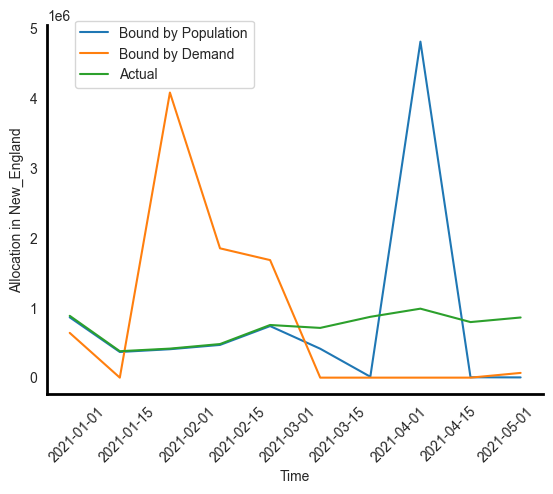

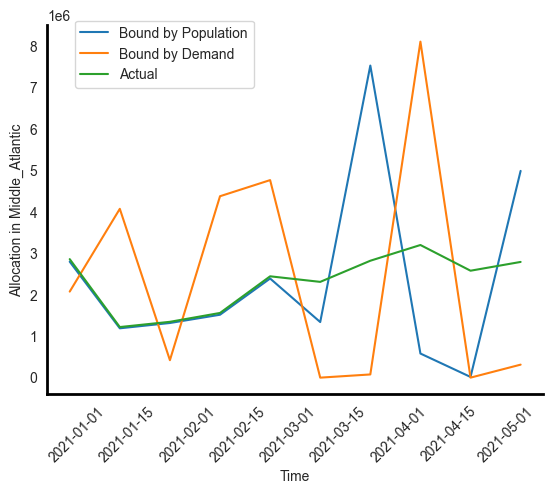

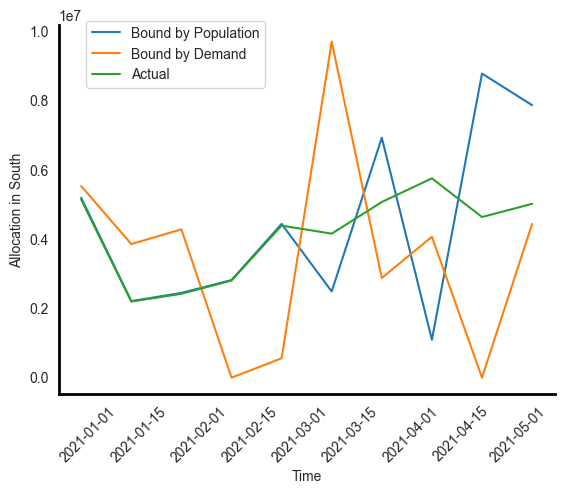

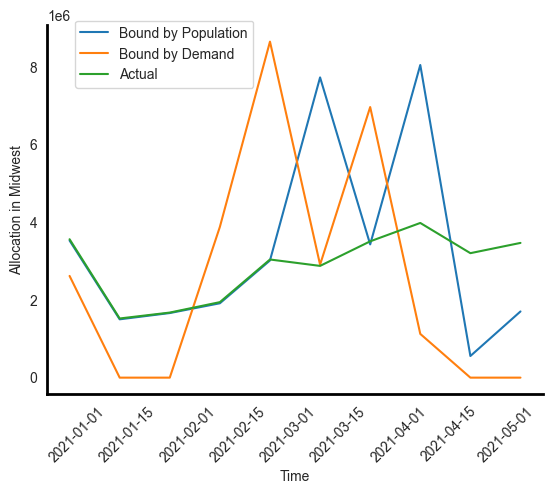

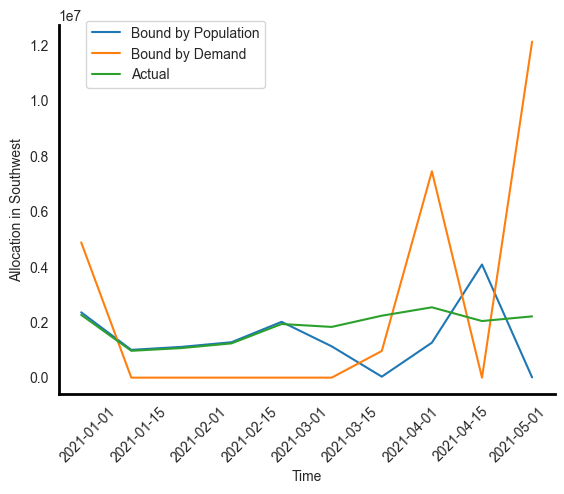

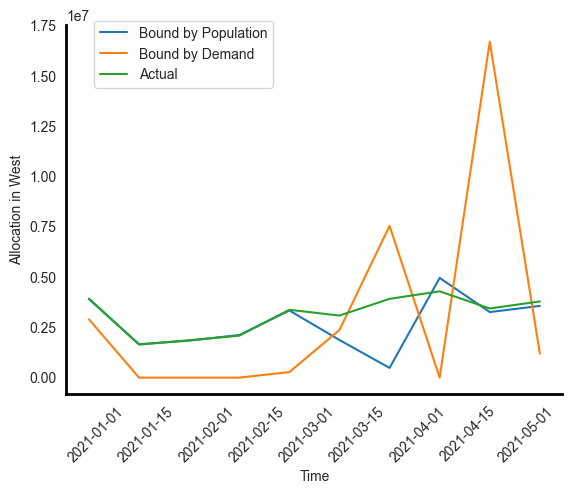

In [75]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Create example time series
# -----------------------------
# Time index
dates=[]
a= pd.to_datetime('2020-12-30')
for i in range(10):
    dates.append(a)
    a=a+pd.Timedelta(days=14)

# Two time series
# ts1 = pd.Series([sum(Pi_pfi[s][t]+Pi_mod[s][t]+Pi_jan[s][t]  for s in  regions['South']) for t in range(11)], index=dates)
def plot_act_mod_bound(mer):
    ts1 = pd.Series([sum(unbounded_sup[t,s]*Scale  for s in regions[mer]) for t in range(1,11)], index=dates)

    ts2 = pd.Series([sum(demand_limited_sup[t,s]*Scale  for s in regions[mer]) for t in range(1,11)], index=dates)

    ts3 = pd.Series([sum(actual_sup[t,s]*Scale  for s in regions[mer]) for t in range(1,11)], index=dates)

    fig, ax = plt.subplots()

    # -----------------------------
    # Plot
    # -----------------------------
    # plt.figure()
    ax.plot(ts1.index, ts1.values, label="Bound by Population")
    ax.plot(ts2.index, ts2.values, label="Bound by Demand")
    ax.plot(ts2.index, ts3.values, label="Actual")

    # Labels and legend
    ax.set_xlabel("Time")
    ax.set_ylabel(f"Allocation in {mer}")
    ax.legend(
        # loc="upper left",
        bbox_to_anchor=(0.43, 1.03)
    )
    # Rotate x-axis ticks by 45 degrees
    plt.xticks(rotation=45)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    for s in ["left", "bottom"]:
        ax.spines[s].set_visible(True)
        ax.spines[s].set_linewidth(2)
        ax.spines[s].set_color("black")

    # Prevent label cutoff
    ax.tick_params(axis="x", rotation=45)
    plt.savefig(remote_path+f'alloc{mer}.png')

    # Display plot
    plt.show()


for region in regions.keys():
    plot_act_mod_bound(region)


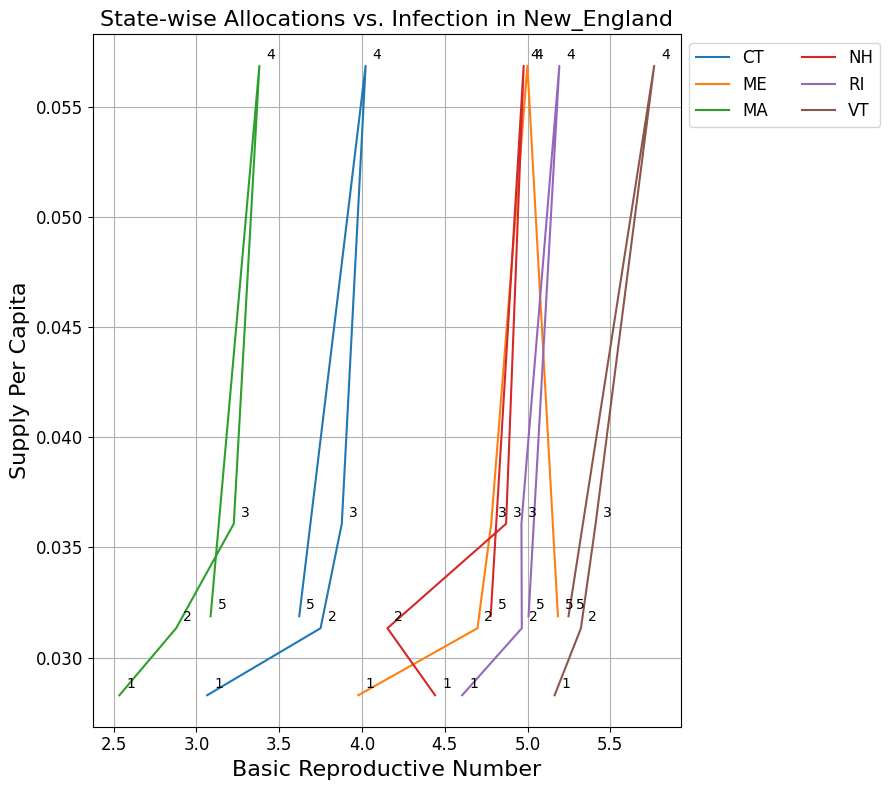

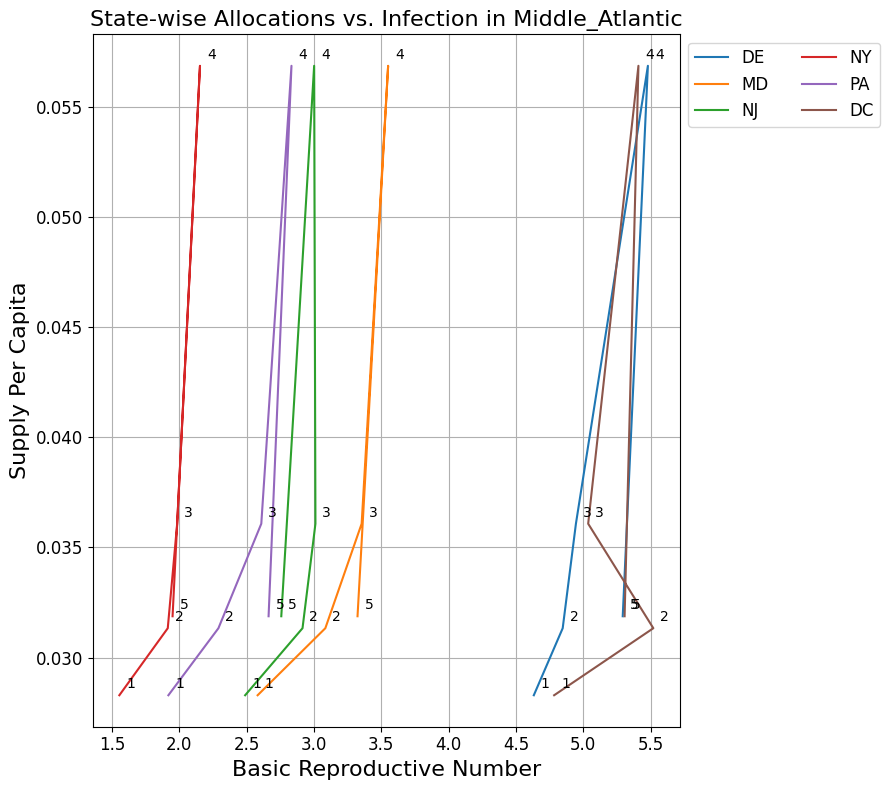

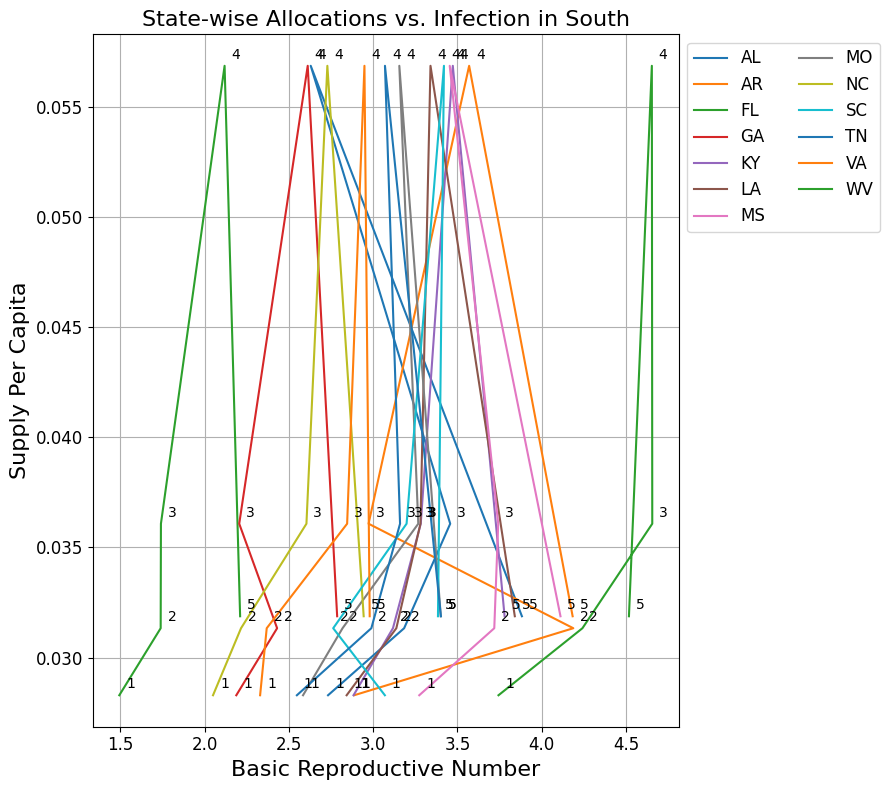

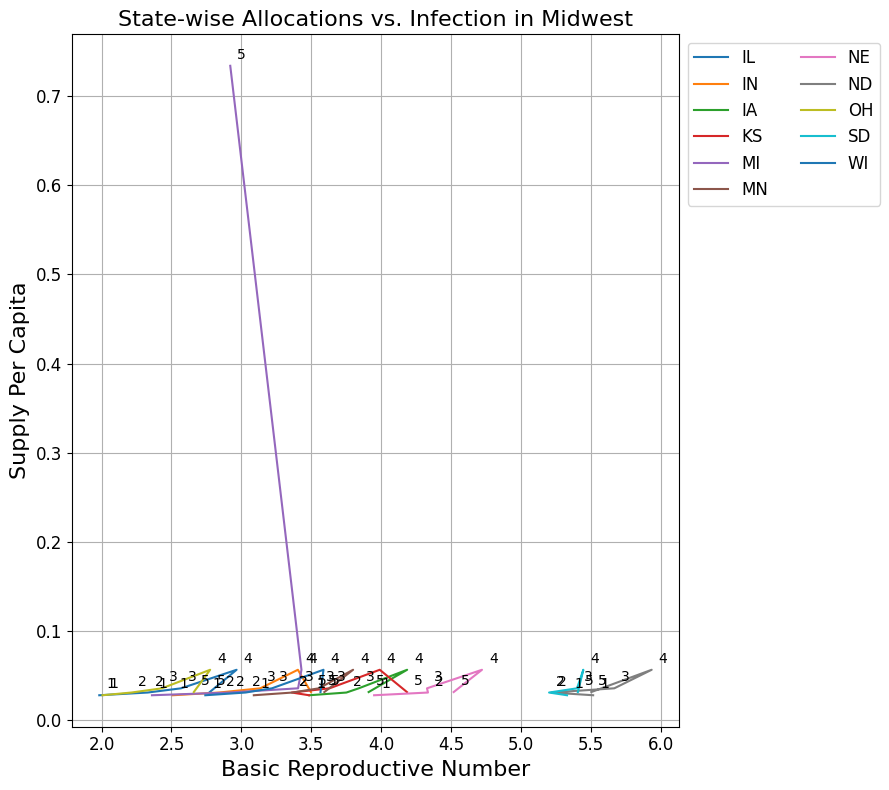

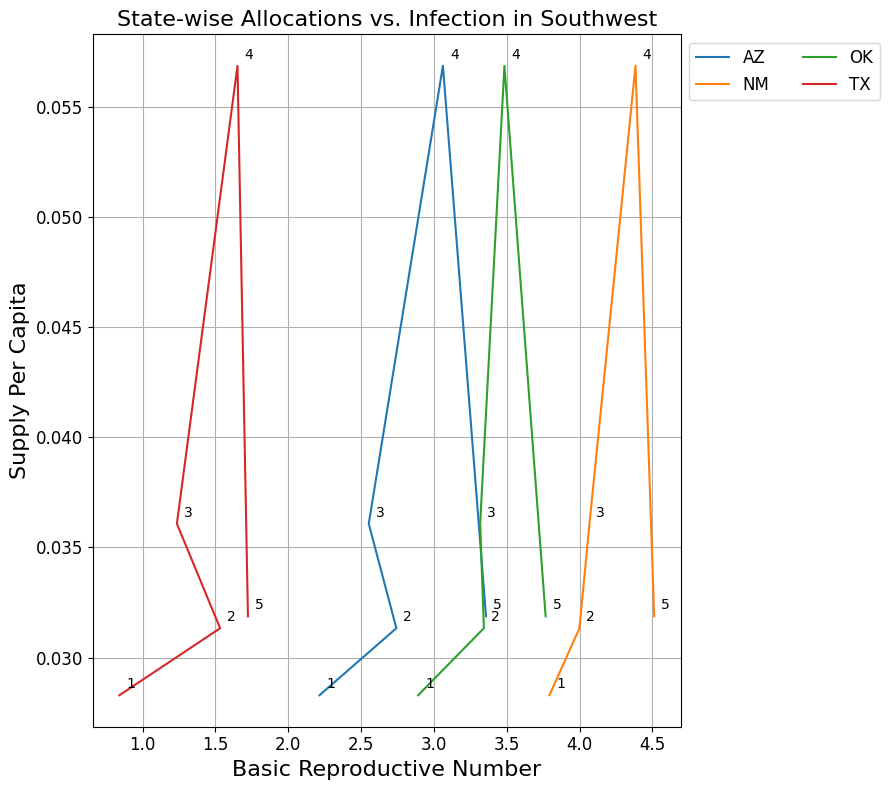

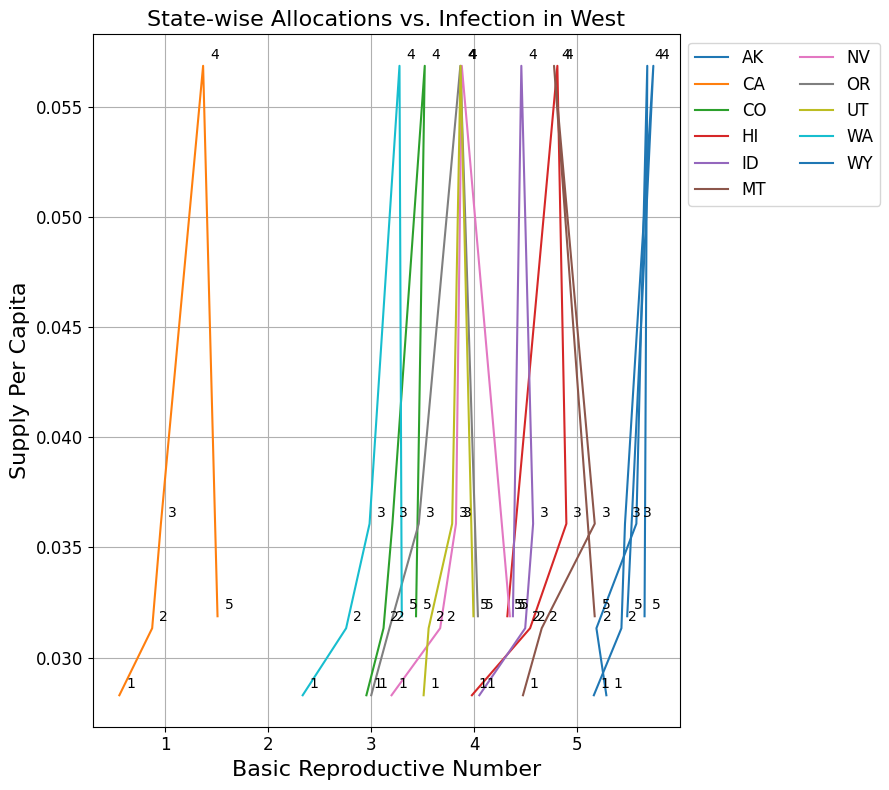

In [78]:

# Simulated data for demonstration
# Plot 1: Total Actual vs. Optimized Results
# fig, ax = plt.subplots(figsize=(8, 8))

actual_values={}
optimized_values={}
    # for reg in regions.keys():
def plot_inf_mod_bound(mer):
    for reg in regions[mer]:
        optimized_values[reg]= []
        actual_values[reg]=[]
        for t in range(2,7):
            # optimized_values[s].append(supply[t,1,s]+supply[t,2,s]+supply[t,3,s])
            # actual_values[s].append(Scale*beta[t+2,s]*I01[t+2,s])
            # optimized_values[reg].append(sum(demand_limited_sup[t-1,s]  for s in regions[reg])/sum(popplus12_s[s]*Scale for s in  regions[reg]))
            # actual_values[reg].append(np.log(sum(beta[t,s]*Scale*(S01[t,s] +effec**V01[t,s])  for s in regions[reg])))
            optimized_values[reg].append(unbounded_sup[t,reg]/popplus12_s[reg] *Scale)
            actual_values[reg].append(np.log(beta[t+2,reg]*Scale*Scale))
            # actual_values[s].append((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] ))
        # actual_values[s].sort()
        # optimized_values[s].sort()
    labels=range(1,11)
    # for t in range(11):
    #     actual_time.append(sum(actual_values[s][t] for s in states))
    #     optimized_time.append(sum(optimized_values[s][t] for s in states))
    #
    # ax.plot(actual_time, optimized_time, linewidth=2.0, label="Total Results")
    # ax.set_facecolor("white")
    # ax.set(xlim=(1000000, 5000000),
    #        ylim=(1000000, 5000000))
    # ax.set_title('Comparison of Total Actual vs. Optimized Results', fontsize=20)
    # ax.set_xlabel('Actual Results (million cases)', fontsize=20)
    # ax.set_ylabel('Optimized Results (million cases)', fontsize=20)
    #
    # # Customize spines
    # for spine in ax.spines.values():
    #     spine.set_color('black')
    # plt.tick_params(labelsize=14)
    # # Legend outside
    # # ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)
    # # plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout for legend space
    # plt.grid(True)
    # plt.show()

    # Plot 2: Individual State Comparison
    fig, ax = plt.subplots(figsize=(9, 8))

    # for s in regions.keys():
    for s in regions[mer]:

        ax.plot(actual_values[s], optimized_values[s], linewidth=1.5, label=s)
        for xi, yi, label in zip(actual_values[s], optimized_values[s], labels):
            ax.annotate(
                label,
                (xi, yi),
                textcoords="offset points",
                xytext=(5, 5),
                ha="left"
            )
    ax.set_facecolor("white")
    # ax.set(xlim=(0, 500000), xlabel="Actual Results (million cases)",
    #        ylim=(0, 500000), ylabel="Optimized Results (million cases)")
    ax.set_title(f'State-wise Allocations vs. Infection in {mer}', fontsize=16)
    ax.set_xlabel('Basic Reproductive Number', fontsize=16)
    ax.set_ylabel('Supply Per Capita', fontsize=16)

    # Customize spines
    for spine in ax.spines.values():
        spine.set_color('black')
    plt.tick_params(labelsize=12)
    # Legend outside
    # ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=8)
    plt.legend(fontsize=12,ncol=2,loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout for legend space
    plt.grid(True)
    plt.savefig(remote_path+f'actvsopt{mer}.png')

    plt.show()

for region in regions.keys():
    plot_inf_mod_bound(region)



### Knapsack-based Decomposition-Result Retrieval

In [60]:
for s in states:
    print(s,state_vaccine[s][10]/Scale,sum(Vac_state[t,s] for t in range(0,T-1)), sum(Vac_coun[t,s,c] for t in range(0,T-1) for c in counties[s])+sum(X_of[t,s] for t in range(0,T-1)))

AL 141.5768 106.01941055124607 106.01941055124077
AK 30.6152 58.049540872742405 58.0495408727371
AZ 290.0777 563.8572245928578 563.8572245928525
AR 108.3426 237.30742845280616 237.30742845280085
CA 1954.3905 851.9845002810548 851.9845002810495
CO 190.9317 124.99003342766116 124.99003342765585
CT 200.4477 78.64823182800667 78.64823182800137
DE 46.2877 76.83981173437562 76.83981173437031
DC 34.3816 15.440083854827968 15.440083854822664
FL 921.1086 1158.052956909483 1158.0529569094779
GA 376.4744 227.59506072758697 227.59506072758165
HI 5.9764 30.667481242408886 30.667481242403582
ID 62.0337 37.86652705025699 37.86652705025169
IL 606.0966 1029.2179411946743 1029.2179411946688
IN 243.639 197.96920184458224 197.96920184457693
IA 141.8628 67.76830367984167 67.76830367983635
KS 124.653 231.03901663420555 231.03901663420027
KY 174.8947 342.2565374498578 342.25653744985243
LA 150.8113 369.0039855204823 369.0039855204771
ME 75.3094 111.87421459298825 111.87421459298294
MD 298.5234 130.7336760708

In [ ]:
print(sum(state_vaccine[s][10] for s in states)/Scale,sum(Vac_state[t,s] for s in states for t in range(0,T-1)), sum(Vac_coun[t,s,c] for s in states for t in range(0,T-1) for c in counties[s])+sum(X_of[t,s] for s in states for t in range(0,T-1)),sum(X_of[t,s] for s in states for t in range(0,T-1)))

0.8190076351165771

In [ ]:
T=12
print(sum(10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s] for s in states for t in range(0, T))*Scale,1.5*sum(state_cases00[s][T+23]-state_cases00[s][23] for s in states))

In [ ]:
1.5*sum(state_cases00[s][T+23]-state_cases00[s][22] for s in states)

## Benders Decomposition

In [43]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
for i in [1,2,3]:
    Pi[-1,i]=0
wastage=0
for s in states:
    est_demand[-1,s]=0
    est_demand[0,s]=0
time=range(12)
T=12
T1=0
T2=12

cost , G1 , G2 , G3 , Gini_Coef , I , inf , inventory , lb , lb0 , opening , R , reinf , Vac_state , S , sol_time , sol_time0 , tau , U_D , U_I , upper , upper0 , V , Vac , Vac_1 , Vac_2 , Vac_avl , W1 , W2 , W3 , X_o , X_of , U_I1 , U_D1 = ( { } for _ in range(34))

S1, I1, V1, X_of = {}, {}, {}, {}
for s in states:
    Vac_avl[1,s]=0
dic , dic1 = ({ } for _ in range(2))
for t in time:
    for s in states:
        dic[t,s]=None
        for c in counties[s]:
            dic1[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
results2=pd.DataFrame.from_dict(dic1, orient='index')
Scale=10000
capacity=10000/Scale

def master_problem():
    mp = gp.Model()

    for t in range(T1-1,T2-1):
        lb[t]= mp.addVar( lb=0, vtype=GRB.CONTINUOUS)
    for s in states:
        for t in range(T1,T2+1):
            S[t,s] = mp.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            V[t,s] = mp.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
            I[t,s] = mp.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            R[t,s] = mp.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            reinf[t,s]= mp.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            tau[t,s]= mp.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
        for t in range(T1-1,T2-1):
            Vac[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
            U_I[t,s] = mp.addVar(vtype=GRB.BINARY)
            U_D[t,s] = mp.addVar(vtype=GRB.BINARY)
    for t in range(T1,T2):
         mp.addConstr(sum(Vac[ti,s] for s in states for ti in range(T1-1,t)) <= sum(Pi[ti,i] for i in suppliers for ti in range(T1-1,t)))

    for s in states:
        mp.addConstr(S[T1, s] ==S0101[0,s]/Scale)
        mp.addConstr(V[T1, s] == 0)
        mp.addConstr(I[T1, s] == I0101[0,s]/Scale)
        # mp.addConstr(R[T1, s] == R01[T1,s])
        mp.addConstr(sum(Vac[t,s] for t in range(T-1))<=state_vaccine[s][10]/Scale)
        for t in range(T1,T2):
            mp.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
            mp.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
            mp.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
            if t>=(reinf_period)+1:
                mp.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S[t-reinf_period,s] *I[t-reinf_period,s]))
            else:
                mp.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale)
            if t>=4:
                mp.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S[ti,s] *I[ti,s]+effec*Scale*beta[ti,s]*V[ti,s]*I[ti,s] for ti in range(t-3,t))/3)
            else:
                mp.addConstr(tau[t,s]==0.5*beta[0,s]*I[T1,s]*S[T1,s])
    for t in range(T1,T2-1):
        for s in states:
            # mp.addConstr(Vac[t,s]<=1*est_demand[t,s])
            mp.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_of[t,s])
    for s in states:
        mp.addConstr(sum(Vac[t-1,s]for t in range(T1,T2))*10000<=state_vaccine[s][10])
        for t in range(T1,T2):
            mp.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*10000>=lb[t-1])
    for s in states:
        for t in range(T1,T2-1):
            mp.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
            mp.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
            mp.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
            mp.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1))+ M*(U_D[t-1,s]) >=est_demand[t,s] )
            # mp.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
            # mp.addConstr(X_o[t,s]>= (U_I[t,s]+U_D[t,s])/2-(C)/B[3])
    mp.setObjective(
        (1*gp.quicksum(10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s] for s in states for t in range(1, 12))
        -seq_lb *gp.quicksum(lb[t] for t in range(1, T-1)))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states)),
        GRB.MINIMIZE)
    mp.update()
    return mp
# ----------------------------
# Utilities
# ----------------------------
def must_have_solution(m: gp.Model, name: str):
    if m.SolCount == 0:
        raise RuntimeError(f"{name} has no solution. Status={m.Status}")

def status_name(code: int) -> str:
    mapping = {
        GRB.OPTIMAL: "OPTIMAL",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.UNBOUNDED: "UNBOUNDED",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
        GRB.SUBOPTIMAL: "SUBOPTIMAL",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.INTERRUPTED: "INTERRUPTED",
    }
    return mapping.get(code, str(code))

def extract_binary_pattern(var_dict, t_range, states_list):
    """Return {(t,s): 0/1} for a dict of gurobi vars indexed by (t,s)."""
    return {(t, s): int(round(var_dict[t, s].X)) for t in t_range for s in states_list}

def add_no_good_cut(master: gp.Model, U_I_vars, U_D_vars, U_I_hat, U_D_hat, t_range, states_list, cut_name):
    """
    No-good cut forbidding the exact same binary assignment of (U_I, U_D).
    sum_{j: x_hat=1} (1-x_j) + sum_{j: x_hat=0} x_j >= 1
    """
    expr = gp.LinExpr()
    for t in t_range:
        for s in states_list:
            # U_I part
            if U_I_hat[t, s] == 1:
                expr += (1 - U_I_vars[t, s])
            else:
                expr += U_I_vars[t, s]
            # U_D part
            if U_D_hat[t, s] == 1:
                expr += (1 - U_D_vars[t, s])
            else:
                expr += U_D_vars[t, s]

    master.addConstr(expr >= 1, name=cut_name)
    master.update()

# ----------------------------
# Your ORIGINAL subproblem, kept MIP (X_o is BINARY)
# Wrapped so it returns status + (optional) objective + (optional) values
# ----------------------------
def solve_subproblem_MIP(U_I_fix, U_D_fix):
    """
    Builds and solves your subproblem with X_o binary (MIP).
    Returns:
      status, obj_value (or None), X_of (or None)
    """
    sp = gp.Model("sub_problem_MIP")
    sp.Params.OutputFlag = 0
    sp.Params.ScaleFlag = 2

    T1_local, T2_local = 0, 12
    time_sp = range(T1_local-1, T2_local-1)  # 0..10

    # --- Variables (match your structure) ---
    lb0 = {(t,s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"lb0[{t},{s}]")
           for t in time_sp for s in states}

    G1 = {(t,i,s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G1[{t},{i},{s}]")
          for t in time_sp for i in suppliers for s in states}

    # Keep binary (this is why we do logic-based)
    X_o = {(t,s): sp.addVar(lb=0, vtype=GRB.BINARY, name=f"X_o[{t},{s}]")
           for t in time_sp for s in states}

    W1 = {(t,s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W1[{t},{s}]")
          for t in range(T1_local-2, T2_local-1) for s in states}

    W2 = {(t,s,c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W2[{t},{s},{c}]")
          for t in range(T1_local-2, T2_local-1) for s in states for c in counties[s]}

    G2 = {(t,s,c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G2[{t},{s},{c}]")
          for t in time_sp for s in states for c in counties[s]}

    G3 = {(t,s,c,l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G3[{t},{s},{c},{l}]")
          for t in time_sp for s in states for c in counties[s]
          for l in range(int(np.ceil(local_centers[s,c])))}

    W3 = {(t,s,c,l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W3[{t},{s},{c},{l}]")
          for t in range(T1_local-2, T2_local-1) for s in states for c in counties[s]
          for l in range(int(np.ceil(local_centers[s,c])))}

    Vac0 = {(t,s,c): sp.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS, name=f"Vac0[{t},{s},{c}]")
            for t in time_sp for s in states for c in counties[s]}

    C = sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name="C")

    # --- Constraints (as in your subproblem) ---
    for t in time_sp:
        for s in states:
            sp.addConstr(X_o[t,s] <= U_I_fix[t,s] + U_D_fix[t,s], name=f"m13[{s},{t}]")
            for c in counties[s]:
                sp.addConstr(Vac0[t,s,c] <= county_cap[s,c], name=f"cap[{t},{s},{c}]")

    for t in time_sp:
        for i in suppliers:
            sp.addConstr(gp.quicksum(G1[t,i,s] for s in states) <= Pi[t,i], name=f"supply[{t},{i}]")

    for s in states:
        sp.addConstr(W1[-1,s] == 0, name=f"W1init[{s}]")
        sp.addConstr(W1[0,s]  == 0, name=f"W1zero[{s}]")
        for t in time_sp:
            sp.addConstr(
                gp.quicksum(G1[t,i,s] for i in suppliers) + W1[t-1,s]
                == gp.quicksum(G2[t,s,c] for c in counties[s]) + X_o[t,s]*capacity + W1[t,s],
                name=f"statebal[{t},{s}]"
            )

    for t in time_sp:
        for s in states:
            for c in counties[s]:
                sp.addConstr(W2[-1,s,c] == 0, name=f"W2init[{s},{c}]")
                sp.addConstr(W2[0,s,c]  == 0, name=f"W2zero[{s},{c}]")
                sp.addConstr(
                    G2[t,s,c] + W2[t-1,s,c]
                    == gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))) + W2[t,s,c],
                    name=f"countybal[{t},{s},{c}]"
                )

    for t in time_sp:
        for s in states:
            for c in counties[s]:
                L = int(np.ceil(local_centers[s,c]))
                for l in range(L):
                    sp.addConstr(W3[-1,s,c,l] == 0, name=f"W3init[{s},{c},{l}]")
                    sp.addConstr(W3[0,s,c,l]  == 0, name=f"W3zero[{s},{c},{l}]")
                sp.addConstr(
                    (1-wastage) * gp.quicksum(G3[t,s,c,l] + W3[t-1,s,c,l] for l in range(L))
                    == Vac0[t,s,c] + gp.quicksum(W3[t,s,c,l] for l in range(L)),
                    name=f"localbal[{t},{s},{c}]"
                )

    for t in time_sp:
        for s in states:
            for c in counties[s]:
                sp.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s], name=f"lb0def[{t},{s},{c}]")

    cost_expr = gp.quicksum(
        gp.quicksum(cost_param["w"][0]*W1[t,s] for s in states)
        + gp.quicksum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
        + gp.quicksum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s]
                      for l in range(int(np.ceil(local_centers[s,c]))))
        + gp.quicksum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s])
        + gp.quicksum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s]+cost_param["c"][3]*G1[t,3,s]
                      for s in states)
        + gp.quicksum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s]
                      for l in range(int(np.ceil(local_centers[s,c]))))
        + gp.quicksum(cost_param["c"][0]*X_o[t,s] for s in states)
        + gp.quicksum(10*(gp.quicksum(Vac0[t,s,c] for c in counties[s]) + (1-wastage)*X_o[t,s]) for s in states)
        for t in time_sp
    )
    sp.addConstr(cost_expr == C, name="defC")
    sp.addConstr(C <= B[3], name="budget")

    denom = sum(popplus12_s[s]/Scale for s in states)
    sp.setObjective(
        -1.4 * gp.quicksum(
            gp.quicksum(access[s]*gp.quicksum(weights[s,c]*Vac0[t,s,c] for c in counties[s])
                        + 10*lb0[t,s] + access[s]*X_o[t,s]
                        for s in states)
            for t in range(0, 11)
        ) / denom,
        GRB.MINIMIZE
    )
    sp.optimize()
    st = sp.Status
    if st == GRB.OPTIMAL and sp.SolCount > 0:
        obj = sp.ObjVal
        X_of = {(t,s): int(round(X_o[t,s].X)) for t in time_sp for s in states}
        sp.dispose()
        return st, obj, X_of
    solution_time+=sp.Runtime
    # infeasible/other
    sp.dispose()
    return st, None, None

# X_of={}
# for s in states:
#     for t in range(T1-1, T2-1):
#         X_of[t,s]=0
# ----------------------------
# Logic-Based Benders main loop
# ----------------------------

def run_logic_benders(max_iters=50):
    global solution_time, X_of
    # Build your master exactly as you wrote it
    t_range = range(T1-1, T2-1)  # 0..10
    for s in states:
        for t in range(T1-1, T2-1):
            X_of[t,s]=0
    solution_time=0
    master = master_problem()
    master.Params.OutputFlag = 0
    master.Params.ScaleFlag = 2
    master.Params.DualReductions = 0
    master.Params.InfUnbdInfo = 1

    # We need the time index used by your U_I/U_D in master:
    # In your master: U_I[t,s], U_D[t,s] were created for t in range(0, T2-1) i.e. 0..10 when T2=12

    for it in range(1, max_iters + 1):
        master.optimize()
        solution_time+=master.Runtime
        for t in range(T1-1,T2-1):
            for s in states:
                Vac_state[t, s] = round(Vac[t, s].x,4)
                S1[t+1, s]= S[t+1, s].x
                V1[t+1, s]= V[t+1, s].x
                I1[t+1, s]= I[t+1, s].x
        if master.SolCount == 0:
            raise RuntimeError(f"MASTER has no solution. Status={status_name(master.Status)}")

        if master.Status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL, GRB.TIME_LIMIT]:
            raise RuntimeError(f"MASTER unexpected status: {status_name(master.Status)}")

        # Extract current master binary decisions
        U_I_hat = extract_binary_pattern(U_I, t_range, states)
        U_D_hat = extract_binary_pattern(U_D, t_range, states)

        # Solve subproblem MIP with fixed master decisions
        st, sub_obj, X_of = solve_subproblem_MIP(U_I_hat, U_D_hat)
        if st == GRB.OPTIMAL:
            print(f"Iter {it:02d}: SUB OPTIMAL. sub_obj={sub_obj:.6g} master_obj={master.ObjVal:.6g}")
            return {
                "master_obj": master.ObjVal,
                "Vac_state": Vac_state,
                "sub_obj": sub_obj,
                "U_I": U_I_hat,
                "U_D": U_D_hat,
                "X_of": X_of
            }

        if st == GRB.INFEASIBLE:
            print(f"Iter {it:02d}: SUB INFEASIBLE. Adding no-good cut.")
            add_no_good_cut(
                master,
                U_I, U_D,
                U_I_hat, U_D_hat,
                t_range, states,
                cut_name=f"nogood[{it}]"
            )
            continue

        # Other statuses: treat as failure for now
        raise RuntimeError(f"SUB unexpected status: {status_name(st)}")

    raise RuntimeError("Reached max_iters without finding a feasible (master, sub) combination.")

# ----------------------------
# RUN
# ----------------------------
result = run_logic_benders(max_iters=30)
result

Iter 01: SUB OPTIMAL. sub_obj=-0.0104607 master_obj=1.04094


{'master_obj': 1.0409402281583164,
 'Vac_state': {(-1, 'NY'): 0.0,
  (-1, 'NJ'): 0.0,
  (0, 'NY'): 0.0,
  (0, 'NJ'): 0.0,
  (1, 'NY'): 4.9071,
  (1, 'NJ'): 161.2029,
  (2, 'NY'): 48.7296,
  (2, 'NJ'): 22.1329,
  (3, 'NY'): 53.7186,
  (3, 'NJ'): 24.3989,
  (4, 'NY'): 62.3058,
  (4, 'NJ'): 28.2992,
  (5, 'NY'): 141.2832,
  (5, 'NJ'): 0.7388,
  (6, 'NY'): 132.5644,
  (6, 'NJ'): 1.6606,
  (7, 'NY'): 112.6634,
  (7, 'NJ'): 51.1716,
  (8, 'NY'): 127.8794,
  (8, 'NJ'): 58.0826,
  (9, 'NY'): 102.9419,
  (9, 'NJ'): 46.7561,
  (10, 'NY'): 111.4071,
  (10, 'NJ'): 50.6009},
 'sub_obj': -0.010460665242242017,
 'U_I': {(-1, 'NY'): 1,
  (-1, 'NJ'): 1,
  (0, 'NY'): 1,
  (0, 'NJ'): 1,
  (1, 'NY'): 1,
  (1, 'NJ'): 1,
  (2, 'NY'): 1,
  (2, 'NJ'): 1,
  (3, 'NY'): 0,
  (3, 'NJ'): 0,
  (4, 'NY'): 0,
  (4, 'NJ'): 0,
  (5, 'NY'): 0,
  (5, 'NJ'): 0,
  (6, 'NY'): 1,
  (6, 'NJ'): 0,
  (7, 'NY'): 0,
  (7, 'NJ'): 0,
  (8, 'NY'): 0,
  (8, 'NJ'): 0,
  (9, 'NY'): 0,
  (9, 'NJ'): 0,
  (10, 'NY'): 0,
  (10, 'NJ'): 0},


In [46]:
print(sum(I1[t,s]*beta[t,s]*(S1[t,s]+effec*V1[t,s]) for s in states for t in range(12))*Scale*Scale/1000000,solution_time,sum(X_of[t,s] for s in states for t in range(11)),sum(Vac_state[t,s] for s in states for t in range(11)))

# sum(1.5*(state_cases00[s][11+1+23]-state_cases00[s][23+0])/Scale for s in states)

1.6826441984232776 71.97614288330078 3 1343.445


In [112]:
# ============================
# FINALIZED FEASIBILITY-LBBD SKELETON
# (X_of is SUBPROBLEM OUTPUT ONLY)
# ============================

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd

# ----------------------------
# Assumptions:
# - states, suppliers, counties, popplus12_s, popplus12, etc. are defined externally.
# - Pi is defined for t=0..T-2 and suppliers; we will handle t=0 start properly.
# ----------------------------

# ----------------------------
# Global config
# ----------------------------
Scale = 10000
capacity = 10000 / Scale
wastage = 0

T = 12
T1 = 0
T2 = 12
time = range(T)  # 0..11
time_vac = range(T2-1)  # 0..10  (Vac decisions live on 0..10)
time_dyn = range(T1, T2)  # 0..11  (dynamics constraints use t and t+1)

# ---- make sure Pi is defined at t=0..T-2; if you previously used Pi[-1,*], stop doing that.
# Instead, ensure your supply is defined for valid t. If you need "pre-period", use explicit initial stock.
# for i in [1,2,3]:
#     Pi[-1,i] = 0  # <-- REMOVE THIS in the finalized version.

# If est_demand uses negative indices, STOP. Define demand on valid t only.
# est_demand[-1,s]=0 etc. should be avoided. Use boundary conditions in constraints instead.

# ----------------------------
# Containers (dicts)
# ----------------------------
S, V, I, R = {}, {}, {}, {}
Vac, reinf, tau = {}, {}, {}
U_I, U_D = {}, {}
lb = {}
Vac_state = {}
S1, I1, V1 = {}, {}, {}

# ----------------------------
# Master problem (NO X_of anywhere)
# ----------------------------
def master_problem():
    mp = gp.Model("MASTER")
    mp.Params.OutputFlag = 0

    # lb[t] defined for t=0..10 (align with Vac periods)
    for t in time_vac:
        lb[t] = mp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"lb[{t}]")

    # State variables for t=0..12 (need t+1 up to 12)
    for s in states:
        for t in range(T1, T2+1):  # 0..12
            S[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale, vtype=GRB.CONTINUOUS, name=f"S[{t},{s}]")
            V[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale, vtype=GRB.CONTINUOUS, name=f"V[{t},{s}]")
            I[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale, vtype=GRB.CONTINUOUS, name=f"I[{t},{s}]")
            R[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale, vtype=GRB.CONTINUOUS, name=f"R[{t},{s}]")
            reinf[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale, vtype=GRB.CONTINUOUS, name=f"reinf[{t},{s}]")
            tau[t,s] = mp.addVar(lb=0, ub=popplus12_s[s], vtype=GRB.CONTINUOUS, name=f"tau[{t},{s}]")

        # Vaccination decisions and binaries for t=0..10 only
        for t in time_vac:
            Vac[t,s] = mp.addVar(lb=0, ub=popplus12_s[s]/Scale, vtype=GRB.CONTINUOUS, name=f"Vac[{t},{s}]")
            U_I[t,s] = mp.addVar(vtype=GRB.BINARY, name=f"U_I[{t},{s}]")
            U_D[t,s] = mp.addVar(vtype=GRB.BINARY, name=f"U_D[{t},{s}]")

    # ---- Supply feasibility (use cumulative supply; if Pi[t,i] is per-period)
    for t in time_vac:
        mp.addConstr(
            gp.quicksum(Vac[ti,s] for s in states for ti in range(0, t+1))
            <= gp.quicksum(Pi[ti,i] for i in suppliers for ti in range(0, t+1)),
            name=f"cum_supply[{t}]"
        )

    # ---- Initial conditions
    for s in states:
        mp.addConstr(S[T1,s] == S0101[0,s]/Scale, name=f"S_init[{s}]")
        mp.addConstr(V[T1,s] == 0, name=f"V_init[{s}]")
        mp.addConstr(I[T1,s] == I0101[0,s]/Scale, name=f"I_init[{s}]")

        # state vaccine total cap
        mp.addConstr(gp.quicksum(Vac[t,s] for t in time_vac) <= state_vaccine[s][10]/Scale,
                     name=f"state_vax_cap[{s}]")

    # ---- Disease dynamics with safe lag handling
    for s in states:
        for t in range(T1, T2):  # 0..11
            # lagged vaccination term: Vac[t-gamma1,s] if valid else 0
            if t - gamma1 in time_vac:
                vac_lag = Vac[t-gamma1, s]
            else:
                vac_lag = 0.0

            mp.addConstr(
                S[t+1,s] == (1-mu)*S[t,s] + mu
                           - 10000*beta[t,s]*I[t,s]*S[t,s]
                           - (1-coefs[s])*vac_lag
                           + reinf[t,s],
                name=f"S_dyn[{t},{s}]"
            )
            mp.addConstr(
                V[t+1,s] == (1-mu)*V[t,s]
                           + (1-coefs[s])*vac_lag
                           - effec*10000*beta[t,s]*V[t,s]*I[t,s],
                name=f"V_dyn[{t},{s}]"
            )
            mp.addConstr(
                I[t+1,s] == (1-mu)*I[t,s]
                           + 10000*beta[t,s]*S[t,s]*I[t,s]
                           + effec*10000*beta[t,s]*V[t,s]*I[t,s]
                           - gamma*I[t,s],
                name=f"I_dyn[{t},{s}]"
            )

            # reinf logic (kept as you wrote, but without negative indexing)
            if t >= (reinf_period)+1:
                mp.addConstr(
                    reinf[t,s] == (reinf_rate) * (Scale*beta[t-reinf_period,s]*S[t-reinf_period,s]*I[t-reinf_period,s]),
                    name=f"reinf_rule[{t},{s}]"
                )
            else:
                # NOTE: this uses state_cases00 indexing; ensure indices are valid
                mp.addConstr(
                    reinf[t,s] == reinf_rate*1.5*(state_cases00[s][24+t-reinf_period] - state_cases00[s][24+t-1-reinf_period])/Scale,
                    name=f"reinf_fallback[{t},{s}]"
                )

            # tau definition
            if t >= 4:
                mp.addConstr(
                    tau[t,s] == gp.quicksum(
                        Scale*beta[ti,s]*S[ti,s]*I[ti,s] + effec*Scale*beta[ti,s]*V[ti,s]*I[ti,s]
                        for ti in range(t-3, t)
                    ) / 3,
                    name=f"tau_avg[{t},{s}]"
                )
            else:
                mp.addConstr(
                    tau[t,s] == 0.5*beta[0,s]*I[T1,s]*S[T1,s],
                    name=f"tau_init[{t},{s}]"
                )

    # ---- Capacity proxy in master must be conservative if subproblem can "open" extra capacity.
    # Since X_of is not in master, the safest master-side constraint is WITHOUT that term:
    for s in states:
        cap_s = sum(county_cap[s,c] for c in counties[s])
        for t in time_vac:
            mp.addConstr(Vac[t,s] <= cap_s, name=f"cap_master[{t},{s}]")

    # ---- Fairness constraints
    for s in states:
        denom = sum(popplus12[s,c] for c in counties[s])
        for t in time_vac:
            mp.addConstr(Vac[t,s] / denom * 10000 >= lb[t], name=f"lb_link[{t},{s}]")

    # ---- Your big-M logical constraints (be careful about t-1; use t in time_vac)
    for s in states:
        cap_total = sum(county_cap[s,c] for c in counties[s])*(T2-T1)
        for t in time_vac:
            mp.addConstr(
                tau[t,s] - M*(1-U_I[t,s]) <= Scale*beta[t,s]*S[t,s]*I[t,s] + effec*Scale*beta[t,s]*V[t,s]*I[t,s],
                name=f"logic_UI_lo[{t},{s}]"
            )
            mp.addConstr(
                tau[t,s] + M*(U_I[t,s]) >= Scale*beta[t,s]*S[t,s]*I[t,s] + effec*Scale*beta[t,s]*V[t,s]*I[t,s],
                name=f"logic_UI_hi[{t},{s}]"
            )
            mp.addConstr(
                cap_total - M*(1-U_D[t,s]) <= est_demand[t,s],
                name=f"logic_UD_lo[{t},{s}]"
            )
            mp.addConstr(
                cap_total + M*(U_D[t,s]) >= est_demand[t,s],
                name=f"logic_UD_hi[{t},{s}]"
            )

    # ---- Objective (your original)
    mp.setObjective(
        ( gp.quicksum(10000*beta[t,s]*S[t,s]*I[t,s] + effec*10000*beta[t,s]*V[t,s]*I[t,s]
                      for s in states for t in range(1, 12))
          - seq_lb*gp.quicksum(lb[t] for t in range(1, T-1))
        ) / (1.5*sum(state_cases00[s][23]/Scale - 1.5*state_cases00[s][0]/Scale for s in states)),
        GRB.MINIMIZE
    )

    mp.update()
    return mp


# ----------------------------
# Utilities for LBBD
# ----------------------------
def status_name(code: int) -> str:
    mapping = {
        GRB.OPTIMAL: "OPTIMAL",
        GRB.INFEASIBLE: "INFEASIBLE",
        GRB.UNBOUNDED: "UNBOUNDED",
        GRB.INF_OR_UNBD: "INF_OR_UNBD",
        GRB.SUBOPTIMAL: "SUBOPTIMAL",
        GRB.TIME_LIMIT: "TIME_LIMIT",
        GRB.INTERRUPTED: "INTERRUPTED",
    }
    return mapping.get(code, str(code))

def extract_binary_pattern(var_dict, t_range, states_list):
    return {(t, s): int(round(var_dict[t, s].X)) for t in t_range for s in states_list}

def add_no_good_cut(master: gp.Model, U_I_vars, U_D_vars, U_I_hat, U_D_hat, t_range, states_list, cut_name):
    expr = gp.LinExpr()
    for t in t_range:
        for s in states_list:
            expr += (1 - U_I_vars[t,s]) if U_I_hat[t,s] == 1 else U_I_vars[t,s]
            expr += (1 - U_D_vars[t,s]) if U_D_hat[t,s] == 1 else U_D_vars[t,s]
    master.addConstr(expr >= 1, name=cut_name)
    master.update()


# ----------------------------
# Subproblem (MIP), returns X_of pattern as output only
# IMPORTANT: fixed duplicate init constraints + time indexing
# ----------------------------
def solve_subproblem_MIP(U_I_fix, U_D_fix):
    sp = gp.Model("SUB_MIP")
    sp.Params.OutputFlag = 0

    # Use t=0..10 only (no negative t)
    time_sp = range(0, T2-1)  # 0..10

    # Vars
    lb0 = {(t,s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"lb0[{t},{s}]")
           for t in time_sp for s in states}

    G1 = {(t,i,s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G1[{t},{i},{s}]")
          for t in time_sp for i in suppliers for s in states}

    X_o = {(t,s): sp.addVar(vtype=GRB.BINARY, name=f"X_o[{t},{s}]")
           for t in time_sp for s in states}

    # inventories include t=-1 to represent previous period, but initialize ONCE
    W1 = {(t,s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W1[{t},{s}]")
          for t in range(-1, T2-1) for s in states}  # -1..10

    W2 = {(t,s,c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W2[{t},{s},{c}]")
          for t in range(-1, T2-1) for s in states for c in counties[s]}

    G2 = {(t,s,c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G2[{t},{s},{c}]")
          for t in time_sp for s in states for c in counties[s]}

    G3 = {(t,s,c,l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G3[{t},{s},{c},{l}]")
          for t in time_sp for s in states for c in counties[s]
          for l in range(int(np.ceil(local_centers[s,c])))}

    W3 = {(t,s,c,l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W3[{t},{s},{c},{l}]")
          for t in range(-1, T2-1) for s in states for c in counties[s]
          for l in range(int(np.ceil(local_centers[s,c])))}

    Vac0 = {(t,s,c): sp.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS, name=f"Vac0[{t},{s},{c}]")
            for t in time_sp for s in states for c in counties[s]}

    C = sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name="C")

    # Init constraints ONCE (no duplicate names)
    for s in states:
        sp.addConstr(W1[-1,s] == 0, name=f"W1init[{s}]")
        for c in counties[s]:
            sp.addConstr(W2[-1,s,c] == 0, name=f"W2init[{s},{c}]")
            L = int(np.ceil(local_centers[s,c]))
            for l in range(L):
                sp.addConstr(W3[-1,s,c,l] == 0, name=f"W3init[{s},{c},{l}]")

    # Link X_o to fixed binaries
    for t in time_sp:
        for s in states:
            sp.addConstr(X_o[t,s] <= U_I_fix[t,s] + U_D_fix[t,s], name=f"open_link[{t},{s}]")
            for c in counties[s]:
                sp.addConstr(Vac0[t,s,c] <= county_cap[s,c], name=f"cap[{t},{s},{c}]")

    # Supply
    for t in time_sp:
        for i in suppliers:
            sp.addConstr(gp.quicksum(G1[t,i,s] for s in states) <= Pi[t,i], name=f"supply[{t},{i}]")

    # State balance
    for t in time_sp:
        for s in states:
            sp.addConstr(
                gp.quicksum(G1[t,i,s] for i in suppliers) + W1[t-1,s]
                == gp.quicksum(G2[t,s,c] for c in counties[s]) + X_o[t,s]*capacity + W1[t,s],
                name=f"statebal[{t},{s}]"
            )

    # County + local balances
    for t in time_sp:
        for s in states:
            for c in counties[s]:
                L = int(np.ceil(local_centers[s,c]))
                sp.addConstr(
                    G2[t,s,c] + W2[t-1,s,c]
                    == gp.quicksum(G3[t,s,c,l] for l in range(L)) + W2[t,s,c],
                    name=f"countybal[{t},{s},{c}]"
                )
                sp.addConstr(
                    (1-wastage)*gp.quicksum(G3[t,s,c,l] + W3[t-1,s,c,l] for l in range(L))
                    == Vac0[t,s,c] + gp.quicksum(W3[t,s,c,l] for l in range(L)),
                    name=f"localbal[{t},{s},{c}]"
                )

    # lb0 definition
    for t in time_sp:
        for s in states:
            for c in counties[s]:
                sp.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s], name=f"lb0def[{t},{s},{c}]")

    # Cost + budget
    cost_expr = gp.quicksum(
        gp.quicksum(cost_param["w"][0]*W1[t,s] for s in states)
        + gp.quicksum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
        + gp.quicksum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s]
                      for l in range(int(np.ceil(local_centers[s,c]))))
        + gp.quicksum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s])
        + gp.quicksum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s]+cost_param["c"][3]*G1[t,3,s]
                      for s in states)
        + gp.quicksum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s]
                      for l in range(int(np.ceil(local_centers[s,c]))))
        + gp.quicksum(cost_param["c"][0]*X_o[t,s] for s in states)
        + gp.quicksum(10*(gp.quicksum(Vac0[t,s,c] for c in counties[s]) + (1-wastage)*X_o[t,s]) for s in states)
        for t in time_sp
    )
    sp.addConstr(cost_expr == C, name="defC")
    sp.addConstr(C <= B[3], name="budget")

    # Objective (your original)
    denom = sum(popplus12_s[s]/Scale for s in states)
    sp.setObjective(
        -1.4 * gp.quicksum(
            gp.quicksum(access[s]*gp.quicksum(weights[s,c]*Vac0[t,s,c] for c in counties[s])
                        + 10*lb0[t,s] + access[s]*X_o[t,s]
                        for s in states)
            for t in range(0, 11)
        ) / denom,
        GRB.MINIMIZE
    )

    sp.optimize()
    st = sp.Status

    if st == GRB.OPTIMAL and sp.SolCount > 0:
        X_of_out = {(t,s): int(round(X_o[t,s].X)) for t in time_sp for s in states}
        return st, sp.ObjVal, X_of_out

    return st, None, None


# ----------------------------
# LBBD main loop (feasibility cuts only)
# ----------------------------
def run_logic_benders(max_iters=50):
    master = master_problem()
    t_range = range(0, T2-1)  # 0..10

    master.Params.OutputFlag = 0
    master.Params.DualReductions = 0
    master.Params.InfUnbdInfo = 1

    for it in range(1, max_iters+1):
        master.optimize()

        if master.SolCount == 0:
            raise RuntimeError(f"MASTER has no solution. Status={status_name(master.Status)}")

        # record master solution (optional)
        for t in t_range:
            for s in states:
                Vac_state[t,s] = float(Vac[t,s].X)
                S1[t+1,s] = float(S[t+1,s].X)
                V1[t+1,s] = float(V[t+1,s].X)
                I1[t+1,s] = float(I[t+1,s].X)

        U_I_hat = extract_binary_pattern(U_I, t_range, states)
        U_D_hat = extract_binary_pattern(U_D, t_range, states)

        st, sub_obj, X_of_out = solve_subproblem_MIP(U_I_hat, U_D_hat)

        if st == GRB.OPTIMAL:
            print(f"Iter {it:02d}: SUB OPTIMAL. sub_obj={sub_obj:.6g} master_obj={master.ObjVal:.6g}")
            return {
                "master_obj": master.ObjVal,
                "sub_obj": sub_obj,
                "U_I": U_I_hat,
                "U_D": U_D_hat,
                "X_of": X_of_out,
                "Vac_state": Vac_state
            }

        if st == GRB.INFEASIBLE:
            print(f"Iter {it:02d}: SUB INFEASIBLE -> add no-good cut")
            add_no_good_cut(master, U_I, U_D, U_I_hat, U_D_hat, t_range, states, cut_name=f"nogood[{it}]")
            continue

        raise RuntimeError(f"SUB unexpected status: {status_name(st)}")

    raise RuntimeError("Reached max_iters without finding feasible (master, sub) combination.")


# ----------------------------
# RUN
# ----------------------------
result = run_logic_benders(max_iters=30)
result



Interrupt request received


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


KeyboardInterrupt: 

In [65]:
def sub_problem(U_I1,U_D1):
    sp = gp.Model()
    for s in states:
        for t in range(T1-1,T2-1):
            lb0[t,s]=sp.addVar(lb=0,vtype=GRB.CONTINUOUS)
            for i in [1,2,3]:
                G1[t,i,s] = sp.addVar( lb=0, vtype=GRB.CONTINUOUS)
    X_o = {(t, s): sp.addVar(lb=0, vtype=GRB.BINARY)  for t in  range(T1-1,T2) for s in states}
    W1 = {(t, s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS)  for t in  range(T1-2,T2-1) for s in states}
    W2 = {(t, s, c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s]}
    G2 = {(t, s, c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    G3 = {(t, s, c,l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    W3 = {(t, s, c,l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    Vac0 = {(t, s,c): sp.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    sup_avl={(t,i): sp.addVar(lb=0, ub=Pi[t,i], vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for i in suppliers}
    C=sp.addVar(lb=0)
    cost={}
    for s in states:
        cost[s] = sp.addVar(lb=0, vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2-1):
        for s in states:
            sp.addConstr(X_o[t,s]<= U_I1[t,s]+U_D1[t,s],name=f'm13{s,t}')
            for c in counties[s]:
                sp.addConstr(Vac0[t,s,c]<=county_cap[s,c])

    # for t in range(T1-1,T2-1):
    #     for s in states:
    #         sp.addConstr(Vac[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s])
    for t in range(T1-1,T2-1):
        for i in suppliers:
            sp.addConstr(gp.quicksum(G1[t,i,s] for s in states)<=Pi[t,i])
    for s in states:
        for t in range(T1-1,T2-1):
            sp.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s])
            # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
        sp.addConstr(W1[-1,s]==0)
        sp.addConstr(W1[0,s]==0)

    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                sp.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
                sp.addConstr(W2[-1,s,c]==0)
                sp.addConstr(W2[0,s,c]==0)
    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                sp.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
                for l in range(int(np.ceil(local_centers[s,c]))):
                    sp.addConstr(W3[-1,s,c,l]==0)
                    sp.addConstr(W3[0,s,c,l]==0)

    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                sp.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])
    # if T1>=3:
    #     for t in range(T1-1,T2-1):
    #         for s in states:
    sp.addConstr(sum(
         sum(cost_param["w"][0]*W1[t,s] for s in states )
        +sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
         +sum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
         +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )
         +sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s] +cost_param["c"][3]*G1[t,3,s] for s in states )
         +sum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
         +sum(cost_param["c"][0]*X_o[t,s] for s in states)+sum(10*(gp.quicksum(Vac0[t,s,c] for c in counties[s])+(1-wastage)*X_o[t,s]) for s in states) for t in range(T1-1,T2-1))==C)
    sp.addConstr(C<=B[3])

    # sp.setObjective(-sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c]+lb0[t,s])for c in counties[s])+ 10*X_o[t,s] for s in states)/sum(2*Pi[t,i] for i in [1,2,3]) for t in range(1,11))+1*gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s])/(3*state_cases00[s][t+12]-3*state_cases00[s][t+11])*Scale for s in states for t in range(0, 12)) -1000*sum(1*lb[t-1]/sum(3*state_cases00[s][t+12]-3*state_cases00[s][t+11] for s in states)*Scale for t in range(T1, T2)), GRB.MINIMIZE)

    sp.setObjective(-1.4*sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c])for c in counties[s])
                                     +10*lb0[t,s]+ access[s]*X_o[t,s] for s in states)for t in range(0, 11))/(sum(popplus12_s[s]/Scale for s in states))
                        , GRB.MINIMIZE)
    # sum(popplus12_s[s]/Scale for s in states)
    # model0.setObjective(sum(I[T2,s] for s in states) , GRB.MINIMIZE)
    # Set optimization parameters
    sp.Params.ScaleFlag=2
    sp.optimize()
    sp.getObjective()
    if sp.status == GRB.INFEASIBLE:
        sp.computeIIS()
        sp.write("model.ilp")
        for c in sp.getConstrs():
            if c.IISConstr:
                print(f"Infeasible constraint: {c.constrName}")

        for v in sp.getVars():
            if v.IISLB:
                print(f"Infeasible lower bound: {v.varName}")
            if v.IISUB:
                print(f"Infeasible upper bound: {v.varName}")

    elif sp.Status == GRB.OPTIMAL:
        Vac_coun={(t,s): sum(Vac0[t,s,c].x for c in counties[s]) for t in range(T1-1,T2-1) for s in states }
        X_of={(t,s): X_o[t,s].x for t in range(T1-1,T2-1) for s in states}
        cost[T1]= sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x+cost_param["c"][3]*G1[t,3,s].x for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s].x for s in states)+sum(10*(gp.quicksum(Vac0[t,s,c] for c in counties[s])+(1-wastage)*X_o[t,s]) for s in states)for t in  range(T1-1,T2-1))
    sp.getAttr(GRB.Attr.Pi, sp.getConstrs())
    sp.dispose()

In [48]:
def benders_cut():
    T1=0
    T2=12
    master=master_problem()
    master.Params.ScaleFlag=2
    master.optimize()
    a=master.getObjective()
    for t in range(T1-1,T2-1):
        for s in states:
            Vac_state[t,s]=Vac[t,s].x
            U_I1[t,s]=U_I[t,s].x
            U_D1[t,s]=U_D[t,s].x
            inf=sum(10000*beta[t,s] * S[t, s].x * I[t, s].x + effec*10000*beta[t,s] *  V[t, s].x * I[t, s].x for s in states for t in range(1, 12))
    return inf

In [49]:
T1=0
T2=12
for t in range(T1-1,T2-1):
    for s in states:
        X_of[t,s]=0
inf=benders_cut()
sub_problem(U_I1,U_D1)

NameError: name 'seq_lb' is not defined

In [115]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# ----------------------------
# Helpers
# ----------------------------
def assert_has_solution(m: gp.Model, name="model"):
    """Raise a clear error if no primal solution is available."""
    if m.SolCount == 0:
        raise RuntimeError(f"{name} has no solution available. Status={m.Status}. "
                           f"Cannot read Var.X values.")

def diagnose_model(m: gp.Model, name="model"):
    """Print minimal but actionable diagnostics."""
    print(f"{name} status={m.Status}, SolCount={m.SolCount}")
    if m.Status == GRB.INFEASIBLE:
        print(f"{name} is INFEASIBLE. Computing IIS...")
        m.computeIIS()
        for c in m.getConstrs():
            if c.IISConstr:
                print("  IIS constr:", c.ConstrName)
    elif m.Status == GRB.UNBOUNDED:
        print(f"{name} is UNBOUNDED.")
    elif m.Status == GRB.INF_OR_UNBD:
        print(f"{name} is INF_OR_UNBD. Try setting DualReductions=0 and re-optimize.")
    else:
        if m.SolCount > 0:
            print(f"{name} has a solution. Obj={m.ObjVal}")

# ----------------------------
# Subproblem (LP) builder
# ONLY change from your sub: X_o is continuous in [0,1]
# Returns: (sp, link_constraints)
# ----------------------------
def build_and_solve_subproblem_LP(U_I_fix, U_D_fix):
    sp = gp.Model("subLP")
    sp.Params.OutputFlag = 0

    # index sets consistent with your code
    T1, T2 = 1, 12
    time_sp = range(T1-1, T2-1)  # 0..10

    # ---- Variables ----
    # Continuous relaxed opening
    X_o = {(t, s): sp.addVar(lb=0, ub=1, vtype=GRB.CONTINUOUS, name=f"X_o[{t},{s}]")
           for t in time_sp for s in states}

    W1 = {(t, s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W1[{t},{s}]")
          for t in range(T1-2, T2-1) for s in states}

    W2 = {(t, s, c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W2[{t},{s},{c}]")
          for t in range(T1-2, T2-1) for s in states for c in counties[s]}

    W3 = {(t, s, c, l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"W3[{t},{s},{c},{l}]")
          for t in range(T1-2, T2-1) for s in states for c in counties[s]
          for l in range(int(np.ceil(local_centers[s, c])))}

    G1 = {(t, i, s): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G1[{t},{i},{s}]")
          for t in time_sp for i in suppliers for s in states}

    G2 = {(t, s, c): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G2[{t},{s},{c}]")
          for t in time_sp for s in states for c in counties[s]}

    G3 = {(t, s, c, l): sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"G3[{t},{s},{c},{l}]")
          for t in time_sp for s in states for c in counties[s]
          for l in range(int(np.ceil(local_centers[s, c])))}

    Vac0 = {(t, s, c): sp.addVar(lb=0, ub=popplus12[s, c]/Scale, vtype=GRB.CONTINUOUS, name=f"Vac0[{t},{s},{c}]")
            for t in time_sp for s in states for c in counties[s]}

    C = sp.addVar(lb=0, vtype=GRB.CONTINUOUS, name="C")

    # ---- Linking constraints (for duals) ----
    link = {}
    for t in time_sp:
        for s in states:
            link[t, s] = sp.addConstr(
                X_o[t, s] <= float(U_I_fix[t, s] + U_D_fix[t, s]),
                name=f"LINK[{t},{s}]"
            )

    # ---- Your constraints (same structure) ----
    for t in time_sp:
        for s in states:
            for c in counties[s]:
                sp.addConstr(Vac0[t, s, c] <= county_cap[s, c], name=f"cap[{t},{s},{c}]")

    for t in time_sp:
        for i in suppliers:
            sp.addConstr(gp.quicksum(G1[t, i, s] for s in states) <= Pi[t, i], name=f"supply[{t},{i}]")

    for s in states:
        sp.addConstr(W1[-1, s] == 0, name=f"W1init[{s}]")
        sp.addConstr(W1[0,  s] == 0, name=f"W1zero[{s}]")
        for t in time_sp:
            sp.addConstr(
                gp.quicksum(G1[t, i, s] for i in suppliers) + W1[t-1, s]
                == gp.quicksum(G2[t, s, c] for c in counties[s]) + capacity * X_o[t, s] + W1[t, s],
                name=f"statebal[{t},{s}]"
            )

    for t in time_sp:
        for s in states:
            for c in counties[s]:
                sp.addConstr(W2[-1, s, c] == 0, name=f"W2init[{s},{c}]")
                sp.addConstr(W2[0,  s, c] == 0, name=f"W2zero[{s},{c}]")
                sp.addConstr(
                    G2[t, s, c] + W2[t-1, s, c]
                    == gp.quicksum(G3[t, s, c, l] for l in range(int(np.ceil(local_centers[s, c])))) + W2[t, s, c],
                    name=f"countybal[{t},{s},{c}]"
                )

    for t in time_sp:
        for s in states:
            for c in counties[s]:
                L = int(np.ceil(local_centers[s, c]))
                for l in range(L):
                    sp.addConstr(W3[-1, s, c, l] == 0, name=f"W3init[{s},{c},{l}]")
                    sp.addConstr(W3[0,  s, c, l] == 0, name=f"W3zero[{s},{c},{l}]")
                sp.addConstr(
                    (1 - wastage) * gp.quicksum(G3[t, s, c, l] + W3[t-1, s, c, l] for l in range(L))
                    == Vac0[t, s, c] + gp.quicksum(W3[t, s, c, l] for l in range(L)),
                    name=f"localbal[{t},{s},{c}]"
                )

    # Budget definition (your big expression)
    cost_expr = gp.quicksum(
        gp.quicksum(cost_param["w"][0] * W1[t, s] for s in states)
        + gp.quicksum(cost_param["w"][1] * W2[t, s, c] for s in states for c in counties[s])
        + gp.quicksum(cost_param["w"][2] * W3[t, s, c, l] for s in states for c in counties[s]
                      for l in range(int(np.ceil(local_centers[s, c]))))
        + gp.quicksum(distance[s] / 2000 * cost_param["g"][1] * G2[t, s, c] for s in states for c in counties[s])
        + gp.quicksum(cost_param["c"][1] * G1[t, 1, s] + cost_param["c"][2] * G1[t, 2, s] + cost_param["c"][3] * G1[t, 3, s]
                      for s in states)
        + gp.quicksum(cost_param["w"][3] * G3[t, s, c, l] for s in states for c in counties[s]
                      for l in range(int(np.ceil(local_centers[s, c]))))
        + gp.quicksum(cost_param["c"][0] * X_o[t, s] for s in states)
        + gp.quicksum(10 * (gp.quicksum(Vac0[t, s, c] for c in counties[s]) + (1 - wastage) * X_o[t, s]) for s in states)
        for t in time_sp
    )
    sp.addConstr(cost_expr == C, name="defC")
    sp.addConstr(C <= B[3], name="budget")

    # Your objective (keep as-is; I keep your access form but you can swap back)
    denom = sum(popplus12_s[s] / Scale for s in states)
    sp.setObjective(
        -1.4 * gp.quicksum(
            gp.quicksum(access[s] * gp.quicksum(weights[s, c] * Vac0[t, s, c] for c in counties[s])
                        + access[s] * X_o[t, s]
                        for s in states)
            for t in range(0, 11)
        ) / denom,
        GRB.MINIMIZE
    )

    sp.optimize()
    return sp, link

# ----------------------------
# Robust Benders loop
# Requires: your master_problem() already includes theta var and +theta in objective.
# IMPORTANT: we must be able to access the master theta variable.
# Best practice: store it globally as THETA or return it.
# ----------------------------
def run_benders(max_iter=30, tol=1e-4):
    # Build master
    mp = master_problem()
    mp.Params.OutputFlag = 0
    mp.Params.InfUnbdInfo = 1
    mp.Params.DualReductions = 0  # helps distinguish INF vs UNBD

    mp.optimize()
    if mp.Status != GRB.OPTIMAL or mp.SolCount == 0:
        diagnose_model(mp, "MASTER (initial)")
        raise RuntimeError("Master did not solve to an optimal solution initially. Fix master feasibility/boundedness first.")

    # ---- IMPORTANT: obtain theta variable from master by name ----
    # This avoids relying on Python closure variables.
    theta_var = mp.getVarByName("theta")
    if theta_var is None:
        raise RuntimeError("Could not find master variable named 'theta'. Ensure you added theta with name='theta'.")

    # Main loop
    for it in range(1, max_iter + 1):
        assert_has_solution(mp, "MASTER")
        # Extract U decisions safely
        U_I_hat = {(t, s): int(round(U_I[t, s].X)) for t in range(T1-1, T2-1) for s in states}
        U_D_hat = {(t, s): int(round(U_D[t, s].X)) for t in range(T1-1, T2-1) for s in states}

        # Solve subproblem LP
        sp, link = build_and_solve_subproblem_LP(U_I_hat, U_D_hat)
        if sp.Status != GRB.OPTIMAL or sp.SolCount == 0:
            diagnose_model(sp, "SUB")
            raise RuntimeError("Subproblem did not solve optimally. If infeasible, you need feasibility cuts or relaxations.")

        Q_hat = sp.ObjVal

        # Duals of LINK constraints
        pi = {(t, s): link[t, s].Pi for (t, s) in link.keys()}

        # Add Benders optimality cut:
        # theta >= Q_hat + sum pi_{t,s} * ((U_I+U_D) - (U_I_hat+U_D_hat))
        mp.addConstr(
            theta_var >= Q_hat + gp.quicksum(
                pi[t, s] * ((U_I[t, s] + U_D[t, s]) - float(U_I_hat[t, s] + U_D_hat[t, s]))
                for (t, s) in pi.keys()
            ),
            name=f"benders_optcut[{it}]"
        )
        mp.update()

        mp.optimize()
        if mp.Status != GRB.OPTIMAL or mp.SolCount == 0:
            diagnose_model(mp, f"MASTER (after cut {it})")
            raise RuntimeError("Master became infeasible/unbounded after adding a cut. Check cut construction and signs.")

        # Convergence check (classic: theta approximates Q)
        gap = abs(theta_var.X - Q_hat)
        print(f"Iter {it:02d}: theta={theta_var.X:.6g}, Q={Q_hat:.6g}, gap={gap:.3e}, master_obj={mp.ObjVal:.6g}")

        if gap <= tol:
            print("Converged.")
            break

    return mp


In [117]:
mp = run_benders(max_iter=30, tol=1e-4)

Set parameter ScaleFlag to value 2
MASTER (initial) status=5, SolCount=1
MASTER (initial) is UNBOUNDED.


RuntimeError: Master did not solve to an optimal solution initially. Fix master feasibility/boundedness first.

In [57]:
1.5*sum(state_cases00[s][T+23]-state_cases00[s][22] for s in states)


2165179.5

In [140]:
"""
Logic-Based Benders Decomposition (LBBD) in Gurobi for your setting
==================================================================

Why this is the best choice for your code:
- Your vac_alloc model is NONLINEAR (bilinear terms I*S and V*I). Classical (dual-based) Benders requires an LP (or convex
  subproblem with usable duals). That is not your case. So the “best” decomposition that is correct and implementable
  in Gurobi is LBBD:
    * MASTER: the integer / discrete logistics decisions (openings, binary activation, etc.)
    * SUBPROBLEM: the nonlinear epidemic dynamics / allocation (continuous, potentially nonconvex)
    * CUTS: no-good cuts to avoid repeating the same master integer solution; optional bound cuts (very weak but valid)

What this notebook cell gives you:
1) A complete, runnable LBBD template with Gurobi.
2) A toy instance generator so the code runs end-to-end right now.
3) A direct “drop-in” mapping section showing exactly where your vac_alloc/state_alloc code goes.

IMPORTANT:
- This code is *implementable* and runs as-is on the toy instance.
- To apply to your real code, you replace:
    - build_master_model(...)
    - solve_subproblem(...)
  with your state_alloc and vac_alloc content (I show you where and how).

Requirements:
- gurobipy installed and licensed.
"""

import gurobipy as gp
from gurobipy import GRB
import numpy as np
from dataclasses import dataclass
from typing import Dict, Tuple, List, Any, Optional

# ----------------------------
# 0) Toy data structures
# ----------------------------
# @dataclass
# class ToyData:
#     states: List[str]
#     T: int
#     pop: Dict[str, float]             # population per state
#     county_cap: Dict[str, float]      # proxy "capacity" per state (toy)
#     beta: Dict[Tuple[int,str], float] # infection rate per time/state
#     mu: float
#     gamma: float
#     effec: float
#     budget: Dict[int, float]          # per-time budget for opening decisions
#     open_cost: Dict[str, float]       # cost for opening in a state
#     scale: float
#
# def make_toy_data(seed=0) -> ToyData:
#     rng = np.random.default_rng(seed)
#     states = ["A", "B", "C"]
#     T = 5
#     pop = {s: float(rng.integers(80, 140)) for s in states}     # toy population scale
#     county_cap = {s: float(rng.integers(10, 30)) for s in states}
#     beta = {(t,s): float(rng.uniform(0.0005, 0.0015)) for t in range(T) for s in states}
#     mu = 0.01
#     gamma = 0.08
#     effec = 0.5
#     budget = {t: 1.0 for t in range(T-1)}  # allow 1 opening per period (toy)
#     open_cost = {s: float(rng.integers(5, 10)) for s in states}
#     scale = 1.0
#     return ToyData(states, T, pop, county_cap, beta, mu, gamma, effec, budget, open_cost, scale)

# ----------------------------
# 1) MASTER (integer) model (toy analogue of your state_alloc)
# ----------------------------
def build_master_model(
                       ng_cuts: List[Dict[Tuple[int,str], int]],
                       theta_lb: float = 0.0) -> Tuple[gp.Model, Dict[Tuple[int,str], gp.Var], gp.Var]:
    """
    MASTER decides binary openings X_of[t,s] (your X_o / X_of concept).
    It carries a continuous variable theta which stands in for the nonlinear subproblem objective.
    In LBBD, theta can be used to store incumbent bound cuts; but without duals it won't be tight.

    ng_cuts: list of previously seen binary assignments (no-good cuts).
    theta_lb: optional lower bound on theta.

    Returns: model, X_of dict, theta var
    """
    m = gp.Model("MASTER_LBBD")
    m.Params.OutputFlag = 0

    # Binary opening decisions (toy: can open at most budget[t] states per period)
    X_of = {}
    for t in range(T-1):
        for s in states:
            X_of[t, s] = m.addVar(vtype=GRB.BINARY, name=f"X_of[{t},{s}]")

    # Theta represents subproblem objective contribution (infection-type cost).
    theta = m.addVar(lb=theta_lb, vtype=GRB.CONTINUOUS, name="theta")

    # Toy constraints: budget per period
    for t in range(T-1):
        m.addConstr(gp.quicksum(X_of[t,s] for s in states) <= B[3], name=f"budget[{t}]")

    # No-good cuts to avoid repeating the same integer solution
    # Standard form: sum_{i in 1s} (1 - x_i) + sum_{i in 0s} x_i >= 1
    for k, sol in enumerate(ng_cuts, start=1):
        expr = gp.LinExpr()
        for (t,s), val in sol.items():
            if val == 1:
                expr += (1 - X_of[t,s])
            else:
                expr += X_of[t,s]
        m.addConstr(expr >= 1, name=f"nogood[{k}]")

    # Master objective:
    #   open_cost + theta
    # In your real code, this would be your access + fairness objective + lambda-weights + theta coupling.
    m.setObjective(
        gp.quicksum(cost_param["c"][0] * X_of[t,s] for t in range(T-1) for s in states) + theta,
        GRB.MINIMIZE
    )

    m.update()
    return m, X_of, theta

# ----------------------------
# 2) SUBPROBLEM (nonlinear) model (toy analogue of your vac_alloc)
# ----------------------------
def solve_subproblem(
                     Xhat: Dict[Tuple[int,str], int],
                     time_limit: float = 60.0) -> Tuple[float, Dict[str, Any]]:
    """
    Nonconvex continuous subproblem given the master binaries Xhat.
    Toy epidemic dynamics:
      S[t+1] = (1-mu)S[t] + mu - beta*S*I - vac
      I[t+1] = (1-mu)I[t] + beta*S*I - gamma*I
    where 'vac' is bounded by capacity + opening

    This mirrors your bilinear I*S and capacity expansion by X_of.

    Returns: (objective_value, details_dict)
    """
    sp = gp.Model("SUBPROBLEM_NONCONVEX")
    sp.Params.OutputFlag = 0
    sp.Params.TimeLimit = time_limit
    sp.Params.NonConvex = 2  # REQUIRED for bilinear terms
    sp.Params.NumericFocus = 3
    sp.Params.FeasibilityTol = 1e-6

    T = 12
    S = {}
    I = {}
    Vac = {}

    # Initial conditions (toy)
    for s in states:
        S[0,s] = sp.addVar(lb=0, ub=popplus12_s[s], vtype=GRB.CONTINUOUS, name=f"S[0,{s}]")
        I[0,s] = sp.addVar(lb=0, ub=popplus12_s[s], vtype=GRB.CONTINUOUS, name=f"I[0,{s}]")

        # Seed: small infection
        sp.addConstr(S[0,s] == 0.98 * popplus12_s[s], name=f"initS[{s}]")
        sp.addConstr(I[0,s] == 0.02 * popplus12_s[s], name=f"initI[{s}]")

    for t in range(T-1):
        for s in states:
            S[t+1,s] = sp.addVar(lb=0, ub=popplus12_s[s], vtype=GRB.CONTINUOUS, name=f"S[{t+1},{s}]")
            I[t+1,s] = sp.addVar(lb=0, ub=popplus12_s[s], vtype=GRB.CONTINUOUS, name=f"I[{t+1},{s}]")
            Vac[t,s] = sp.addVar(lb=0, ub=popplus12_s[s], vtype=GRB.CONTINUOUS, name=f"Vac[{t},{s}]")

            # Capacity depends on master decision
            cap = sum(county_cap[s,c] for c in counties[s]) + 10.0 * float(Xhat[t,s])  # toy: opening adds 10 units
            sp.addConstr(Vac[t,s] <= cap, name=f"cap[{t},{s}]")

            beta_ts = beta[t,s]

            # Bilinear infection term: beta * S[t,s] * I[t,s]
            inf = beta_ts * S[t,s] * I[t,s]

            sp.addConstr(
                S[t+1,s] == (1 - mu) * S[t,s] + mu * popplus12_s[s] - inf - Vac[t,s],
                name=f"Sdyn[{t},{s}]"
            )
            sp.addConstr(
                I[t+1,s] == (1 - mu) * I[t,s] + inf - gamma * I[t,s],
                name=f"Idyn[{t},{s}]"
            )

    # Objective: minimize cumulative infection + small vaccine usage penalty
    obj = gp.quicksum(I[t,s] for t in range(1, T) for s in states) + 0.01 * gp.quicksum(Vac[t,s] for t in range(T-1) for s in states)
    sp.setObjective(obj, GRB.MINIMIZE)

    sp.optimize()

    if sp.Status not in (GRB.OPTIMAL, GRB.TIME_LIMIT):
        # In LBBD you can generate feasibility cuts; toy keeps it simple
        raise RuntimeError(f"Subproblem failed, status={sp.Status}")

    val = float(sp.ObjVal)
    details = {
        "status": sp.Status,
        "runtime": sp.Runtime,
        "S": {(t,s): float(S[t,s].X) for t in range(T) for s in states},
        "I": {(t,s): float(I[t,s].X) for t in range(T) for s in states},
        "Vac": {(t,s): float(Vac[t,s].X) for t in range(T-1) for s in states},
    }
    sp.dispose()
    return val, details

# ----------------------------
# 3) LBBD driver
# ----------------------------
def solve_lbbd(max_iters: int = 50,
               master_time_limit: float = 60.0,
               sub_time_limit: float = 60.0,
               tol_gap: float = 1e-6,
               verbose: bool = True) -> Dict[str, Any]:
    """
    Logic-based Benders:
      - Solve master -> get Xhat
      - Solve nonlinear subproblem -> get true cost Q(Xhat)
      - Add:
          (a) no-good cut to avoid same Xhat again
          (b) a very weak "theta >= Q(Xhat)" cut (constant) at current Xhat. This is valid but not strong.
      - Track best UB and master LB.
    """
    ng_cuts = []
    theta_cuts = []  # store constants for theta lower bound (weak)
    best_ub = float("inf")
    best_sol = None

    for it in range(1, max_iters + 1):
        # Theta lower bound from accumulated constant cuts:
        theta_lb = max(theta_cuts) if theta_cuts else 0.0

        master, X_of, theta = build_master_model( ng_cuts=ng_cuts, theta_lb=theta_lb)
        master.Params.TimeLimit = master_time_limit
        master.Params.MIPGap = 0.0
        master.Params.Heuristics = 0.0
        master.Params.NumericFocus = 3
        master.optimize()

        if master.Status not in (GRB.OPTIMAL, GRB.TIME_LIMIT):
            raise RuntimeError(f"Master failed, status={master.Status}")

        # Master lower bound:
        lb = float(master.ObjVal)

        # Extract Xhat
        Xhat = {(t,s): int(round(X_of[t,s].X)) for t in range(T-1) for s in states}

        # Solve nonlinear subproblem
        sub_val, sub_details = solve_subproblem(Xhat, time_limit=sub_time_limit)

        # Evaluate UB at this Xhat (open cost + true subproblem)
        open_cost = sum(cost_param["c"][0] * Xhat[t,s] for t in range(T-1) for s in states)
        ub = float(open_cost + sub_val)

        if ub < best_ub - 1e-9:
            best_ub = ub
            best_sol = {"Xhat": Xhat, "sub": sub_details, "ub": ub, "open_cost": open_cost, "sub_val": sub_val}

        # Add cuts:
        # 1) No-good cut so we don't repeat Xhat
        ng_cuts.append(Xhat)

        # 2) Very weak theta cut (constant lower bound). This is valid but only helps if
        #    the master tries to push theta too low.
        theta_cuts.append(sub_val)

        gap = best_ub - lb

        if verbose:
            print(f"Iter {it:02d} | Master LB={lb:.6f} | Incumbent UB={ub:.6f} | Best UB={best_ub:.6f} | Gap(bestUB-LB)={gap:.6f}")

        master.dispose()

        # Stop if the best UB is close to current master LB
        if gap <= tol_gap:
            break

    return {
        "best_ub": best_ub,
        "best_solution": best_sol,
        "iterations": it,
        "nogood_cuts": len(ng_cuts),
        "theta_cuts": len(theta_cuts),
    }

# ----------------------------
# 4) Run the toy instance (this executes end-to-end)
# ----------------------------
# data = make_toy_data(seed=1)
res = solve_lbbd( max_iters=25, master_time_limit=10.0, sub_time_limit=10.0, tol_gap=1e-6, verbose=True)

print("\n=== BEST SOLUTION SUMMARY ===")
print("Best UB:", res["best_ub"])
print("Open cost:", res["best_solution"]["open_cost"])
print("Subproblem value:", res["best_solution"]["sub_val"])
print("Selected openings (t,s) where X=1:",
      [(k[0], k[1]) for k,v in res["best_solution"]["Xhat"].items() if v == 1])

# ----------------------------
# 5) How to map this to YOUR code (exactly)
# ----------------------------
"""
To use this with your functions:

A) MASTER should contain your INTEGER decisions.
   In your code, the integer decisions are in state_alloc:
     - X_o[t,s] binary
     - Y_b[s] binary
     - (possibly U_I/U_D binaries if you re-enable them)
   So: build_master_model(...) should be replaced by a function that builds *your* state_alloc model, but:
     - DO NOT require Vac_state as an input to master (because in LBBD master decides X's first).
     - Instead, master variables should define X_of[t,s] and whatever else is integer.
     - If your master also includes continuous distribution decisions, keep them.

B) SUBPROBLEM should be your vac_alloc with X_of fixed.
   In your vac_alloc, X_of appears here:
       Vac[t,s] <= sum(county_cap[s,c] for c in counties[s]) + X_of[t-1,s]
   So: solve_subproblem(...) should:
     - Build your vac_alloc model
     - Fix X_of to the values from Xhat (use constants in RHS, or add constraints X_of_var == Xhat if you keep vars)
     - Set Params.NonConvex = 2 (because you have bilinear terms)
     - Solve and return objective value and any details you need.

C) CUTS:
   Because your subproblem is nonconvex, do NOT attempt dual-based cuts.
   Use:
     - no-good cuts over the master integer vars (exactly as implemented above).
   Optionally, if you can compute a valid lower bound on subproblem cost as a function of Xhat,
   you can add stronger problem-specific cuts. But no-good is the baseline that always works.

Concrete replacement plan:
- Keep solve_lbbd(...) exactly.
- Replace build_master_model(...) with build_state_alloc_master(...)
- Replace solve_subproblem(...) with solve_vac_alloc_subproblem(...)

If you do that, you will have a working LBBD decomposition in Gurobi that matches your structure.
"""


Iter 01 | Master LB=0.000000 | Incumbent UB=2412339.649735 | Best UB=2412339.649735 | Gap(bestUB-LB)=2412339.649735
Iter 02 | Master LB=2412359.649735 | Incumbent UB=2412359.649735 | Best UB=2412339.649735 | Gap(bestUB-LB)=-20.000000

=== BEST SOLUTION SUMMARY ===
Best UB: 2412339.649735359
Open cost: 0
Subproblem value: 2412339.649735359
Selected openings (t,s) where X=1: []


"\nTo use this with your functions:\n\nA) MASTER should contain your INTEGER decisions.\n   In your code, the integer decisions are in state_alloc:\n     - X_o[t,s] binary\n     - Y_b[s] binary\n     - (possibly U_I/U_D binaries if you re-enable them)\n   So: build_master_model(...) should be replaced by a function that builds *your* state_alloc model, but:\n     - DO NOT require Vac_state as an input to master (because in LBBD master decides X's first).\n     - Instead, master variables should define X_of[t,s] and whatever else is integer.\n     - If your master also includes continuous distribution decisions, keep them.\n\nB) SUBPROBLEM should be your vac_alloc with X_of fixed.\n   In your vac_alloc, X_of appears here:\n       Vac[t,s] <= sum(county_cap[c] for c in counties[s]) + X_of[t-1,s]\n   So: solve_subproblem(...) should:\n     - Build your vac_alloc model\n     - Fix X_of to the values from Xhat (use constants in RHS, or add constraints X_of_var == Xhat if you keep vars)\n   

## Knapsack-based Full Formulation

In [159]:
for i in [1,2,3]:
    Pi[-1,i]=0
wastage=0
for s in states:
    est_demand[-1,s]=0
    est_demand[0,s]=0
time=range(12)
T=12
T1=0
T2=12

cost , G1 , G2 , G3 , Gini_Coef , I , inf , inventory , lb , lb0 , opening , R , reinf , Results , S , sol_time , sol_time0 , tau , U_D , U_I , upper , upper0 , V , Vac , Vac_1 , Vac_2 , Vac_avl , W1 , W2 , W3 , X_o , X_of , Y , Y_b = ( { } for _ in range(34))

for s in states:
    Vac_avl[1,s]=0
dic , dic1 = ({ } for _ in range(2))
for t in time:
    for s in states:
        dic[t,s]=None
        for c in counties[s]:
            dic1[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
results2=pd.DataFrame.from_dict(dic1, orient='index')
Scale=10000
capacity=10000/Scale

model0 = gp.Model()

for t in range(T1-1,T2-1):
    lb[t]= model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
# global Vac, U_I
# Define parameters

for s in states:
    for t in range(T1,T2+1):
        S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2-1):
        Vac_1[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac_2[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        # Vac[t,s] = model0.addVar(lb=upper[t,s]*opening_f[t-1,s], ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
        U_D[t,s] = model0.addVar(vtype=GRB.BINARY)
        lb0[t,s]=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
    Gini_Coef[s] = model0.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
    Y_b[s] = model0.addVar(lb=0, vtype=GRB.BINARY)
    # cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    # for t in range(0,T+1):
    #     U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
    for t in range(T1-1,T2-1):
        for i in [1,2,3]:
            G1[t,i,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
X_o = {(t, s): model0.addVar(lb=0, vtype=GRB.BINARY)  for t in  range(T1-1,T2) for s in states}
W1 = {(t, s): model0.addVar(lb=0, vtype=GRB.CONTINUOUS)  for t in  range(T1-2,T2-1) for s in states}
W2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s]}
G2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
G3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
W3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
Vac0 = {(t, s,c): model0.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
ub=model0.addVar(lb=0,ub=1)
y=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
sup_avl={(t,i): model0.addVar(lb=0, ub=Pi[t,i], vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for i in suppliers}
C=model0.addVar(lb=0)
cost={}
for s in states:
    cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[T1, s] ==S0101[T1,s]/Scale)
    model0.addConstr(V[T1, s] == 0)
    model0.addConstr(I[T1, s] == I0101[T1,s]/Scale)
    # model0.addConstr(R[T1, s] == R01[T1,s])
    model0.addConstr(sum(Vac[t,s] for t in range(T-1))<=state_vaccine[s][10]/Scale)

    for t in range(T1,T2):
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
        if t>=(reinf_period):
            model0.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S[t-reinf_period,s] *I[t-reinf_period,s]))
        else:
            model0.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale)
        if t>=3:
            model0.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S[ti,s] *I[ti,s]+effec*Scale*beta[ti,s]*V[ti,s]*I[ti,s] for ti in range(t-3,t))/3)
        else:
            model0.addConstr(tau[t,s]==0.5*beta[0,s]*I[T1,s]*S[T1,s])

for t in range(T1-1,T2-1):
    for s in states:
        # model0.addConstr(Vac[t,s]<=1*est_demand[t,s])
        model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_o[t,s])
for s in states:
    model0.addConstr(sum(Vac[t-1,s]for t in range(T1,T2))*10000<=state_vaccine[s][10])
    for t in range(T1,T2):
        model0.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*10000>=lb[t-1])
for s in states:
    for t in range(T1,T2-1):
        model0.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
        model0.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1))+ M*(U_D[t-1,s]) >=est_demand[t,s] )
        model0.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
        # model0.addConstr(X_o[t,s]>= (U_I[t,s]+U_D[t,s])/2-(C)/B[3])

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]<=county_cap[s,c])

for t in range(T1-1,T2-1):
    for s in states:
        model0.addConstr(Vac[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s])
for t in range(T1-1,T2-1):
    for i in suppliers:
        model0.addConstr(gp.quicksum(G1[t,i,s] for s in states)<=Pi[t,i])
for s in states:
    for t in range(T1-1,T2-1):
        model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s])
        # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
    model0.addConstr(W1[-1,s]==0)
    model0.addConstr(W1[-2,s]==0)

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
            model0.addConstr(W2[-1,s,c]==0)
            model0.addConstr(W2[-2,s,c]==0)
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
            for l in range(int(np.ceil(local_centers[s,c]))):
                model0.addConstr(W3[-1,s,c,l]==0)
                model0.addConstr(W3[-2,s,c,l]==0)

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])
# if T1>=3:
#     for t in range(T1-1,T2-1):
#         for s in states:
model0.addConstr(sum(
     sum(cost_param["w"][0]*W1[t,s] for s in states )
    +sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
     +sum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
     +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )
     +sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s] +cost_param["c"][3]*G1[t,3,s] for s in states )
     +sum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
     +sum(cost_param["c"][0]*X_o[t,s] for s in states)+sum(10*Vac[t,s] for s in states)for t in range(T1-1,T2-1))==C)
model0.addConstr(C<=B[3])

# model0.setObjective(-sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c]+lb0[t,s])for c in counties[s])+ 10*X_o[t,s] for s in states)/sum(2*Pi[t,i] for i in [1,2,3]) for t in range(1,11))+1*gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s])/(3*state_cases00[s][t+12]-3*state_cases00[s][t+11])*Scale for s in states for t in range(0, 12)) -1000*sum(1*lb[t-1]/sum(3*state_cases00[s][t+12]-3*state_cases00[s][t+11] for s in states)*Scale for t in range(T1, T2)), GRB.MINIMIZE)

model0.setObjective(-1.4*sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c])for c in counties[s])
                                 +10*lb0[t,s]+ access[s]*X_o[t,s] for s in states)for t in range(0, 11))/(sum(popplus12_s[s]/Scale for s in states))
                    +(1*gp.quicksum(10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s] for s in states for t in range(0, 12))
                    -seq_lb *gp.quicksum(lb[t] for t in range(0, T-1)))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states)), GRB.MINIMIZE)
# sum(popplus12_s[s]/Scale for s in states)
# model0.setObjective(sum(I[T2,s] for s in states) , GRB.MINIMIZE)
# Set optimization parameters
#
model0.Params.TIME_LIMIT = 60*60*18/36
# model0.setParam("Heuristics", 0)

model0.Params.ScaleFlag=2
model0.optimize()
model0.getObjective()
if model0.status == GRB.INFEASIBLE:
    model0.computeIIS()
    model0.write("model.ilp")
    for c in model0.getConstrs():
        if c.IISConstr:
            print(f"Infeasible constraint: {c.constrName}")

    for v in model0.getVars():
        if v.IISLB:
            print(f"Infeasible lower bound: {v.varName}")
        if v.IISUB:
            print(f"Infeasible upper bound: {v.varName}")

elif model0.Status == GRB.OPTIMAL:
    cost[T1]= sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x+cost_param["c"][3]*G1[t,3,s].x for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s].x for s in states)+sum(10*Vac[t,s].x for s in states)for t in  range(T1-1,T2-1))


Set parameter TimeLimit to value 1800
Set parameter ScaleFlag to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: Intel(R) Xeon(R) Gold 6326 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1800
ScaleFlag  2

Optimize a model with 3092214 rows, 3207134 columns and 12318538 nonzeros
Model fingerprint: 0x3ece910e
Model has 96 quadratic objective terms
Model has 304 quadratic constraints
Variable types: 3206982 continuous, 152 integer (152 binary)
Coefficient statistics:
  Matrix range     [4e-04, 1e+07]
  QMatrix range    [3e-08, 1e-02]
  QLMatrix range   [5e-08, 1e+07]
  Objective range  [4e-10, 4e-02]
  QObjective range [3e-07, 6e-05]
  Bounds range     [1e-02, 2e+07]
  RHS range        [8e-02, 1e+07]
  QRHS range       [5e-08, 1e+07]
         Consider reformulating model or setting NumericFocus parameter
         t

In [160]:


num_solutions = model0.SolCount

print(f"Number of solutions found: {num_solutions}")

# Iterate through each solution
for i in range(num_solutions):
    # Set the SolutionNumber parameter to access the i-th solution
    model0.setParam(GRB.Param.SolutionNumber, i)

    # Query and print the objective value for this solution
    obj_val = model0.ObjVal # or p.ObjVal, which updates to the current solution's objective
    print(f"\n--- Solution {i+1} (Objective: {obj_val}) ---")
    print(sum(Vac[t,s].Xn for s in states for t in range(11))*Scale,sum(beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*beta[t,s] *  V[t, s].Xn * I[t, s].Xn for t in range(0, 12) for s in states)*Scale*Scale, sum(X_o[t,s].Xn for s in states for t in range(0,T)))


Number of solutions found: 7

--- Solution 1 (Objective: 0.8428036260998951) ---
15763101.528328987 2973217.1743802233 2.0

--- Solution 2 (Objective: 0.8428036260998951) ---
15763101.528328987 2973217.1743802233 1.0

--- Solution 3 (Objective: 0.8428036260998951) ---
15763101.528329035 2973217.174380224 0.0

--- Solution 4 (Objective: 0.8428036260998951) ---
15763104.999999998 3261154.982675268 1.0

--- Solution 5 (Objective: 0.8428036260998951) ---
15763104.999999998 3262868.325200336 1.0

--- Solution 6 (Objective: 0.8428036260998951) ---
12348345.88143216 3275110.4508676804 1.0

--- Solution 7 (Objective: 0.8428036260998951) ---
12348345.881509036 3275110.450868144 0.0


In [187]:
for i in range(num_solutions):
    for s in states:
        # for t in range(11):
        #     print(t,",",s,",", int(Vac[t,s].Xn),",",int((state_vaccine[s][t+1]-state_vaccine[s][t])/Scale ),",",int((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )),",",int(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn),",",int(sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),",",max(0,int(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn-sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))))),",",X_o[t,s].Xn,",", int((10000*beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*10000*beta[t,s] *  V[t, s].Xn * I[t, s].Xn)),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))
        print(t,",",s,",", int(sum(Vac[t,s].Xn for t in range(11))),",",int((state_vaccine[s][10])/Scale ),",",int(sum(Pi_pfi[s][t] +Pi_mod[s][t]+Pi_jan[s][t] for t in range(11) )),",",int(sum(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn for t in range(11))),",",int(sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))) for t in range(11))),",",max(0,int(sum(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn-sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))for t in range(11)))),",",X_o[t,s].Xn,",", int(sum(10000*beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*10000*beta[t,s] *  V[t, s].Xn * I[t, s].Xn for t in range(11))),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))

KeyError: (11, 'AZ')

### Multi-Objective

In [47]:
cost , G1 , G2 , G3 , Gini_Coef , I , inf , inventory , lb , lb0 , opening , R , reinf , Results , S , sol_time , sol_time0 , tau , U_D , U_I , upper , upper0 , V , Vac , Vac_1 , Vac_2 , Vac_avl , W1 , W2 , W3 , X_o , X_of , Y , Y_b = ( { } for _ in range(34))

for i in [1,2,3]:
    Pi[-1,i]=0
wastage=0
for s in states:
    est_demand[-1,s]=0
    est_demand[0,s]=0
time=range(12)

for s in states:
    Vac_avl[1,s]=0
dic , dic1 = ({ } for _ in range(2))
for t in time:
    for s in states:
        dic[t,s]=None
        for c in counties[s]:
            dic1[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
results2=pd.DataFrame.from_dict(dic1, orient='index')

Scale=10000
T=12
T1=0
T2=12
capacity=10000/Scale

for s in states:
    #for c in counties[s]:
    inventory[0,s]=0


model0 = gp.Model()

for t in range(T1-1,T2-1):
    lb[t]= model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
# global Vac, U_I
# Define parameters

for s in states:
    for t in range(T1,T2+1):
        S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2-1):
        Vac_1[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac_2[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        # Vac[t,s] = model0.addVar(lb=upper[t,s]*opening_f[t-1,s], ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2-1):
        U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
        U_D[t,s] = model0.addVar(vtype=GRB.BINARY)
X_o = {(t, s): model0.addVar(lb=0, vtype=GRB.BINARY)  for t in  range(T1-1,T2) for s in states}
for s in states:
    Gini_Coef[s] = model0.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
    Y_b[s] = model0.addVar(lb=0, vtype=GRB.BINARY)
    # cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    # for t in range(0,T+1):
    #     U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
    for t in range(T1-1,T2-1):
        lb0[t,s]=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        for i in [1,2,3]:
            G1[t,i,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
    for t in range(T1-2,T2-1):
        W1[t,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)

W2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s]}
G2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
G3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
W3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
Vac0 = {(t, s,c): model0.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
ub=model0.addVar(lb=0,ub=1)
y=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
sup_avl={(t,i): model0.addVar(lb=0, ub=Pi[t,i], vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for i in suppliers}
C=model0.addVar(lb=0)
z_l=model0.addVar(vtype=GRB.CONTINUOUS)
cost={}
for s in states:
    cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[T1, s] ==S0101[T1,s]/Scale)
    model0.addConstr(V[T1, s] == 0)
    model0.addConstr(I[T1, s] == I0101[T1,s]/Scale)
    # model0.addConstr(R[T1, s] == R01[T1,s])
    model0.addConstr(sum(Vac[t,s] for t in range(T-1))<=state_vaccine[s][10]/Scale)

    for t in range(T1,T2):
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
        if t>=(reinf_period):
            model0.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S[t-reinf_period,s] *I[t-reinf_period,s]))
        else:
            model0.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale)
        if t>=3:
            model0.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S[ti,s] *I[ti,s]+effec*Scale*beta[ti,s]*V[ti,s]*I[ti,s] for ti in range(t-3,t))/3)
        else:
            model0.addConstr(tau[t,s]==0.5*beta[0,s]*I[T1,s]*S[T1,s])

for t in range(T1-1,T2-1):
    for s in states:
        # model0.addConstr(Vac[t,s]<=1*est_demand[t,s])
        model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_o[t,s])
for s in states:
    model0.addConstr(sum(Vac[t-1,s]for t in range(T1,T2))<=state_vaccine[s][10]/Scale)
    for t in range(T1,T2):
        model0.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*10000>=lb[t-1])
for s in states:
    for t in range(T1,T2-1):
        model0.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
        model0.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
for s in states:
    for t in range(T1,T2-1):
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1))+ M*(U_D[t-1,s]) >=est_demand[t,s] )
for t in range(T1,T2-1):
    for s in states:
        model0.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
        # model0.addConstr(X_o[t,s]>= (U_I[t,s]+U_D[t,s])/2-(C)/B[3])

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]<=county_cap[s,c])

for t in range(T1-1,T2-1):
    for s in states:
        model0.addConstr(Vac[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s])
    for i in suppliers:
        model0.addConstr(gp.quicksum(G1[t,i,s] for s in states)<=Pi[t,i])
for s in states:
    for t in range(T1-1,T2-1):
        model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s])
        # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
    model0.addConstr(W1[-1,s]==0)
    model0.addConstr(W1[-2,s]==0)

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])
            model0.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
            model0.addConstr(W2[-1,s,c]==0)
            model0.addConstr(W2[-2,s,c]==0)
            model0.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
            for l in range(int(np.ceil(local_centers[s,c]))):
                model0.addConstr(W3[-1,s,c,l]==0)
                model0.addConstr(W3[-2,s,c,l]==0)

# model0.addConstr((1*gp.quicksum(10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s] for s in states for t in range(0, 12))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states)) -20*gp.quicksum(1*lb[t-1] for t in range(0, 12)))<= z_l)
model0.addConstr((1*gp.quicksum(10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s] for s in states for t in range(0, T)) - seq_lb*gp.quicksum(1*lb[t] for t in range(0, T-1)))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states))<= z_l)

model0.addConstr(sum(
                    sum(cost_param["w"][0]*W1[t,s] for s in states )
                    +sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
                    +sum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )
                    +sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s] +cost_param["c"][3]*G1[t,3,s] for s in states )
                    +sum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(cost_param["c"][0]*X_o[t,s] for s in states)+sum(10*Vac[t,s] for s in states)for t in range(T1-1,T2-1))==C)

model0.addConstr(C<=B[3])

# model0.setObjective(-sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c]+lb0[t,s])for c in counties[s])+ 10*X_o[t,s] for s in states)/sum(2*Pi[t,i] for i in [1,2,3]) for t in range(1,11))+1*gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s])/(3*state_cases00[s][t+12]-3*state_cases00[s][t+11])*Scale for s in states for t in range(0, 12)) -1000*sum(1*lb[t-1]/sum(3*state_cases00[s][t+12]-3*state_cases00[s][t+11] for s in states)*Scale for t in range(T1, T2)), GRB.MINIMIZE)
# model0.setObjectiveN(1*gp.quicksum(10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s] for s in states for t in range(0, 12))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states)) -20*gp.quicksum(1*lb[t-1] for t in range(0, 12)), GRB.MINIMIZE)

model0.setObjectiveN(-1*sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c])for c in counties[s])+10*lb0[t,s]+ access[s]*X_o[t,s] for s in states)for t in range(0, 11))/sum(popplus12_s[s]/Scale for s in states), GRB.MINIMIZE)
# /(sum(popplus12_s[s]/Scale for s in states)
model0.setObjectiveN(z_l,GRB.MINIMIZE)

# Set optimization parameters
model0.Params.TIME_LIMIT = 60*60*18/36
# model0.setParam("Heuristics", 0)

model0.Params.ScaleFlag=2
# model0.setParam(GRB.Param.OutputFlag, 0)
model0.optimize()

if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in  range(T1-1,T2-1):
            Vac_avl[t,s] = sum(Vac0[t,s,c].x for c in counties[s])
            for c in counties[s]:
                Vac_all[t,s,c] = Vac0[t,s,c].x
    cost[T1]= sum(
                    sum(cost_param["w"][0]*W1[t,s].x for s in states )
                    +sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])
                    +sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )
                    +sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x+cost_param["c"][3]*G1[t,3,s].x for s in states )
                    +sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(cost_param["c"][0]*X_o[t,s].x for s in states)
                    +sum(10*Vac[t,s].x for s in states)for t in  range(T1-1,T2-1))
if model0.Status == GRB.INFEASIBLE:
    cost[T1]= "nan"
    model0.computeIIS()
    model0.write("model.ilp")
    for c in model0.getConstrs():
        if c.IISConstr:
            print(f"Infeasible constraint: {c.constrName}")
    for v in model0.getVars():
        if v.IISLB:
            print(f"Infeasible lower bound: {v.varName}")
        if v.IISUB:
            print(f"Infeasible upper bound: {v.varName}")


sol_time0[T1]=model0.Runtime

Set parameter TimeLimit to value 1800
Set parameter ScaleFlag to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 24.04.1 LTS")

CPU model: Intel(R) Xeon(R) Gold 6326 CPU @ 2.90GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 32 physical cores, 64 logical processors, using up to 32 threads

Non-default parameters:
TimeLimit  1800
ScaleFlag  2

Optimize a model with 3092214 rows, 3207135 columns and 12318538 nonzeros
Model fingerprint: 0x45adbad2
Model has 305 quadratic constraints
Variable types: 3206983 continuous, 152 integer (152 binary)
Coefficient statistics:
  Matrix range     [4e-04, 1e+07]
  QMatrix range    [3e-08, 1e-02]
  QLMatrix range   [5e-08, 1e+07]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e-02, 2e+07]
  RHS range        [8e-02, 1e+07]
  QRHS range       [5e-08, 1e+07]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

----------------------------------------------

NameError: name 'Vac_all' is not defined

In [48]:


# Assume 'p' is your optimized Gurobi model and p.SolCount is > 0

# Get the number of solutions found
num_solutions = model0.SolCount
print(f"Number of solutions found: {num_solutions}")

# Iterate through each solution
for i in range(num_solutions):
    # Set the SolutionNumber parameter to access the i-th solution
    model0.setParam(GRB.Param.SolutionNumber, i)

    # Query and print the objective value for this solution
    obj_val = model0.ObjVal # or p.ObjVal, which updates to the current solution's objective
    print(f"\n--- Solution {i+1} (Objective: {obj_val}) ---")
    print(sum(Vac[t,s].Xn for s in states for t in range(11))*Scale,sum(beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*beta[t,s] *  V[t, s].Xn * I[t, s].Xn for t in range(0, 12) for s in states)*Scale*Scale, sum(X_o[t,s].Xn for s in states for t in range(0,T)))

    # Query and print variable values (example for a list of variables 'p.getVars()')
    # for v in model0.getVars():
        # Use the Xn attribute to get the value for the current SolutionNumber
        # value = v.Xn
        # if abs(value) > 1e-6: # Print only non-zero values for clarity
        #     print(f"{v.VarName}: {value}")



Number of solutions found: 3

--- Solution 1 (Objective: 0.0) ---
15763097.715007685 2973219.276306462 0.0

--- Solution 2 (Objective: 0.0) ---
15763104.999999998 3196698.1799490135 0.0

--- Solution 3 (Objective: 0.0) ---
12422703.809494518 3208594.376696258 0.0


In [145]:
for s in states:
    # for t in range(11):
    #     print(t,",",s,",", int(Vac[t,s].Xn),",",int((state_vaccine[s][t+1]-state_vaccine[s][t])/Scale ),",",int((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )),",",int(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn),",",int(sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),",",max(0,int(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn-sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))))),",",X_o[t,s].Xn,",", int((10000*beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*10000*beta[t,s] *  V[t, s].Xn * I[t, s].Xn)),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))
    print(t,",",s,",", int(sum(Vac[t,s].Xn for t in range(11))),",",int((state_vaccine[s][10])/Scale ),",",int(sum(Pi_pfi[s][t] +Pi_mod[s][t]+Pi_jan[s][t] for t in range(11) )),",",int(sum(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn for t in range(11))),",",int(sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))) for t in range(11))),",",max(0,int(sum(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn-sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))for t in range(11)))),",",X_o[t,s].Xn,",", int(sum(10000*beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*10000*beta[t,s] *  V[t, s].Xn * I[t, s].Xn for t in range(11))),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))

10 , NY , 713 , 944 , 928 , 1037 , 807 , 230 , 0.0 , 103 , 2
10 , NJ , 192 , 445 , 414 , 296 , 327 , 0 , 0.0 , 99 , 1


In [ ]:
# Define your callback function
def my_mipsol_callback(model, cb_data, cb_what):
    if cb_what == gp.GRB.CB_MIPSOL:
        # Get the solution values
        x_val = model.cbGetSolution(model.getVars())
        # Process the solution (e.g., print, store)
        for var, val in zip(model.getVars(), x_val):
            print(f"Variable {var.varName}: {val}")




In [ ]:
print(sum(X_o[t,s].x for s in states for t in range(0,T)))
sum(beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x for t in range(0, 12) for s in states)*Scale*Scale

In [ ]:

sol_time={}
sol_time0={}
Vac_avl={}
for s in states:
    Vac_avl[1,s]=0
dic={}
for t in time:
    for s in states:
        dic[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
dic1={}
for t in time:
    for s in states:
        for c in counties[s]:
            dic1[t,s]=None
results2=pd.DataFrame.from_dict(dic1, orient='index')
global T1,T2
Scale=10000
global lower_bound
inventory={}
opening={}
for s in states:
    #for c in counties[s]:
    inventory[0,s]=0
upper={}
upper0={}
T=12
S={}
V={}
I={}
R={}
Vac={}
# S1={}
# V1={}
# I1={}
# R1={}
Vac_1={}
Vac_2={}
inf={}
# X0={}
U_I={}
U_D={}
reinf={}
Results={}
lb={}

Gini_Coef = {}
G1 = {}
W1 = {}
W2 = {}
G2 = {}
W3 = {}
G3 = {}
Y = {}
X_o={}
Y_b = {}
X_of = {}
cost = {}
capacity=10000/Scale
Y_bn=[]
# results["Vac"]=None
Vac_all={}
G1_supply={}
G2_supply={}
sup_avl={}
state_cost={}
# inventory={}
lb0={}
#Retrieval of results
W1_p={}
W2_p={}
W3_p={}
tau={}
for t in range(0,2):
    for s in states:
        W1_p[t,s]=0
        for c in counties[s]:
            W2_p[t,s,c]=0
            for l in range(int(np.ceil(local_centers[s,c]))):
                W3_p[t,s,c,l]=0
available_at_supplier={}
for i in suppliers:
    available_at_supplier[1,i]=0
bud_ava={}
model0 = gp.Model()

for t in range(T1-1,T2-1):
    lb[t]= model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
# global Vac, U_I
# Define parameters

for s in states:

    for t in range(T1,T2+1):
        S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2):
        Vac_1[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac_2[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        # Vac[t,s] = model0.addVar(lb=upper[t,s]*opening_f[t-1,s], ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2):
        U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
        U_D[t,s] = model0.addVar(vtype=GRB.BINARY)
X_o = {(t, s): model0.addVar(lb=0, vtype=GRB.BINARY)  for t in  range(T1-1,T2) for s in states}
for s in states:
    Gini_Coef[s] = model0.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
    Y_b[s] = model0.addVar(lb=0, vtype=GRB.BINARY)
    # cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    # for t in range(0,T+1):
    #     U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
    for t in range(T1-2,T2):
        lb0[t,s]=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        W1[t,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
        for i in [1,2,3]:
            G1[t,i,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
W2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s]}
G2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for s in states for c in counties[s]}
G3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
W3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
Vac0 = {(t, s,c): model0.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for s in states for c in counties[s]}
ub=model0.addVar(lb=0,ub=1)
y=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
sup_avl={(t,i): model0.addVar(lb=0, ub=Pi[t-1,i], vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for i in suppliers}
C=model0.addVar(lb=0)

cost={}
for s in states:
    cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[T1, s] ==S01[T1,s])
    model0.addConstr(V[T1, s] == V01[T1,s])
    model0.addConstr(I[T1, s] == I01[T1,s])
    # model0.addConstr(R[T1, s] == R01[T1,s])
    for t in range(T1,T2):
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
    if t>=(reinf_period):
        model0.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S01[t-reinf_period,s] *I01[t-reinf_period,s]))
    else:
        model0.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][22+t-reinf_period]-state_cases00[s][22+t-1-reinf_period])/Scale)
    if t>=3:
        model0.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S01[ti,s] *I01[ti,s]+effec*Scale*beta[ti,s]*V01[ti,s]*I01[ti,s] for ti in range(t-3,t))/3)
    else:
        model0.addConstr(tau[t,s]==0.5*beta[0,s]*I01[T1,s]*S01[T1,s])
#                 model0.addConstr((Vac[t,s])<=0.4*sum(county_cap[s,c] for c in counties[s]))
for t in range(T1-1,T2):
    for s in states:
        model0.addConstr(Vac[t,s]<=1*est_demand[t,s])
        model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_o[t,s])
for s in states:
    for t in range(T1,T2):
        model0.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*10000>=lb[t-1])
for s in states:
    for t in range(T1,T2):
        model0.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
        model0.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
for s in states:
    for t in range(T1,T2):
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1))+ M*(U_D[t-1,s]) >=est_demand[t,s] )
for t in range(T1-1,T2):
    for s in states:
        model0.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
        model0.addConstr(X_o[t,s]>= (U_I[t,s]+U_D[t,s])*(B[0]-C)/100/B[0])

for t in range(T1-1,T2):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]<=county_cap[s,c])

for t in range(T1-1,T2):
    for s in states:
        model0.addConstr(Vac[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s])
for t in range(T1-1,T2):
    for i in suppliers:
        model0.addConstr(gp.quicksum(G1[t,i,s] for s in states)<=Pi[t-1,i])
# for s in states:
#     for t in range(T1-1,T2-1):
#         model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == Vac_i[t,s])

for s in states:
    for t in range(T1-1,T2):
        model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s])
        # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
    model0.addConstr(W1[0,s]==0)
for t in range(T1-1,T2):
    for s in states:
        for c in counties[s]:
            model0.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
            model0.addConstr(W2[0,s,c]==0)
for t in range(T1-1,T2):
    for s in states:
        for c in counties[s]:
            model0.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
            for l in range(int(np.ceil(local_centers[s,c]))):
                model0.addConstr(W3[0,s,c,l]==0)
                # model0.addConstr(W3[-1,s,c,l]==0)
for t in range(T1-1,T2):
    for s in states:
        for c in counties[s]:
            # model0.addConstr(Vac0[t,s,c] <=county_cap[s,c])
            model0.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])
# if T1>=3:
#     for t in range(T1-1,T2-1):
#         for s in states:
model0.addConstr(sum(sum(cost_param["w"][0]*W1[t,s] for s in states )+sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s]+cost_param["c"][3]*G1[t,3,s] for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s] for s in states)for t in  range(T1-1,T2-1))==C)

model0.addConstr(C<=B[0])
model0.setObjective(-gp.quicksum(access[s]*(sum(weights[s,c]*(Vac0[t,s,c])for c in counties[s]))+lb0[t,s]+X_o[t,s] for s in states for t in range(T1-1,T))/(sum(Pi[t-1,2]+Pi[t-1,1]+Pi[t-1,3]for t in range(0,T-1)))+1*gp.quicksum(gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s]) for s in states)for t in range(0, 12))/(1.5*sum(state_cases0[s][34]-1.5*state_cases0[s][23] for s in states)/Scale)-sum(1*lb[t-1] for t in range(T1, T2))/(sum(Pi[t-1,2]+Pi[t-1,1]+Pi[t-1,3]for t in range(0,T-1))), GRB.MINIMIZE)
model0.Params.TIME_LIMIT = 3600*3
model0.Params.ScaleFlag=2
model0.optimize()
model0.getObjective()
if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in  range(T1-1,T2-1):
            for c in counties[s]:
                Vac_all[t,s,c] = Vac0[t,s,c].x
elif model0.Status == GRB.INFEASIBLE:
    for s in states:
        for t in  range(T1-1,T2-1):
            for c in counties[s]:
                Vac_all[t,s,c] = "nan"
if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in  range(T1-1,T2-1):
            Vac_avl[t,s] = sum(Vac0[t,s,c].x for c in counties[s])
elif model0.Status == GRB.INFEASIBLE:
    for s in states:
        for t in  range(T1-1,T2-1):
            Vac_avl[t,s] = "nan"
if model0.Status == GRB.INFEASIBLE:
    cost[T1]= "nan"

else:
    cost[T1]= sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x+cost_param["c"][3]*G1[t,3,s].x for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s].x for s in states)for t in  range(T1-1,T2-1))
# for i in suppliers:
#     available_at_supplier[T1,i]=sup_avl[T1-1,i].x
for s in states:
    for t in range(T1-1,T2-1):
        #for c in counties[s]:
        if model0.Status == GRB.OPTIMAL:
            #inventory[t,s]= sum(W2[t,s,c].x for c in counties[s])
            inventory[t,s]=W1[t,s].x
        elif model0.Status == GRB.INFEASIBLE:
            inventory[t,s]="nan"
#inventory
if model0.Status == GRB.OPTIMAL:
    for t in range(T1-1,T2-1):
        for s in states:
            W1_p[t,s]=W1[t,s].x
            for c in counties[s]:
                W2_p[t,s,c]=W2[t,s,c].x
                for l in range(int(np.ceil(local_centers[s,c]))):
                    W3_p[t,s,c,l]=W3[t,s,c,l].x
for t in range(T1-1,T2):
    for s in states:
        if model0.Status == GRB.OPTIMAL:
            G1_supply[t,1,s]= G1[t,1,s].x
            G1_supply[t,2,s]= G1[t,2,s].x
            G1_supply[t,3,s]= G1[t,3,s].x
        elif model0.Status == GRB.INFEASIBLE:
            G1_supply[t,1,s]="nan"
            G1_supply[t,2,s]="nan"
            G1_supply[t,3,s]="nan"
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            if model0.Status == GRB.OPTIMAL:
                G2_supply[t,s,c]= G2[t,s,c].x
            elif model0.Status == GRB.INFEASIBLE:
                G2_supply[t,s,c]="nan"
sol_time0[T1]=model0.Runtime
model0.setParam(GRB.Param.Heuristics, 0)
inf={(t,s): beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x for t in range(T1, T2) for s in states  }

U_I={(t, s): U_I[t, s].x for t in range(T1-1,T2-1)  for s in states  }
U_D={(t, s): U_D[t, s].x for t in range(T1-1,T2-1)  for s in states  }
Vac_i={(t, s): Vac[t, s].x for t in range(T1-1,T2-1)  for s in states }
vac_r={}
for s in states:
    for t in range(T1,T2):
        if sum(Vac[t-1, s].x for s in states)==0:
            vac_r[t-1,s]=0
        else:
            vac_r[t-1,s]=(Vac[t-1, s]).x/sum(Vac[t-1, s].x for s in states)
S1={(t, s): S[t, s].x for t in range(T1+1,T2+1)  for s in states }
I1={(t, s): I[t, s].x for t in range(T1+1,T2+1)  for s in states }
V1={(t, s): V[t, s].x for t in range(T1+1,T2+1) for s in states }
R1={(t, s): R[t, s].x for t in range(T1+1,T2+1) for s in states }
Vac_df=pd.DataFrame({"States":states})
sol_time[T1]=model0.Runtime
if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in  range(T1-1,T2-1):
            X_of[t,s] = X_o[t,s].x
elif model0.Status == GRB.INFEASIBLE:
    for s in states:
        for t in  range(T1-1,T2-1):
           X_of[t,s] = "nan"
u_bar1={}
u2={}
u3={}
gini_Coef={}
for s in states:
    for t in  range(0,T):
        for c in counties[s]:
            u2[t, s, c] = sum(Vac0[t,s,c].x for t in range(0,T))/ (popplus12[s,c]/Scale)
    # Constraints to linearize the absolute value
for s in states:
    for c in counties[s]:
        for cc in counties[s]:
            u3[t, s,c,cc] =abs( u2[t,s, c] - u2[t, s,cc])
for s in states:
    u_bar1[s] = 1/len(counties[s])*sum(u2[t ,s,c] for c in counties[s])
    gini_Coef[s]=sum(u3[t,  s,c,cc] for c in counties[s] for cc in counties[s])/( 2*(u_bar1[s])*len(counties[s])*len(counties[s]))
data01={}
for sol_index in range(model0.SolCount):
    model0.setParam('SolutionNumber', sol_index)
    data01[sol_index]=[]
    for s in states:
        for t in range(0,T):
    # print(sum(beta[t,s]*S[t,s].xn*I[t,s].xn+effec*beta[t,s]*V[t,s].xn*I[t,s].xn for s in states for t in range(0,T+1))*10000*10000)
            data01[sol_index].append(X_o[t,s].xn*10+data[t,s])
            # print(X_o[t,s].xn,data[t,s])
for s in states:
    print(s,sum(G1[t,i,s].x for i in suppliers for t in range(0,T)),sum(Vac[t,s].x for t in range(0,T))*10000,state_vaccine[10,s])
print(sum(beta[t,s]*S[t,s].x*I[t,s].x+effec*beta[t,s]*V[t,s].x*I[t,s].x for s in states for t in range(0,T+1))*10000*10000)

## Gini-based Decomposition

In [43]:
sol_time={}
sol_time0={}
Vac_avl={}
time=range(12)
wastage=0
for i in [1,2,3]:
    Pi[-1,i]=0
    Pi[-2,i]=0
for s in states:
    Vac_avl[0,s]=0
dic={}
for t in time:
    for s in states:
        dic[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
dic1={}
for t in time:
    for s in states:
        for c in counties[s]:
            dic1[t,s]=None
results2=pd.DataFrame.from_dict(dic1, orient='index')
global T1,T2
Scale=10000
global lower_bound
inventory={}
opening={}
for s in states:
    #for c in counties[s]:
    inventory[0,s]=0
upper={}
upper0={}
T=12
S={}
V={}
I={}
R={}
Vac={}
inf={}
# X0={}
U_I={}
U_D={}
reinf={}
Results={}
lb={}
u_bar1={}
u2={}
u3={}
Gini_Coef = {}
G1 = {}
sup_avl={}
W1 = {}
W2 = {}
G2 = {}
W3 = {}
G3 = {}
Y = {}
X_o={}
Y_b = {}
X_of = {}
capacity=10000/Scale
Y_bn=[]
# results["Vac"]=None
Vac_all={}
G1_supply={}
G2_supply={}
sup_avl={}
cost={}
state_cost={}
# inventory={}
lb0={}
#Retrieval of results
W1_p={}
W2_p={}
W3_p={}
state_min={}
tau={}
for t in range(-2,0):
    for s in states:
        W1_p[t,s]=0
        for c in counties[s]:
            W2_p[t,s,c]=0
            for l in range(int(np.ceil(local_centers[s,c]))):
                W3_p[t,s,c,l]=0
available_at_supplier={}
for i in suppliers:
    available_at_supplier[0,i]=0
    available_at_supplier[-1,i]=0
bud_ava={}
lam=100

def vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,a,lam):
    global Vac_i,U_I,U_D,Results,inf,U_I0,vac_r,S1,I1,V1,lb,R1
    model0 = gp.Model()
    for t in range(T1-1,T2-1):
        lb[t]= model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
    for s in states:
        for t in range(T1,T2+1):
            S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
            I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
            tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        for t in range(T1-1,T2-1):
            # Vac_1[t,s] = model0.addVar(lb=0, ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
            # Vac_2[t,s] = model0.addVar(lb=0, ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
            Vac[t,s] = model0.addVar(lb=0, ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
            # Vac[t,s] = model0.addVar(lb=upper[t,s]*opening_f[t-1,s], ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        for t in range(T1-1,T2-1):
            U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
            U_D[t,s] = model0.addVar(vtype=GRB.BINARY)
    X_o = {(t, s): model0.addVar(lb=0,ub=1-budget_inf[T1-3],vtype=GRB.BINARY)  for t in  range(T1-1,T2-1) for s in states}
    for s in states:
        model0.addConstr(S[T1, s] ==S01[T1,s])
        model0.addConstr(V[T1, s] == V01[T1,s])
        model0.addConstr(I[T1, s] == I01[T1,s])
        # model0.addConstr(R[T1, s] == R01[T1,s])
        for t in range(T1,T2):
            model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
            model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
            model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
            # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
            # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
            if t>=(reinf_period):
                model0.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S01[t-reinf_period,s] *I01[t-reinf_period,s]))
            else:
                model0.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale)
            if t>=3:
                model0.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S01[ti,s] *I01[ti,s]+effec*Scale*beta[ti,s]*V01[ti,s]*I01[ti,s] for ti in range(t-3,t))/3)
            else:
                model0.addConstr(tau[t,s]==0.5*beta[0,s]*I01[0,s]*S01[0,s])
    for t in range(T1-1,T2-1):
        for s in states:
            # model0.addConstr(Vac[t,s]<=1*est_demand[t,s])
            model0.addConstr(X_o[t,s]<=Vac[t,s])
            model0.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
            if t in range(2,12):
                # model0.addConstr(X_o[t,s]>= (1-budget_inf[T1-3])* (U_I[t,s]+U_D[t,s])/2)

                model0.addConstr(X_o[t,s]>= (1-budget_inf[T1-2])* (U_I[t,s]+U_D[t,s])*upper[t,s]/2)

                # model0.addConstr(X_o[t,s]>= (1-budget_inf[T1-3])* (U_I[t,s]))
                # model0.addConstr(X_o[t,s]>=upper[t,s]*(1-budget_inf[T1-3])*(U_I[t,s]+U_D[t,s])*upper[t,s]/popplus12_s[s]*Scale)
    for s in states:
        for t in range(T1,T2):
            model0.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*Scale>=lb[t-1])

    for s in states:
        for t in range(T1,T2):
            model0.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
            model0.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
    for s in states:
        for t in range(T1,T2):
            model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
            model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1)+ M*(U_D[t-1,s]) )>=est_demand[t,s] )
### LINKING CUTS AND CONSTRAINTS

    #to be shipped at 0 becomes available at 1
    for t in range(T1-1,T2-1):
            model0.addConstr(1/(1-wastage)*(gp.quicksum(Vac[t,s] for s in states))<= a*(Pi[t,1]+Pi[t,2]+Pi[t,3])+a*(Pi[t-1,1]+Pi[t-1,2]+Pi[t-1,3]-sum(Vac_state[t-1,s] for s in states)))
    for t in range(T1-1,T2-1):
        for s in states:
            model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_o[t,s])


                # +a*sum(available_at_supplier[t,i] for i in suppliers))/Scale00000)?
    # model0.setObjective(-gp.quicksum(gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s]) for s in states)for t in range(T1+1, T2+1))+lambda21*sum(1*lb[t-1] for t in range(T1, T2)), GRB.MAXIMIZE)
    model0.setObjective((1*gp.quicksum((Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s]) for s in states for t in range(T1+1, T2+1))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states))-seq_lb *sum( lb[t-1] for t in range(T1, T2))) , GRB.MINIMIZE)

    # model0.setObjective(-gp.quicksum(gp.quicksum((Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s]) for s in states)for t in range(T1+1, T2+1))+1000*sum(1*lb[t-1] for t in range(T1, T2))*Scale, GRB.MAXIMIZE)
    model0.Params.TIME_LIMIT = 72000
    # model0.Params.MIPGap=0.06
    # model0.setParam(GRB.Param.FlowCoverCuts, 2)
    # model0.setParam(GRB.Param.NetworkCuts, 2)
    model0.optimize()
    # model0.setParam(GRB.Param.Heuristics, 0)
    inf={(t,s): beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x for t in range(T1, T2) for s in states  }

    for t in range(T1-1,T2-1):
        for s in states:
            U_I[t, s]= U_I[t, s].x
            U_D[t, s]= U_D[t, s].x
    Vac_i={(t, s): Vac[t, s].x for t in range(T1-1,T2-1)  for s in states }
    vac_r={}
    for s in states:
        for t in range(T1,T2):
            if sum(Vac[t-1, s].x for s in states)==0:
                vac_r[t-1,s]=0
            else:
                vac_r[t-1,s]=(Vac[t-1, s]).x/sum(Vac[t-1, s].x for s in states)

    S1={(t, s): S[t, s].x for t in range(T1+1,T2+1)  for s in states }
    I1={(t, s): I[t, s].x for t in range(T1+1,T2+1)  for s in states }
    V1={(t, s): V[t, s].x for t in range(T1+1,T2+1) for s in states }
    R1={(t, s): R[t, s].x for t in range(T1+1,T2+1) for s in states }

    Vac_df=pd.DataFrame({"States":states})
    sol_time[T1]=model0.Runtime
    if model0.Status == GRB.OPTIMAL:
        for s in states:
            for t in  range(T1-1,T2-1):
                X_of[t,s] = X_o[t,s].x
    elif model0.Status == GRB.INFEASIBLE:
        for s in states:
            for t in  range(T1-1,T2-1):
               X_of[t,s] = "nan"
    state_min[T1]=lb[T1-1].x
    return Results,Vac_i,inf,U_I,vac_r,S1,I1,V1,lb,U_D,R1, X_of

def state_alloc(Vac_i,inf,X_of,T1,T2,W1_p,W2_p,W3_p,states):
    global inventory
    model1 = gp.Model()

    for s in states:
        Gini_Coef[s] = model1.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
        Y_b[s] = model1.addVar(lb=0, vtype=GRB.BINARY)
        for t in range(T1-2,T2-1):
            # for c in counties[s]:
            lb0[t,s]=model1.addVar(lb=0,vtype=GRB.CONTINUOUS)
            W1[t,s] = model1.addVar( lb=0, vtype=GRB.CONTINUOUS)
            for i in [1,2,3]:
                G1[t,i,s] = model1.addVar( lb=0, vtype=GRB.CONTINUOUS)
    W2 = {(t, s, c): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s]}
    G2 = {(t, s, c): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s]}
    G3 = {(t, s, c,l): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    W3 = {(t, s, c,l): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    Vac0 = {(t, s,c): model1.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    ub=model1.addVar(lb=0)
    y=model1.addVar(lb=0,vtype=GRB.CONTINUOUS)
    sup_avl={(t,i): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for i in suppliers}
    for i in suppliers:
        model1.addConstr(sup_avl[-1,i]==0)
    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                model1.addConstr(Vac0[t,s,c]<=county_cap[s,c])

    for t in range(T1-1,T2-1):
        for s in states:
            model1.addConstr(Vac_state[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_of[t,s])
    for t in range(T1-1,T2-1):
        for i in suppliers:
            model1.addConstr(gp.quicksum(G1[t,i,s] for s in states)+sup_avl[t,i]==Pi[t,i]+sup_avl[t-1,i])
    for s in states:
        for t in range(T1-1,T2-1):
            model1.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_of[t,s]*capacity+W1[t,s])
            # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
        model1.addConstr(W1[-1,s]==0)
    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                model1.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
                model1.addConstr(W2[-1,s,c]==0)
    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                model1.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
                for l in range(int(np.ceil(local_centers[s,c]))):
                    model1.addConstr(W3[-1,s,c,l]==0)
    # model1.addConstr( sum(sum(cost_param["w"][0]*W1[t,s] for s in states )+sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s]+cost_param["c"][3]*G1[t,3,s] for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_of[t,s] for s in states)for t in  range(T1-1,T2-1))==cost)
    model1.setObjective(0, GRB.MAXIMIZE)
    model1.Params.TIME_LIMIT = 7200
    # model1.Params.MIPGap=1
    model1.setParam(GRB.Param.FlowCoverCuts, 2)
    model1.setParam(GRB.Param.NetworkCuts, 2)
    model1.Params.ScaleFlag=2
    model1.optimize()
    model1.getObjective()
    if model1.Status == GRB.OPTIMAL:
        for s in states:
            for t in  range(T1-1,T2-1):
                for c in counties[s]:
                    Vac_all[t,s,c] = Vac0[t,s,c].x
    elif model1.Status == GRB.INFEASIBLE:
        for s in states:
            for t in  range(T1-1,T2-1):
                for c in counties[s]:
                    Vac_all[t,s,c] = "nan"
    if model1.Status == GRB.OPTIMAL:
        for s in states:
            for t in  range(T1-1,T2-1):
                Vac_avl[t,s] = sum(Vac0[t,s,c].x for c in counties[s])
    elif model1.Status == GRB.INFEASIBLE:
        for s in states:
            for t in  range(T1-1,T2-1):
                Vac_avl[t,s] = "nan"
    if model1.Status == GRB.INFEASIBLE:
        cost[T1]= "nan"
    else:
        cost[T1]= sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_of[t,s] for s in states)+sum(10*Vac_i[t,s] for s in states)for t in  range(T1-1,T2-1))
    for i in suppliers:
        available_at_supplier[T1,i]=sup_avl[T1,i].x
    for s in states:
        for t in range(T1-1,T2-1):
            if model1.Status == GRB.OPTIMAL:
                inventory[t,s]=W1[t,s].x
            elif model1.Status == GRB.INFEASIBLE:
                inventory[t,s]="nan"
    #inventory
    if model1.Status == GRB.OPTIMAL:
        for t in range(T1-1,T2-1):
            for s in states:
                W1_p[t,s]=W1[t,s].x
                for c in counties[s]:
                    W2_p[t,s,c]=W2[t,s,c].x
                    for l in range(int(np.ceil(local_centers[s,c]))):
                        W3_p[t,s,c,l]=W3[t,s,c,l].x
    for t in range(T1-1,T2-1):
        for s in states:
            if model1.Status == GRB.OPTIMAL:
                G1_supply[t,1,s]= G1[t,1,s].x
                G1_supply[t,2,s]= G1[t,2,s].x
                G1_supply[t,3,s]= G1[t,3,s].x
            elif model1.Status == GRB.INFEASIBLE:
                G1_supply[t,1,s]="nan"
                G1_supply[t,2,s]="nan"
                G1_supply[t,3,s]="nan"
    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                if model1.Status == GRB.OPTIMAL:
                    G2_supply[t,s,c]= G2[t,s,c].x
                elif model1.Status == GRB.INFEASIBLE:
                    G2_supply[t,s,c]="nan"
    sol_time0[T1]=model1.Runtime
    return inventory,available_at_supplier


budget_inf={}
for t in range(-3,T+4):
    budget_inf[t]=0
final_cost=0
Vac_coun={}
Vac_state={}
for s in states:
    Vac_state[-1,s]=0
    Vac_state[-2,s]=0
S01={}
I01={}
V01={}
R01={}
opening={}
opening_f={}
for s in states:
    for t in  range(-3,1):
        opening_f[t,s]=0
        opening[t,s]=0
for s in states:
    S01[0,s]=S0101[0,s]/Scale
    I01[0,s]=I0101[0,s]/Scale
    R01[0,s]=0.95*2*state_cases00[s][21]/Scale
    V01[0,s]=0
    Vac[0,s]=0
    upper[0,s]=1
T2=1
T1=0
a=1
for s in states:
    upper[T1-1,s]=1
    for c in counties[s]:
        upper0[T1-1,s,c]=1
vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,a,lam)
for s in states:
    for t in  range(T1-1,T2-1):
        opening[t,s]=U_I[t,s]
        opening_f[t,s]=X_of[t,s]
        Vac_state[t,s]=Vac_i[t,s]
n=0
supply={}
activate=0

while ((T2<T)):
    T1+=1
    T2+=1
    for s in states:
        upper[T1-1,s]=1
        if s=='TX':
            upper[T1-1,s]=(state_vaccine[s][10]/Scale-sum(Vac_state[t,s] for t in range(1,T1-1)))/(popplus12_s[s]/Scale)
            if upper[T1-1,s]<=0:
                upper[T1-1,s]=0
        else:
            upper[T1-1,s]=(state_vaccine[s][10]/Scale-sum(Vac_state[t,s] for t in range(1,T1-1)))/(popplus12_s[s]/Scale)
            if upper[T1-1,s]<=0:
                upper[T1-1,s]=0
    if budget_inf[n-1]==0:
        for s in states:
            S01[T1,s]=S1[T1,s]
            I01[T1,s]=I1[T1,s]
            V01[T1,s]=V1[T1,s]
            R01[T1,s]=R1[T1,s]
    else:
        for s in states:
            S01[T1,s]=(budget_inf[n-1])*S01[T1-1,s]
            I01[T1,s]=(budget_inf[n-1])*I01[T1-1,s]
            V01[T1,s]=(budget_inf[n-1])*V01[T1-1,s]
            R01[T1,s]=(budget_inf[n-1])*R01[T1-1,s]

    vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,a,lam)
    print("* \n vac_alloc solved\n ",T1)
    for s in states:
        for t in  range(T1-1,T2-1):
            Vac_state[t,s]=Vac_i[t,s]
            opening[t,s]=U_I[t,s]
    n+=1
    if n>=14:
        break

if activate==1:
    upper[T1-2,s]=0
    for s in states:
        S1[T1+1,s]=S01[T1,s]
        I1[T1+1,s]=I01[T1,s]
        V1[T1+1,s]=V01[T1,s]
        R1[T1+1,s]=R01[T1,s]
    for i in suppliers:
        available_at_supplier[T1,i]=0
    while ((T2<T+1)):
        T1+=1
        T2+=1
        for i in suppliers:
            available_at_supplier[T1,i]=0
        for s in states:
            upper[T1-1,s]=0
        for s in states:
            opening_f[T1-1,s]=0
            Vac_state[T1-1,s]=0
            S01[T1,s]=S1[T1,s]
            I01[T1,s]=I1[T1,s]
            V01[T1,s]=V1[T1,s]
            R01[T1,s]=R1[T1,s]
        vac_alloc(I01,S01,V01,R01,T1,T2,available_at_supplier,a,lam)
state_cost={}
Pi_adjusted={}
T1=0
T2=T
states_new=[]
for i in [1,2,3]:
    for t in range(0,T-1):
        Pi_adjusted[t,i]=Pi[t,i]
state_alloc(Vac_state,inf,X_of,1,T2-1,W1_p,W2_p,W3_p,states)
state_cost={}
ub_state={}
sol_time_state={}
G1_supply={}
def state_alloc_gini(G1_supply,states):
    global inventory
    model1 = gp.Model()
    for s in states:
        for c in counties[s]:
            for cc in counties[s]:
                u3[s,c,cc] = model1.addVar(lb=0, vtype=GRB.CONTINUOUS)
        for c in counties[s]:
            u2[s,c] = model1.addVar(lb=0, vtype=GRB.CONTINUOUS)
    for s in states:
        Gini_Coef[s] = model1.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
        Y_b[s] = model1.addVar(lb=0, vtype=GRB.BINARY)
        for t in range(T1-1,T2-1):
            # for c in counties[s]:
            lb0[t,s]=model1.addVar(lb=0,vtype=GRB.CONTINUOUS)
            W1[t,s] = model1.addVar( lb=0,ub=0, vtype=GRB.CONTINUOUS)
            for i in [1,2,3]:
                G1[t,i,s] = model1.addVar( lb=0, vtype=GRB.CONTINUOUS)
    W2 = {(t, s, c): model1.addVar(lb=0,ub=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    G2 = {(t, s, c): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    G3 = {(t, s, c,l): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    W3 = {(t, s, c,l): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
    Vac0 = {(t, s,c): model1.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
    ub=model1.addVar(lb=0)
    y=model1.addVar(lb=0,vtype=GRB.CONTINUOUS)
    sup_avl={(t,i): model1.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1,T2) for i in suppliers}
    for t in range(T1-1,T2-1):
        for s in states:
            for c in counties[s]:
                model1.addConstr(Vac0[t,s,c]<=county_cap[s,c])

    for t in range(T1-1,T2-1):
        for s in states:
            model1.addConstr(Vac_state[t,s]<=(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_of[t,s])
            model1.addConstr(Vac_state[t,s]>=(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_of[t,s])
        for i in suppliers:
            model1.addConstr(gp.quicksum(G1[t,i,s] for s in states)+sup_avl[T1,i]==Pi[t,i]+available_at_supplier[T1-1,i])
        for s in states:
            model1.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1_p[T1-2,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_of[t,s]*capacity+W1[t,s])
            # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
            # model1.addConstr(W1[t-1,s]==W1_p[T1-2,s])
            # model1.addConstr(W1[-1,s]==0)
            for c in counties[s]:
                model1.addConstr (G2[t,s,c]  + W2_p[T1-2,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
                # model1.addConstr(W2[t-1,s,c]==W2_p[T1-2,s,c])
                # model1.addConstr(W2[-1,s,c]==0)
                model1.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3_p[T1-2,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
                # for l in range(int(np.ceil(local_centers[s,c]))):
                    # model1.addConstr(W3[t-1,s,c,l]==W3_p[T1-2,s,c,l])
                    # model1.addConstr(W3[-1,s,c,l]==0)
                # model1.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])
    for s in states:
        for c in counties[s]:
            model1.addConstr(u2[s, c] == (sum(Vac0[t,s,c] for t in  range(T1-1,T2-1))/ (popplus12[s,c]/Scale)))
        # Constraints to linearize the absolute value
    for s in states:
        for c in counties[s]:
            for cc in counties[s]:
                model1.addConstr(u3[s,c,cc] >= u2[s, c] - u2[s,cc])
                model1.addConstr(u3[s, c,cc] >= -(u2[s,c] - u2[s,cc]))
        # Example objective function (minimizing the sum of absolute differences)
        u_bar1[s] = 1/len(counties[s])*gp.quicksum(u2[s,c] for c in counties[s])
        # for c in counties[s]:
        model1.addConstr(gp.quicksum(u3[s,c,cc] for c in counties[s] for cc in counties[s]) == 2*Gini_Coef[s]*(u_bar1[s])*len(counties[s])*len(counties[s]))
        model1.addConstr(Gini_Coef[s] <= ub)
    # Set optimization parameters
    model1.setObjective(-ub, GRB.MAXIMIZE)
    model1.Params.TIME_LIMIT = 7200
    # model1.Params.MIPGap=1
    model1.setParam(GRB.Param.FlowCoverCuts, 2)
    model1.setParam(GRB.Param.NetworkCuts, 2)
    model1.Params.ScaleFlag=2
    model1.optimize()
    model1.getObjective()
    ub_state[s]=ub.x
    for t in range(T1-1,T2-1):
        for s in states:
            if model1.Status == GRB.OPTIMAL:
                G1_supply[t,1,s]= G1[t,1,s].x
                G1_supply[t,2,s]= G1[t,2,s].x
                G1_supply[t,3,s]= G1[t,3,s].x
    state_cost[s]=sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1_supply[t,1,s]+cost_param["c"][2]*G1_supply[t,2,s]+cost_param["c"][3]*G1_supply[t,3,s] for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_of[t,s] for s in states)+sum(10*Vac_state[t,s] for s in states) for t in  range(T1-1,T2-1))
    sol_time_state[s]=model1.Runtime
T1=1
T2=12
for s in states:
    state_alloc_gini(G1_supply,[s])
sum(sol_time[t] for t in range(0,12))+sum(sol_time0[t] for t in range(0))+sum(sol_time_state[s] for s in states)


Set parameter Username
Set parameter LicenseID to value 2754747
Academic license - for non-commercial use only - expires 2026-12-14
Set parameter TimeLimit to value 72000
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.1.0 25B78)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  72000

Optimize a model with 562 rows, 817 columns and 867 nonzeros
Model fingerprint: 0xcf6500e2
Model has 102 quadratic objective terms
Model has 255 quadratic constraints
Variable types: 664 continuous, 153 integer (153 binary)
Coefficient statistics:
  Matrix range     [3e-04, 1e+07]
  QMatrix range    [8e-05, 2e-02]
  QLMatrix range   [5e-08, 1e+07]
  Objective range  [5e-02, 5e-02]
  QObjective range [6e-08, 2e-05]
  Bounds range     [1e+00, 3e+03]
  RHS range        [1e-05, 1e+07]
  QRHS range       [5e-08, 1e+07]
         Consider reformulating model or setting NumericFocus parameter
      

KeyError: (0, 1, 'TX')

In [65]:
ub_state

{'NY': 0.0, 'NJ': 0.0}

In [44]:
print(round(sum(Vac_state[t,s] for s in states for t in range(T-1))*10000/1000000,3),sum(X_of[t,s] for s in states for t in range(T-1)),sum(X_of[t,s] for s in states for t in range(T-1))*10000, final_cost,round(sum(10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s] for s in states for t in range(0, 12))*Scale/1000000,6),sum(sol_time[t] for t in range(0,12))+sum(sol_time0[t] for t in range(0))+sum(sol_time_state[s] for s in states)
)


KeyError: 'TX'

## Gini-based Full Formulation

In [283]:
# states=[]

# states=states
# states.extend(Middle_Atlantic)
# states.extend(New_England)
#Decomposition 2 edited on 11.12.24
#STATE Level
#Solve Sub-problem
T1=0
T2=T
T=12
Scale=10000
lam=100
states=states


tau={}
for s in states:
    est_demand[-1,s]=0
    i=0
    tau[s]=0.01*(popplus12_s[s])/Scale
    # budget[s]=df2["budget"][i]/Scale
    i+=1

sol_time={}
sol_time0={}
Vac_avl={}
for s in states:
    Vac_avl[1,s]=0
dic={}
for t in time:
    for s in states:
        dic[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
dic1={}
for t in time:
    for s in states:
        for c in counties[s]:
            dic1[t,s]=None
results2=pd.DataFrame.from_dict(dic1, orient='index')
global T1,T2
Scale=10000
global lower_bound
inventory={}
opening={}
for i in [1,2,3]:
    Pi[-1,i]=0
for s in states:
    #for c in counties[s]:
    inventory[0,s]=0
upper={}
upper0={}
T=12
u2={}
u3={}
u_bar1={}
S={}
V={}
I={}
R={}
Vac={}
# S1={}
# V1={}
# I1={}
# R1={}
Vac_1={}
Vac_2={}
inf={}
# X0={}
U_I={}
U_D={}
reinf={}
Results={}
lb={}

Gini_Coef = {}
G1 = {}
W1 = {}
W2 = {}
G2 = {}
W3 = {}
G3 = {}
Y = {}
X_o={}
Y_b = {}
X_of = {}
cost = {}
capacity=10000/Scale
Y_bn=[]
# results["Vac"]=None
Vac_all={}
G1_supply={}
G2_supply={}
sup_avl={}
state_cost={}
# inventory={}
lb0={}
#Retrieval of results
W1_p={}
W2_p={}
W3_p={}
tau={}
for t in range(0,2):
    for s in states:
        W1_p[t,s]=0
        for c in counties[s]:
            W2_p[t,s,c]=0
            for l in range(int(np.ceil(local_centers[s,c]))):
                W3_p[t,s,c,l]=0
available_at_supplier={}
for i in suppliers:
    available_at_supplier[1,i]=0
bud_ava={}
model0 = gp.Model()

for t in range(T1-1,T2-1):
    lb[t]= model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
# global Vac, U_I
# Define parameters

for s in states:

    for t in range(T1,T2+1):
        S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2):
        Vac_1[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac_2[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        # Vac[t,s] = model0.addVar(lb=upper[t,s]*opening_f[t-1,s], ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2):
        U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
        U_D[t,s] = model0.addVar(vtype=GRB.BINARY)
X_o = {(t, s): model0.addVar(lb=0, vtype=GRB.BINARY)  for t in  range(T1-1,T2) for s in states}
for s in states:
    Gini_Coef[s] = model0.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
    Y_b[s] = model0.addVar(lb=0, vtype=GRB.BINARY)
    # cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    # for t in range(0,T+1):
    #     U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
    for t in range(T1-2,T2):
        lb0[t,s]=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
        W1[t,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
        for i in [1,2,3]:
            G1[t,i,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
W2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s]}
G2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for s in states for c in counties[s]}
G3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
W3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
Vac0 = {(t, s,c): model0.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2) for s in states for c in counties[s]}
ub=model0.addVar(lb=0,ub=1)
y=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
sup_avl={(t,i): model0.addVar(lb=0, ub=Pi[t,i], vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for i in suppliers}
C=model0.addVar(lb=0)

cost={}
for s in states:
    cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[T1, s] ==S0101[T1,s]/Scale)
    model0.addConstr(V[T1, s] == 0)
    model0.addConstr(I[T1, s] == I0101[T1,s]/Scale)
    # model0.addConstr(R[T1, s] == R01[T1,s])
    for t in range(T1,T2):
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
        if t>=(reinf_period):
            model0.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S[t-reinf_period,s] *I[t-reinf_period,s]))
        else:
            model0.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale)
        if t>=3:
            model0.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S[ti,s] *I[ti,s]+effec*Scale*beta[ti,s]*V[ti,s]*I[ti,s] for ti in range(t-3,t))/3)
        else:
            model0.addConstr(tau[t,s]==0.5*beta[0,s]*I[T1,s]*S[T1,s])
for t in range(T1-1,T2-1):
    for s in states:
        # model0.addConstr(Vac[t,s]<=1*est_demand[t,s])
        model0.addConstr(X_o[t,s]<=Vac[t,s])
        model0.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
        # model0.addConstr(X_o[t,s]>= (1-budget_inf[T1-3])* (U_I[t,s]+U_D[t,s])*upper[t,s]/2)
        model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_o[t,s])


for s in states:
    model0.addConstr(sum(Vac[t,s] for t in range(10)) <=state_vaccine[s][10]/Scale)
for s in states:
    for t in range(T1,T2):
        model0.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*10000>=lb[t-1])
for s in states:
    for t in range(T1,T2):
        model0.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
        model0.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
for s in states:
    for t in range(T1,T2):
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1))+ M*(U_D[t-1,s]) >=est_demand[t,s] )

for s in states:
    model0.addConstr(sum(Vac[t,s]for t in range(T1-1,T2-1))<=state_vaccine[s][10]/Scale)
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]<=county_cap[s,c])

for t in range(T1-1,T2-1):
    for s in states:
        model0.addConstr(Vac[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s])
for t in range(T1-1,T2-1):
    for i in suppliers:
        model0.addConstr(gp.quicksum(G1[t,i,s] for s in states)<=Pi[t,i])
# for s in states:
#     for t in range(T1-1,T2-1):
#         model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == Vac_i[t,s])

for s in states:
    for t in range(T1-1,T2-1):
        model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s])
        # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
    model0.addConstr(W1[0,s]==0)
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
            model0.addConstr(W2[0,s,c]==0)
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
            for l in range(int(np.ceil(local_centers[s,c]))):
                model0.addConstr(W3[0,s,c,l]==0)
                # model0.addConstr(W3[-1,s,c,l]==0)
# for t in range(T1-1,T2):
    # for s in states:
    #     for c in counties[s]:
    #         # model0.addConstr(Vac0[t,s,c] <=county_cap[s,c])
    #         model0.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])

for s in states:
    for c in counties[s]:
        for cc in counties[s]:
            u3[s,c,cc] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    for c in counties[s]:
        u2[s,c] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    for c in counties[s]:
        model0.addConstr(u2[s, c] == (sum(Vac0[t,s,c] for t in  range(T1-1,T2-1))/ (popplus12[s,c]/Scale)))
    # Constraints to linearize the absolute value
for s in states:
    for c in counties[s]:
        for cc in counties[s]:
            model0.addConstr(u3[s,c,cc] >= u2[s, c] - u2[s,cc])
            model0.addConstr(u3[s, c,cc] >= -(u2[s,c] - u2[s,cc]))
    # Example objective function (minimizing the sum of absolute differences)
    u_bar1[s] = 1/len(counties[s])*gp.quicksum(u2[s,c] for c in counties[s])
    # for c in counties[s]:
    model0.addConstr(gp.quicksum(u3[s,c,cc] for c in counties[s] for cc in counties[s]) <= 2*Gini_Coef[s]*(u_bar1[s])*len(counties[s])*len(counties[s]))
    model0.addConstr(Gini_Coef[s] <= ub)
# if T1>=3:
#     for t in range(T1-1,T2-1):
#         for s in states:
model0.addConstr(sum(
                    sum(cost_param["w"][0]*W1[t,s] for s in states )
                    +sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
                    +sum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )
                    +sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s] +cost_param["c"][3]*G1[t,3,s] for s in states )
                    +sum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
                    +sum(cost_param["c"][0]*X_o[t,s] for s in states)+sum(10*Vac[t,s] for s in states)for t in range(T1-1,T2-1))==C)

model0.addConstr(C<=B[3])


model0.setObjective(ub+1*(gp.quicksum(gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s]) for s in states)for t in range(0, 12))-seq_lb*sum(lb[t] for t in range(0, 11))), GRB.MINIMIZE)
model0.Params.TIME_LIMIT = 3600*1
model0.Params.ScaleFlag=2
model0.optimize()
model0.getObjective()
if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in  range(T1-1,T2-1):
            for c in counties[s]:
                Vac_all[t,s,c] = Vac0[t,s,c].x
elif model0.Status == GRB.INFEASIBLE:
    for s in states:
        for t in  range(T1-1,T2-1):
            for c in counties[s]:
                Vac_all[t,s,c] = "nan"
if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in  range(T1-1,T2-1):
            Vac_avl[t,s] = sum(Vac0[t,s,c].x for c in counties[s])
elif model0.Status == GRB.INFEASIBLE:
    for s in states:
        for t in  range(T1-1,T2-1):
            Vac_avl[t,s] = "nan"
if model0.Status == GRB.INFEASIBLE:
    cost[T1]= "nan"

else:
    cost[T1]= sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x+cost_param["c"][3]*G1[t,3,s].x for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s].x for s in states)+sum(10*Vac[t,s].x for s in states)for t in  range(T1-1,T2-1))
# for i in suppliers:
#     available_at_supplier[T1,i]=sup_avl[T1-1,i].x
for s in states:
    for t in range(T1-1,T2-1):
        #for c in counties[s]:
        if model0.Status == GRB.OPTIMAL:
            #inventory[t,s]= sum(W2[t,s,c].x for c in counties[s])
            inventory[t,s]=W1[t,s].x
        elif model0.Status == GRB.INFEASIBLE:
            inventory[t,s]="nan"
#inventory
if model0.Status == GRB.OPTIMAL:
    for t in range(T1-1,T2-1):
        for s in states:
            W1_p[t,s]=W1[t,s].x
            for c in counties[s]:
                W2_p[t,s,c]=W2[t,s,c].x
                for l in range(int(np.ceil(local_centers[s,c]))):
                    W3_p[t,s,c,l]=W3[t,s,c,l].x
for t in range(T1-1,T2):
    for s in states:
        if model0.Status == GRB.OPTIMAL:
            G1_supply[t,1,s]= G1[t,1,s].x
            G1_supply[t,2,s]= G1[t,2,s].x
            G1_supply[t,3,s]= G1[t,3,s].x
        elif model0.Status == GRB.INFEASIBLE:
            G1_supply[t,1,s]="nan"
            G1_supply[t,2,s]="nan"
            G1_supply[t,3,s]="nan"
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            if model0.Status == GRB.OPTIMAL:
                G2_supply[t,s,c]= G2[t,s,c].x
            elif model0.Status == GRB.INFEASIBLE:
                G2_supply[t,s,c]="nan"
sol_time0[T1]=model0.Runtime
model0.setParam(GRB.Param.Heuristics, 0)
inf={(t,s): beta[t,s] * S[t, s].x * I[t, s].x + effec*beta[t,s] *  V[t, s].x * I[t, s].x for t in range(T1, T2) for s in states  }
U_I={(t, s): U_I[t, s].x for t in range(T1-1,T2-1)  for s in states  }
U_D={(t, s): U_D[t, s].x for t in range(T1-1,T2-1)  for s in states  }
Vac_i={(t, s): Vac[t, s].x for t in range(T1-1,T2-1)  for s in states }
vac_r={}
for s in states:
    for t in range(T1,T2):
        if sum(Vac[t-1, s].x for s in states)==0:
            vac_r[t-1,s]=0
        else:
            vac_r[t-1,s]=(Vac[t-1, s]).x/sum(Vac[t-1, s].x for s in states)
S1={(t, s): S[t, s].x for t in range(T1+1,T2+1)  for s in states }
I1={(t, s): I[t, s].x for t in range(T1+1,T2+1)  for s in states }
V1={(t, s): V[t, s].x for t in range(T1+1,T2+1) for s in states }
R1={(t, s): R[t, s].x for t in range(T1+1,T2+1) for s in states }
Vac_df=pd.DataFrame({"States":states})
sol_time[T1]=model0.Runtime
if model0.Status == GRB.OPTIMAL:
    for s in states:
        for t in range(T1-1,T2-1):
            X_of[t,s] = X_o[t,s].x
elif model0.Status == GRB.INFEASIBLE:
    for s in states:
        for t in  range(T1-1,T2-1):
           X_of[t,s] = "nan"
print(sum(beta[t,s]*S[t,s].x*I[t,s].x+effec*beta[t,s]*V[t,s].x*I[t,s].x for s in states for t in range(0,T+1))*10000*10000)
print(sum(X_o[t,s].x for s in states for t in range(1,T)))

Set parameter TimeLimit to value 3600
Set parameter ScaleFlag to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.1.0 25B78)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  3600
ScaleFlag  2

Optimize a model with 838585 rows, 1867961 columns and 5821699 nonzeros
Model fingerprint: 0x2c2937f8
Model has 48 quadratic objective terms
Model has 158 quadratic constraints
Variable types: 1867881 continuous, 80 integer (80 binary)
Coefficient statistics:
  Matrix range     [6e-04, 1e+07]
  QMatrix range    [3e-08, 1e+02]
  QLMatrix range   [5e-08, 1e+07]
  Objective range  [1e+01, 1e+01]
  QObjective range [2e-04, 4e-03]
  Bounds range     [4e-01, 2e+07]
  RHS range        [2e-01, 1e+07]
  QRHS range       [5e-08, 1e+07]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 829142 rows and 345220 colu

In [51]:
for i in [1,2,3]:
    Pi[-1,i]=0
wastage=0
for s in states:
    est_demand[-1,s]=0
    est_demand[0,s]=0
time=range(12)
T=12
T1=0
T2=12
u2={}
u3={}
u_bar1={}

cost , G1 , G2 , G3 , Gini_Coef , I , inf , inventory , lb , lb0 , opening , R , reinf , Results , S , sol_time , sol_time0 , tau , U_D , U_I , upper , upper0 , V , Vac , Vac_1 , Vac_2 , Vac_avl , W1 , W2 , W3 , X_o , X_of , Y , Y_b = ( { } for _ in range(34))

for s in states:
    Vac_avl[1,s]=0
dic , dic1 = ({ } for _ in range(2))
for t in time:
    for s in states:
        dic[t,s]=None
        for c in counties[s]:
            dic1[t,s]=None
results1=pd.DataFrame.from_dict(dic, orient='index')
results2=pd.DataFrame.from_dict(dic1, orient='index')
Scale=10000
capacity=10000/Scale

model0 = gp.Model()

for t in range(T1-1,T2-1):
    lb[t]= model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
# global Vac, U_I
# Define parameters

for s in states:
    for t in range(T1,T2+1):
        S[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        V[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale , vtype=GRB.CONTINUOUS)
        I[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        R[t,s] = model0.addVar( lb=0, ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        reinf[t,s]= model0.addVar( lb=0,ub=popplus12_s[s]/Scale ,vtype=GRB.CONTINUOUS)
        tau[t,s]= model0.addVar( lb=0,ub=popplus12_s[s] ,vtype=GRB.CONTINUOUS)
    for t in range(T1-1,T2-1):
        Vac_1[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac_2[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        Vac[t,s] = model0.addVar(lb=0, ub=popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        # Vac[t,s] = model0.addVar(lb=upper[t,s]*opening_f[t-1,s], ub=upper[t,s]*popplus12_s[s]/Scale,vtype=GRB.CONTINUOUS)
        U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
        U_D[t,s] = model0.addVar(vtype=GRB.BINARY)
        lb0[t,s]=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
    Gini_Coef[s] = model0.addVar( lb=0, ub=1, vtype=GRB.CONTINUOUS)
    Y_b[s] = model0.addVar(lb=0, vtype=GRB.BINARY)
    # cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    # for t in range(0,T+1):
    #     U_I[t,s] = model0.addVar(vtype=GRB.BINARY)
    for t in range(T1-1,T2-1):
        for i in [1,2,3]:
            G1[t,i,s] = model0.addVar( lb=0, vtype=GRB.CONTINUOUS)
X_o = {(t, s): model0.addVar(lb=0, vtype=GRB.BINARY)  for t in  range(T1-1,T2) for s in states}
W1 = {(t, s): model0.addVar(lb=0, vtype=GRB.CONTINUOUS)  for t in  range(T1-2,T2-1) for s in states}
W2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s]}
G2 = {(t, s, c): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
G3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
W3 = {(t, s, c,l): model0.addVar(lb=0, vtype=GRB.CONTINUOUS) for t in range(T1-2,T2-1) for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))}
Vac0 = {(t, s,c): model0.addVar(lb=0, ub=popplus12[s,c]/Scale, vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for s in states for c in counties[s]}
ub=model0.addVar(lb=0,ub=1)
y=model0.addVar(lb=0,vtype=GRB.CONTINUOUS)
sup_avl={(t,i): model0.addVar(lb=0, ub=Pi[t,i], vtype=GRB.CONTINUOUS) for t in range(T1-1,T2-1) for i in suppliers}
C=model0.addVar(lb=0)
cost={}
for s in states:
    cost[s] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    model0.addConstr(S[T1, s] ==S0101[T1,s]/Scale)
    model0.addConstr(V[T1, s] == 0)
    model0.addConstr(I[T1, s] == I0101[T1,s]/Scale)
    # model0.addConstr(R[T1, s] == R01[T1,s])
    model0.addConstr(sum(Vac[t,s] for t in range(T-1))<=state_vaccine[s][10]/Scale)

    for t in range(T1,T2):
        model0.addConstr(S[t+1,s] == (1-mu)*S[t,s] +mu - 10000*beta[t,s]*I[t,s]*S[t,s]-(1-coefs[s])*Vac[t-gamma1,s]+reinf[t,s])
        model0.addConstr(V[t+1,s] == (1-mu)*V[t,s] +(1-coefs[s])*Vac[t-gamma1,s] -effec*10000*beta[t,s]*V[t,s]*I[t,s])
        model0.addConstr(I[t+1,s] == (1-mu)*I[t,s] + 10000*beta[t,s]*S[t,s] *I[t,s]+effec*10000*beta[t,s]*V[t,s]*I[t,s]-gamma*I[t,s])
        # model0.addConstr(R[t+1,s] == (1-mu)*R[t,s] +gamma*I[t,s]-coefs[s]*Vac[t-gamma1,s]-reinf[t,s])
        # model0.addConstr(Vac[t-gamma1,s]==Vac_1[t-gamma1,s]+Vac_2[t-gamma1,s])
        if t>=(reinf_period):
            model0.addConstr(reinf[t,s]==(reinf_rate)*(Scale*beta[t-reinf_period,s]*S[t-reinf_period,s] *I[t-reinf_period,s]))
        else:
            model0.addConstr(reinf[t,s]==reinf_rate*1.5*(state_cases00[s][24+t-reinf_period]-state_cases00[s][24+t-1-reinf_period])/Scale)
        if t>=3:
            model0.addConstr(tau[t,s]==sum(Scale*beta[ti,s]*S[ti,s] *I[ti,s]+effec*Scale*beta[ti,s]*V[ti,s]*I[ti,s] for ti in range(t-3,t))/3)
        else:
            model0.addConstr(tau[t,s]==0.5*beta[0,s]*I[T1,s]*S[T1,s])

for t in range(T1-1,T2-1):
    for s in states:
        # model0.addConstr(Vac[t,s]<=1*est_demand[t,s])
        model0.addConstr(Vac[t,s]<=sum(county_cap[s,c] for c in counties[s])+X_o[t,s])
for s in states:
    model0.addConstr(sum(Vac[t-1,s]for t in range(T1,T2))*10000<=state_vaccine[s][10])
    for t in range(T1,T2):
        model0.addConstr(Vac[t-1,s]/sum(popplus12[s,c]for c in counties[s])*10000>=lb[t-1])
for s in states:
    for t in range(T1,T2-1):
        model0.addConstr((tau[t,s] - M*(1-U_I[t-1,s]))<=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s])
        model0.addConstr((tau[t,s] + M*(U_I[t-1,s]) )>=Scale*beta[t,s] * S[t, s] * I[t, s] + effec*Scale*beta[t,s] *  V[t, s] * I[t, s] )
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1) - M*(1-U_D[t-1,s]))<=est_demand[t,s])
        model0.addConstr((sum(county_cap[s,c] for c in counties[s])*(T2-T1))+ M*(U_D[t-1,s]) >=est_demand[t,s] )
        model0.addConstr(X_o[t,s]<= U_I[t,s]+U_D[t,s])
        # model0.addConstr(X_o[t,s]>= (U_I[t,s]+U_D[t,s])/2-(C)/B[3])

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]<=county_cap[s,c])

for t in range(T1-1,T2-1):
    for s in states:
        model0.addConstr(Vac[t,s]==(gp.quicksum(Vac0[t,s,c] for c in counties[s]))+(1-wastage)*X_o[t,s])
for t in range(T1-1,T2-1):
    for i in suppliers:
        model0.addConstr(gp.quicksum(G1[t,i,s] for s in states)<=Pi[t,i])
for s in states:
    for t in range(T1-1,T2-1):
        model0.addConstr(gp.quicksum(G1[t,i,s] for i in suppliers)+W1[t-1,s] == gp.quicksum(G2[t,s,c] for c in counties[s] )+X_o[t,s]*capacity+W1[t,s])
        # model.addConstr(gp.quicksum(G3[t,h_s,j] for h_s in statehubs)*1/21==gp.quicksum(G4[t,j,l]for l in localcenters[j]))
    model0.addConstr(W1[-1,s]==0)
    model0.addConstr(W1[-2,s]==0)

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr (G2[t,s,c]  + W2[t-1,s,c]== gp.quicksum(G3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))+ W2[t,s,c] )
            model0.addConstr(W2[-1,s,c]==0)
            model0.addConstr(W2[-2,s,c]==0)
for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr((1-wastage)*gp.quicksum(G3[t,s,c,l]+W3[t-1,s,c,l] for l in range(int(np.ceil(local_centers[s,c]))))==Vac0[t,s,c]+gp.quicksum(W3[t,s,c,l] for l in range(int(np.ceil(local_centers[s,c])))))
            for l in range(int(np.ceil(local_centers[s,c]))):
                model0.addConstr(W3[-1,s,c,l]==0)
                model0.addConstr(W3[-2,s,c,l]==0)

for t in range(T1-1,T2-1):
    for s in states:
        for c in counties[s]:
            model0.addConstr(Vac0[t,s,c]/popplus12[s,c]*10000 >= lb0[t,s])
for s in states:
    for c in counties[s]:
        for cc in counties[s]:
            u3[s,c,cc] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
    for c in counties[s]:
        u2[s,c] = model0.addVar(lb=0, vtype=GRB.CONTINUOUS)
for s in states:
    for c in counties[s]:
        model0.addConstr(u2[s, c] == (sum(Vac0[t,s,c] for t in  range(T1-1,T2-1))/ (popplus12[s,c]/Scale)))
    # Constraints to linearize the absolute value
for s in states:
    for c in counties[s]:
        for cc in counties[s]:
            model0.addConstr(u3[s,c,cc] >= u2[s, c] - u2[s,cc])
            model0.addConstr(u3[s, c,cc] >= -(u2[s,c] - u2[s,cc]))
    # Example objective function (minimizing the sum of absolute differences)
    u_bar1[s] = 1/len(counties[s])*gp.quicksum(u2[s,c] for c in counties[s])
    # for c in counties[s]:
    model0.addConstr(gp.quicksum(u3[s,c,cc] for c in counties[s] for cc in counties[s]) <= 2*Gini_Coef[s]*(u_bar1[s])*len(counties[s])*len(counties[s]))
    model0.addConstr(Gini_Coef[s] <= ub)
model0.addConstr(sum(
     sum(cost_param["w"][0]*W1[t,s] for s in states )
    +sum(cost_param["w"][1]*W2[t,s,c] for s in states for c in counties[s])
     +sum(cost_param["w"][2]*W3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
     +sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c] for s in states for c in counties[s] )
     +sum(cost_param["c"][1]*G1[t,1,s]+cost_param["c"][2]*G1[t,2,s] +cost_param["c"][3]*G1[t,3,s] for s in states )
     +sum(cost_param["w"][3]*G3[t,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))
     +sum(cost_param["c"][0]*X_o[t,s] for s in states)+sum(10*Vac[t,s] for s in states)for t in range(T1-1,T2-1))==C)
model0.addConstr(C<=B[3])

# model0.setObjective(-sum(sum(access[s]*sum(weights[s,c]*(Vac0[t,s,c]+lb0[t,s])for c in counties[s])+ 10*X_o[t,s] for s in states)/sum(2*Pi[t,i] for i in [1,2,3]) for t in range(1,11))+1*gp.quicksum((10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s])/(3*state_cases00[s][t+12]-3*state_cases00[s][t+11])*Scale for s in states for t in range(0, 12)) -1000*sum(1*lb[t-1]/sum(3*state_cases00[s][t+12]-3*state_cases00[s][t+11] for s in states)*Scale for t in range(T1, T2)), GRB.MINIMIZE)

model0.setObjective(ub
                    +(1*gp.quicksum(10000*beta[t,s] * S[t, s] * I[t, s] + effec*10000*beta[t,s] *  V[t, s] * I[t, s] for s in states for t in range(0, 12))
                    -seq_lb *gp.quicksum(lb[t] for t in range(0, T-1)))/(1.5*sum(state_cases00[s][23]/Scale-1.5*state_cases00[s][0]/Scale for s in states)), GRB.MINIMIZE)
# sum(popplus12_s[s]/Scale for s in states)
# model0.setObjective(sum(I[T2,s] for s in states) , GRB.MINIMIZE)
# Set optimization parameters
#
model0.Params.TIME_LIMIT = 60*60*18/36
# model0.setParam("Heuristics", 0)

model0.Params.ScaleFlag=2
model0.optimize()
model0.getObjective()
if model0.status == GRB.INFEASIBLE:
    model0.computeIIS()
    model0.write("model.ilp")
    for c in model0.getConstrs():
        if c.IISConstr:
            print(f"Infeasible constraint: {c.constrName}")

    for v in model0.getVars():
        if v.IISLB:
            print(f"Infeasible lower bound: {v.varName}")
        if v.IISUB:
            print(f"Infeasible upper bound: {v.varName}")

elif model0.Status == GRB.OPTIMAL:
    cost[T1]= sum(sum(cost_param["w"][0]*W1[t,s].x for s in states )+sum(cost_param["w"][1]*W2[t,s,c].x for s in states for c in counties[s])+sum(cost_param["w"][1]*W3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(distance[s]/2000*cost_param["g"][1]*G2[t,s,c].x for s in states for c in counties[s] )+sum(cost_param["c"][1]*G1[t,1,s].x+cost_param["c"][2]*G1[t,2,s].x+cost_param["c"][3]*G1[t,3,s].x for s in states )+sum(cost_param["w"][1]*G3[t,s,c,l].x for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))+sum(cost_param["c"][0]*X_o[t,s].x for s in states)+sum(10*Vac[t,s].x for s in states)for t in  range(T1-1,T2-1))


Set parameter TimeLimit to value 1800
Set parameter ScaleFlag to value 2
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.1.0 25B78)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
TimeLimit  1800
ScaleFlag  2

Optimize a model with 1667301 rows, 1729888 columns and 6651337 nonzeros
Model fingerprint: 0x4e8d6db8
Model has 48 quadratic objective terms
Model has 154 quadratic constraints
Variable types: 1729812 continuous, 76 integer (76 binary)
Coefficient statistics:
  Matrix range     [6e-04, 1e+07]
  QMatrix range    [3e-08, 1e+02]
  QLMatrix range   [5e-08, 1e+07]
  Objective range  [7e-02, 1e+00]
  QObjective range [1e-06, 3e-05]
  Bounds range     [4e-01, 2e+07]
  RHS range        [2e-01, 1e+07]
  QRHS range       [5e-08, 1e+07]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 1658080 rows and 345281 co

In [53]:


num_solutions = model0.SolCount
print(f"Number of solutions found: {num_solutions}")

# Iterate through each solution
for i in range(num_solutions):
    # Set the SolutionNumber parameter to access the i-th solution
    model0.setParam(GRB.Param.SolutionNumber, i)

    # Query and print the objective value for this solution
    obj_val = model0.ObjVal # or p.ObjVal, which updates to the current solution's objective
    print(f"\n--- Solution {i+1} (Objective: {obj_val}) ---")
    print(sum(Vac[t,s].Xn for s in states for t in range(11))*Scale,sum(beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*beta[t,s] *  V[t, s].Xn * I[t, s].Xn for t in range(0, 12) for s in states)*Scale*Scale, sum(X_o[t,s].Xn for s in states for t in range(0,T)))


Number of solutions found: 10

--- Solution 1 (Objective: 1.2250597528872782) ---
13434450.001826745 1682232.6481034255 2.0

--- Solution 2 (Objective: 1.2250597528872782) ---
13434450.000000041 1682287.259336714 3.0

--- Solution 3 (Objective: 1.2250597528872782) ---
13434450.000004502 1682220.8345517148 2.0

--- Solution 4 (Objective: 1.2250597528872782) ---
13434450.000000002 1682220.823247695 2.0

--- Solution 5 (Objective: 1.2250597528872782) ---
13434450.000000002 1682220.781544098 2.0

--- Solution 6 (Objective: 1.2250597528872782) ---
13434450.000000002 1682461.364035534 2.0

--- Solution 7 (Objective: 1.2250597528872782) ---
13434450.000000002 1683007.5165015608 2.0

--- Solution 8 (Objective: 1.2250597528872782) ---
13434450.00028497 1683059.3846949872 2.0

--- Solution 9 (Objective: 1.2250597528872782) ---
13434450.000000006 1681793.5806305741 2.0

--- Solution 10 (Objective: 1.2250597528872782) ---
13434449.999954278 1681919.4322104317 0.0


In [54]:
for i in range(num_solutions):
    for s in states:
        # for t in range(11):
        #     print(t,",",s,",", int(Vac[t,s].Xn),",",int((state_vaccine[s][t+1]-state_vaccine[s][t])/Scale ),",",int((Pi_pfi[s][t] )+(Pi_mod[s][t])+(Pi_jan[s][t] )),",",int(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn),",",int(sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))),",",max(0,int(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn-sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))))),",",X_o[t,s].Xn,",", int((10000*beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*10000*beta[t,s] *  V[t, s].Xn * I[t, s].Xn)),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))
        print(t,",",s,",", int(sum(Vac[t,s].Xn for t in range(11))),",",int((state_vaccine[s][10])/Scale ),",",int(sum(Pi_pfi[s][t] +Pi_mod[s][t]+Pi_jan[s][t] for t in range(11) )),",",int(sum(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn for t in range(11))),",",int(sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))) for t in range(11))),",",max(0,int(sum(G1[t,1,s].Xn+G1[t,2,s].Xn+G1[t,3,s].Xn-sum(W3[t-1,s,c,l].Xn for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))for t in range(11)))),",",X_o[t,s].Xn,",", int(sum(10000*beta[t,s] * S[t, s].Xn * I[t, s].Xn + effec*10000*beta[t,s] *  V[t, s].Xn * I[t, s].Xn for t in range(11))),",",int(1.5*(state_cases00[s][t+1+23]-state_cases00[s][23+t])/Scale))

10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 414 , 445 , 0 , 445 , 0.0 , 60 , 1
10 , NY , 898 , 944 , 928 , 898 , 0 , 898 , 0.0 , 106 , 2
10 , NJ , 445 , 445 , 

## Data Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file (replace with your path)
df = pd.read_excel('results-p1-7.27.25.xlsx', header=[0, 1],sheet_name='sens')  # Multi-index header

# Time axis
time = list(range(1, len(df) + 1))

# Define the 6 parameter groups and scenarios
parameters = ['Demand', 'Budget', 'Supply', 'Infection Rate', 'Vaccine Effectiveness', 'Capacity']
scenarios = [('actual', 'Baseline'), ('more', 'Higher'), ('less', 'Lower'),('medium','Medium'),('small','Small'),('ample','Ample')
]

# Plot setup
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot each parameter in a subplot
for ax, param in zip(axes.flat, parameters):
    for scenario_key, label in scenarios:
        if (param, scenario_key) in df.columns:
            ax.plot(time, df[(param, scenario_key)], label=label, marker='o')

    ax.set_title(f'Sensitivity Analysis for {param.title()}',fontsize=18)
    ax.set_xlabel('Time',fontsize=16)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylabel('Periodic Infections',fontsize=16)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Define the data in a dictionary
data = {}

# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

# Create a figure with a specific size
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

# Titles and data for each subplot
categories = [
    ("Supply", "Baseline", "Supply_Higher", "Supply_Lower"),
    ("Budget", "Baseline", "Budget_Medium", "Budget_Limited"),
    ("Infection Rate", "Baseline", "InfectionRate_Higher", "InfectionRate_Lower"),
    ("Vaccine Effectiveness", "Baseline", "VaccineEffectiveness_Higher", "VaccineEffectiveness_Lower"),
    ("Capacity", "Baseline", "Capacity_Higher", "Capacity_Lower"),
    ("Demand", "Baseline", "Demand_Higher", "Demand_Lower"),
]

time = [f" {i+1}" for i in range(len(df.index))]  # Time in months

# Iterate over the categories and plot on respective axes
for ax, (category, baseline, higher, lower) in zip(axes.flatten(), categories):
    ax.plot(time, df[baseline], label="Baseline", marker='o')
    ax.plot(time, df[higher], label=f"Higher{category}", marker='x')
    ax.plot(time, df[lower], label=f"Lower{category} ", marker='s')
    ax.set_title(f"Sensitivity Analysis of {category} \n (Based on Cumulative Infections)",fontsize=18)
    ax.set_xlabel("Time",fontsize=20)
    ax.set_ylabel("Cumulative Infections",fontsize=20)
    ax.axhline(color='black', linewidth=0.8)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.legend(loc='upper left',bbox_to_anchor=(0.1, 1))
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the multiplot figure
plt.show()


CT [np.float64(0.0016111893045182904), np.float64(0.008061445774121668), np.float64(0.3869899627113961), np.float64(0.1147730500949815), np.float64(0.02430176862465626), np.float64(0.012405270122606785), np.float64(0.012174158143343118), np.float64(0.01011413648812349), np.float64(0.0056360366967892865), np.float64(0.013364155677877961), np.float64(0.014500218936011923), np.float64(0.029659511751382296), np.float64(0.010152857523401114), np.float64(0.021498391289604624), np.float64(0.018102761398040974), np.float64(0.024589406912705072), np.float64(0.02075411567014168), np.float64(0.030107788042188072), np.float64(0.031884081868177025), np.float64(0.03467132775394996), np.float64(0.01916060383459683), np.float64(0.02567522450202038), np.float64(0.012504276952751022), np.float64(0.025411963771782696), np.float64(0.013173883647736898), np.float64(0.012622647819639427), np.float64(0.010712084775860884), np.float64(0.021255324236247677), np.float64(0.024164025102678708), np.float64(0.02790

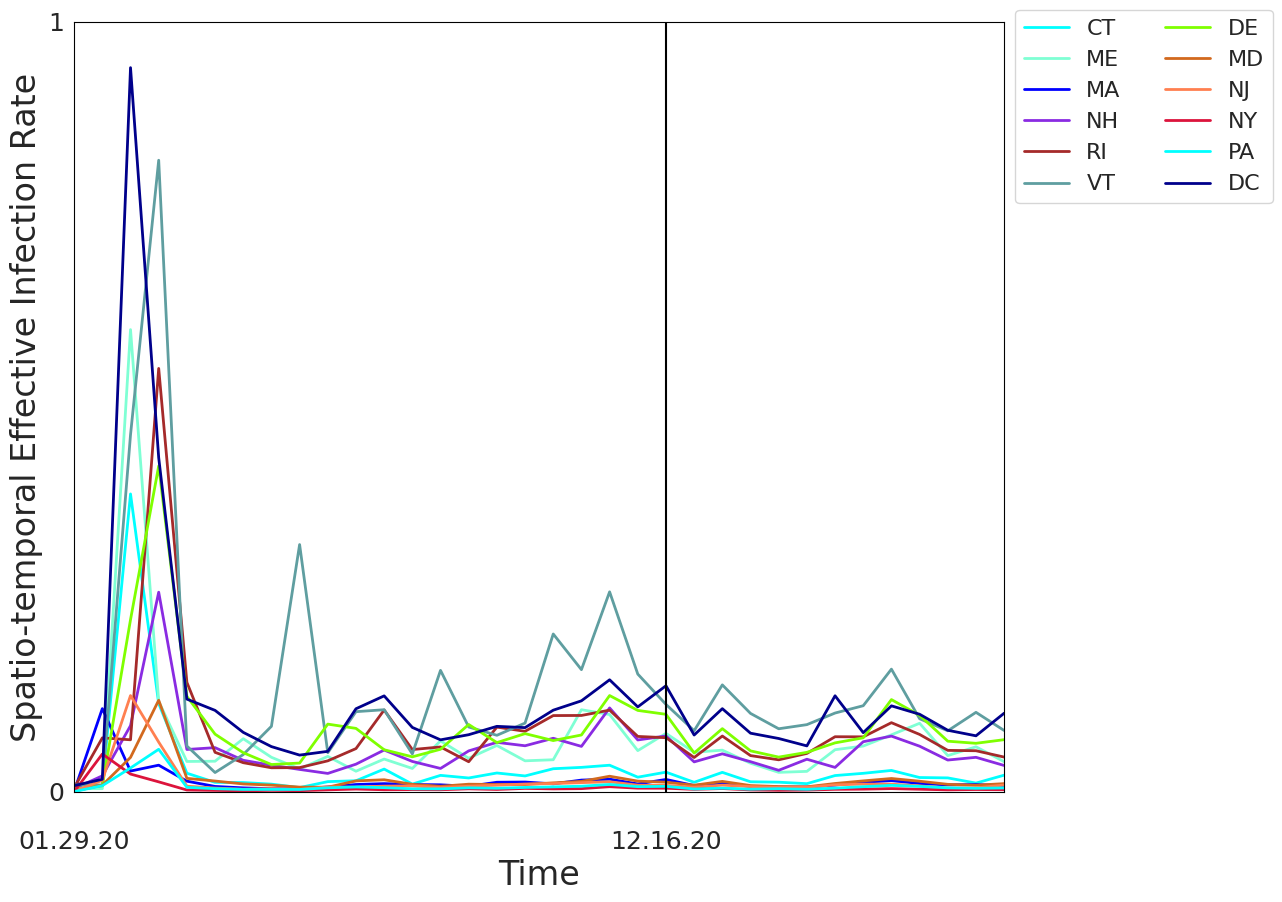

In [44]:
#SOLVING THE ORIGINAL PROBLEM
colors = [
    'Aqua', 'Aquamarine', 'Blue', 'BlueViolet', 'Brown', 'CadetBlue', 'Chartreuse', 'Chocolate',
    'Coral', 'Crimson', 'Cyan', 'DarkBlue', 'DarkCyan', 'DarkGoldenRod', 'DarkGray', 'DarkGreen',
    'DarkKhaki', 'DarkMagenta', 'DarkOliveGreen', 'DarkOrange', 'DarkOrchid', 'DarkRed',
    'DarkSalmon', 'DarkSeaGreen', 'DarkSlateBlue', 'DarkSlateGray', 'DarkTurquoise', 'DarkViolet',
    'DeepPink', 'DeepSkyBlue', 'DimGray', 'DodgerBlue', 'FireBrick', 'ForestGreen', 'Fuchsia',
    'Gold', 'GoldenRod', 'Gray', 'IndianRed', 'Indigo', 'LawnGreen', 'LightCoral', 'Lime',
    'Magenta', 'Maroon', 'MediumBlue', 'MediumOrchid', 'MediumPurple', 'MediumSeaGreen',
    'MediumSlateBlue', 'MediumSpringGreen', 'MediumTurquoise'
]
x1 = ['Dec','Jan','Jan','Feb','Feb','Mar','Mar','Apr','Apr','May']
x=range(0,34)
fig, ax = plt.subplots(figsize=(12, 10),facecolor='none')
y={}
txt=0
for s in states:
    y[s]=[]
    for t in range(1,4):
        y[s].append(5000*beta_s[s][t])
    for t in range(4,11):
        y[s].append(50000*beta_s[s][t])
    for t in range(11,35):
        y[s].append(50000*beta_s[s][t])
    print(s,y[s])
    ax.plot(x, y[s], linewidth=2.0, label=s,color=colors[txt])

    # plt.text(9.2,0.04*txt,s,fontsize=5, font='Helvetica 18 bold')
    txt+=1
# plot
plt.grid(False)
# x=[21]
# y=range(0,1)

ax.spines['bottom'].set_color('black')  # Bottom x-axis
ax.spines['left'].set_color('black')    # Left y-axis
ax.spines['top'].set_color('black')     # Top axis (optional)
ax.spines['right'].set_color('black')
plt.gcf().set_facecolor("none")
ax.set(xlim=(0, 33), xlabel="Time",
       ylim=(0,1), yticks=[0,1],ylabel="Spatio-temporal Effective Infection Rate")
ax.set_xlabel("Time", fontsize=24)  # Increased font size
ax.set_ylabel("Spatio-temporal Effective Infection Rate", fontsize=24)
# plt.xlabel(fontsize=12)
# plt.ylabel(fontsize=12)
plt.legend(fontsize=16,ncol=2,loc="upper left", bbox_to_anchor=(1,1.03))
# ax[0][0]=ax
plt.xticks(ticks=[0,21],labels=['\n01.29.20','\n12.16.20'],fontsize=18)
plt.yticks(fontsize=18)
plt.axvline(x=21,color='black')
plt.savefig('Beta.png')
plt.show()

In [ ]:
for s in states:
    print((sum(allocation.loc[allocation["State"]==s]['1st Dose Allocations Pfizer'])+sum(allocation.loc[allocation["State"]==s]['1st Dose Allocations Moderna'])+sum(allocation.loc[allocation["State"]==s]['1st Dose Allocations Janssen']))/Scale/popplus12_s[s]*10000)
    print(sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T))/popplus12_s[s] *10000)

### US Map

In [ ]:
# Dictionary of state capitals with their latitudes and longitudes
states_capital_0 = {
    # state_centers = {
    "Alabama": [32.8067, -86],
    "Alaska": [46.037, -127.00],
    # "Alaska": [61.3707, -152.4044],
    "Arizona": [33.7298, -111.4312],
    "Arkansas": [34.9697, -92.3731],
    "California": [36.1162, -118.6816],
    "Colorado": [39.0598, -105.3111],
    "Connecticut": [41, -71.7554],
    "Delaware": [38.7, -73],
    "Florida": [28, -81],
    "Georgia": [33.0406, -83],
        "Hawaii": [34.3, -127.00],
    # "Hawaii": [21.0943, -157.4983],
    "Idaho": [44.2405, -114.4788],
    "Illinois": [40.3495, -88.9861],
    "Indiana": [39.8494, -85.7],
    "Iowa": [42.0115, -93.2105],
    "Kansas": [38.5266, -96.7265],
    "Kentucky": [37.6681, -84.2],
    "Louisiana": [30.7, -91.8678],
    "Maine": [45.6939, -68.3819],
    "Maryland": [39.5, -76.8021],
    "Massachusetts": [42.5, -70.5301],
    "Michigan": [43.3266, -84.2],
    "Minnesota": [45.6945, -93.9002],
    "Mississippi": [32.7416, -89],
    "Missouri": [38.4561, -92.2884],
    "Montana": [46.9219, -110.4544],
    "Nebraska": [41.1254, -98.2681],
    "Nevada": [38.3135, -116.0554],
    "New Hampshire": [44.0, -70],
    "New Jersey": [40.2989, -73.9],
    "New Mexico": [34.8405, -106.2485],
    "New York": [43.1657, -74.9481],
    "North Carolina": [35.6301, -79],
    "North Dakota": [47.5289, -99.7840],
    "Ohio": [40.3888, -82.2],
    "Oklahoma": [35.5653, -96.9289],
    "Oregon": [44.5720, -121.0709],
    "Pennsylvania": [41, -77.2098],
    "Rhode Island": [41, -68.5118],
    "South Carolina": [33.8569, -80.4],
    "South Dakota": [44.2998, -99.4388],
    "Tennessee": [35.7478, -86.2],
    "Texas": [31.0545, -97.5635],
    "Utah": [40.1500, -111.8624],
    "Vermont": [45, -72.7107],
    "Virginia": [37.1, -78],
    "Washington": [47.4009, -120.4905],
    "West Virginia": [38.4912, -80],
    "Wisconsin": [44.2685, -89.6165],
    "Wyoming": [42.7559, -107.3025],
    "Washington, D.C.": [38, -75.5]}

#     "Alabama": [32.377, -86.300],
#     "Alaska": [47.037, -125.900],
#     "Arizona": [33.448, -112.074],
#     "Arkansas": [34.746, -92.290],
#     "California": [38.576, -121.494],
#     "Colorado": [39.739, -104.990],
#     "Connecticut": [41.764, -72.682],
#     "Delaware": [39.158, -75.524],
#     "Florida": [30.438, -84.280],
#     "Georgia": [33.749, -84.388],
#     "Hawaii": [30.438, -125.900],
#     "Idaho": [43.617, -116.199],
#     "Illinois": [39.798, -89.654],
#     "Indiana": [39.768, -86.162],
#     "Iowa": [41.591, -93.603],
#     "Kansas": [39.048, -95.677],
#     "Kentucky": [38.197, -84.863],
#     "Louisiana": [30.457, -91.187],
#     "Maine": [44.307, -69.781],
#     "Maryland": [38.978, -76.492],
#     "Massachusetts": [42.360, -71.058],
#     "Michigan": [42.732, -84.555],
#     "Minnesota": [44.953, -93.090],
#     "Mississippi": [32.303, -90.182],
#     "Missouri": [38.576, -92.173],
#     "Montana": [46.589, -112.021],
#     "Nebraska": [40.813, -96.702],
#     "Nevada": [39.163, -118.766],
#     "New Hampshire": [43.208, -71.537],
#     "New Jersey": [40.220, -74.772],
#     "New Mexico": [35.687, -105.938],
#     "New York": [42.652, -73.757],
#     "North Carolina": [35.780, -78.639],
#     "North Dakota": [46.808, -100.783],
#     "Ohio": [39.961, -82.999],
#     "Oklahoma": [35.467, -97.516],
#     "Oregon": [44.942, -123.035],
#     "Pennsylvania": [40.264, -76.883],
#     "Rhode Island": [41.823, -71.412],
#     "South Carolina": [34.000, -81.035],
#     "South Dakota": [44.367, -100.346],
#     "Tennessee": [36.162, -86.781],
#     "Texas": [30.267, -97.743],
#     "Utah": [40.760, -111.891],
#     "Vermont": [44.263, -72.575],
#     "Virginia": [37.540, -77.436],
#     "Washington": [47.037, -122.900],
#     "West Virginia": [38.349, -81.633],
#     "Wisconsin": [43.073, -89.401],
#     "Wyoming": [41.140, -104.820],
#     "Washington, D.C.": [38.9072, -77.0369]

# State abbreviations
state_abbreviations = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO",
    "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "Washington, D.C.": "DC"
}
InfectionDemandScore=[]
for s in states:
    InfectionDemandScore.append(beta[2,s]/max(beta[2,s]for s in states)**2+((sum((1-vac_hes[s,c])*popplus12[s,c] for c in counties[s]))/popplus12_s[s])**2)
# states_capitals={}
# for a in states:
#     for s in state_abbreviations.keys():
#         if state_abbreviations[s]==a:
state_capitals={}
regions=[]
for a in states:
    for s in state_abbreviations.keys():
        if state_abbreviations[s]==a:
            state_capitals[a]=states_capital_0[s]
            regions.append(s)
# Create DataFrame with random data
results_data = pd.DataFrame({
    "Region": regions,
    "Latitude": [coords[0] for coords in state_capitals.values()],
    "Longitude": [coords[1] for coords in state_capitals.values()],
    "Abbreviation": states,
    "Actual": [sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11))/popplus12_s[s] * 1000000
                  for s in states],
    "Optimized": [sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11))/popplus12_s[s] * 1000000
                  for s in states],
    "InfectionDemandScore": [((beta[2,s]/max(beta[2,s]for s in states))**2+((sum((1-vac_hes[s,c])*popplus12[s,c] for c in counties[s]))/popplus12_s[s])**2)/max((beta[2,s]/max(beta[2,s]for s in states))**2+((sum((1-vac_hes[s,c])*popplus12[s,c] for c in counties[s]))/popplus12_s[s])**2 for s in states) for s in states]
})

state_centers_adjusted = state_capitals.copy()

# Move Alaska to bottom left
# state_centers_adjusted["Alaska"] = [55.0, -130.0]   # shifted southeast
#
# # Move Hawaii to below California
# state_centers_adjusted["Hawaii"] = [25.0, -110.0]   # shifted northeast
# state_centers_by_abbrev = {}
# regions = []
# for abbr in states:
#     for state_name, state_abbr in state_abbreviations.items():
#         if state_abbr == abbr:
#             state_centers_by_abbrev[abbr] = state_centers_adjusted[state_name]
#             regions.append(state_name)
# results_data["Latitude"] = [coords[0] for coords in state_centers_by_abbrev.values()]
# results_data["Longitude"] = [coords[1] for coords in state_centers_by_abbrev.values()]
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
colormap = linear.Oranges_09.scale(results_data["InfectionDemandScore"].min(), results_data["InfectionDemandScore"].max())

from shapely.affinity import translate, scale
import geopandas as gpd

# Load GeoJSON into a GeoDataFrame
gdf = gpd.read_file(geojson_url)

# Adjust Alaska: shrink and move
alaska = gdf[gdf['name'] == 'Alaska']
gdf.loc[alaska.index, 'geometry'] = alaska.geometry.map(
    lambda geom: translate(scale(geom, xfact=0.2, yfact=0.2, origin='center'), xoff=29, yoff=-16)
)

# Adjust Hawaii: move east and slightly north
hawaii = gdf[gdf['name'] == 'Hawaii']
gdf.loc[hawaii.index, 'geometry'] = hawaii.geometry.map(
    lambda geom: translate(geom, xoff=29, yoff=15)
)
# Initialize the map with a minimal background
us_map = folium.Map(location=[37.8, -96], zoom_start=5, tiles=None,zoom_control=False,color='blue')
folium.GeoJson(gdf,
# data=results_data,
    columns=["Region", "InfectionDemandScore"],
    key_on="feature.properties.name",
    fillcolor="colormap",
               color="white",
               bordercolor="black",
               line_weight=1,
    fill_opacity=0.7,
    line_opacity=0.6,
    legend_name="Infection Demand Score").add_to(us_map)

# us_map = folium.Map(location=[30, -86], zoom_start=5, tiles=None,zoom_control=False,color='blue')
# folium.TileLayer("cartodbpositron", name="Light Background").add_to(us_map)

# Define a colormap for infection-demand score

# Use a public GeoJSON URL for US states


# Add shaded regions based on Infection-Demand Score
folium.Choropleth(
    geo_data=geojson_url,
    name="choropleth",
    data=results_data,
    columns=["Region", "InfectionDemandScore"],
    key_on="feature.properties.name",
    fill_color="Greys",
    threshold_scale=[0.3,0.4,0.5,0.6, 0.7, 0.8, 0.9, 1],  # custom breaks
    fill_opacity=0.6,
    line_opacity=0.5,
    legend_name="Infection Demand Score"
).add_to(us_map)
#     legend_name=None  # disable default legend
# ).add_to(us_map)
#
# # Create a custom color map with larger size
# colormap = linear.Oranges_09.scale(
#     results_data["InfectionDemandScore"].min(),
#     results_data["InfectionDemandScore"].max()
# )
# colormap.caption = 'Infection Demand Score'
#
# # Manually set width and height
# colormap.width = 500  # increase from default ~250
# colormap.height = 40  # adjust if needed
# colormap.add_to(us_map)
from branca.element import Template, MacroElement

# Add a heatmap for infection demand scores
heat_data = [
    [0,0,row["InfectionDemandScore"]] for _, row in results_data.iterrows()
]
# colormap.width = 400
# colormap.caption = 'Infection Demand Score'
 # wider than default
# colormap.add_to(us_map)
HeatMap(heat_data, radius=25, blur=10, max_zoom=15).add_to(us_map)
# colormap.caption = 'Infection Demand Score'
 # wider than default
# colormap.add_to(us_map)

# A
# dd circles and abbreviations for actual and optimized values

for _, row in results_data.iterrows():
    # Actual data circles
    # height = val * scale
    # folium.Rectangle(
    #     bounds=[(row["Latitude"], row["Longitude"] - 0.02), (row["Latitude"] + row["Actual"]/100, row["Longitude"] + 0.02)],
    #     color='blue',
    #     fill=True,
    #     fill_opacity=0.7,
    #      tooltip=f"Actual: {row['Actual']}"
    # ).add_to(us_map)
    folium.Circle(
        location=[row["Latitude"], row["Longitude"]-1.4],
        radius=row["Actual"] * 1000,
        color="deepskyblue",
        fill=True,
        fill_opacity=0.8,
        tooltip=f"Actual: {row['Actual']}"
    ).add_to(us_map)
    # folium.Rectangle(
    #     bounds=[(row["Latitude"], row["Longitude"]-1 -0.02), (row["Latitude"] + row['Optimized']/100, row["Longitude"]-1 + 0.02)],
    #     color='yellow',
    #     fill=True,
    #     fill_opacity=0.7,
    #      tooltip=f"Optimized: {row['Optimized']}"
    # ).add_to(us_map)
    # Optimized data circles
    folium.Circle(
        location=[row["Latitude"], row["Longitude"]],
        radius=row["Optimized"] * 1000,
        color="darkorange",
        fill=True,
        fill_opacity=0.8,
        tooltip=f"Optimized: {row['Optimized']}"
    ).add_to(us_map)

    # Add state abbreviation
    folium.Marker(
        location=[row["Latitude"]+1,row["Longitude"]-0.8],
        icon=folium.DivIcon(
            html=f"<div style='font-size: 18px; color: black;'><b>{row['Abbreviation']}</b></div>"
        )
    ).add_to(us_map)

# Add a legend for the circles
legend_html = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 200px; height: 100px;
            background-color: white; z-index:9999; font-size:18px;
            border:2px solid grey; padding: 10px;">
    <b>Allocations</b><br>
    <i style="background: deepskyblue; width: 16px; height: 16px; display: inline-block;"></i> Actual<br>
    <i style="background: darkorange; width: 16px; height: 16px; display: inline-block;"></i> Optimized
</div>
'''
legend_style = """
{% macro html(this, kwargs) %}
<style>
    .leaflet-control .legend {
        font-size: 36px !important;
        line-height:36px;
    }
</style>
{% endmacro %}
"""
style = """
{% macro html(this, kwargs) %}
<style>
/* Target the legend container */
div.legend {
    font-size: 18px !important;
    line-height: 36px;            /* More vertical space between ticks */
    padding: 18px 18px !important;
    height: 2000px;
    font-weight: bold;
    # background-color: white;
    # border: 2px solid #ccc;
    box-shadow: none !important;
    margin-top: 100px;            /* Push the legend lower */
}

/* Style the caption text */
div.legend .caption {
    font-size: 18px !important;
    font-weight: bold;
    margin-top: 80px;
}

/* Style tick labels */
div.legend .tick-label {
    font-size: 18px !important;
    margin-bottom: 10px;
    font-weight: bold;
}
</style>
{% endmacro %}
"""
custom_legend_html = """
{% macro html(this, kwargs) %}

<div style='
    position: fixed;
    bottom: 30px;
    left: 30px;
    width: 320px;
    height: auto;
    z-index:9999;
    font-size: 16px;
    background-color: white;
    padding: 12px;
    border: 2px solid #444;
    box-shadow: 2px 2px 5px rgba(0,0,0,0.4);
'>

<b>Infection Demand Score</b>
<div style="margin-top: 12px;">  <!-- ⬅️ Controls distance from caption -->

<!-- Grayscale gradient bar -->
<div style="
    height: 20px;
    background: linear-gradient(to right, #f0f0f0, #222);
    border: 1px solid #aaa;
"></div>

<!-- Labels under the bar -->
<div style="display: flex; justify-content: space-between; font-size: 14px; margin-top: 6px;">
    <span>0.3</span><span>0.4</span><span>0.5</span><span>0.6</span><span>0.7</span><span>0.8</span><span>0.9</span><span>1.0</span>
</div>

</div>
</div>

{% endmacro %}
"""

us_map.get_root().html.add_child(folium.Element(legend_html))
macro = MacroElement()
macro._template = Template(style)
us_map.get_root().add_child(macro)
# Save and display the map
output_path = "us_map_infection_demand.html"
us_map.save(output_path)
print("Map saved as 'us_map_infection_demand.html'")


In [ ]:
regions={
    'New_England':['CT','ME','MA','NH','RI','VT'],
    'Middle_Atlantic':['DE','MD','NJ','NY','PA','DC'],
    'South':['AL','AR','FL','GA','KY','LA','MS','MO','NC','SC','TN','VA','WV'],
    'Midwest':['IL','IN','IA','KS','MI','MN','NE','ND','OH','SD','WI'],
    'Southwest':['AZ','NM','OK','TX'],
    'West':['AK','CA','CO','HI','ID','MT','NV','OR','UT','WA','WY']
        }

In [ ]:
# Dictionary of state capitals with their latitudes and longitudes
states_capital_0 = {
    # state_centers = {
    "Alabama": [32.8067, -86],
    "Alaska": [46.037, -127.00],
    # "Alaska": [61.3707, -152.4044],
    "Arizona": [33.7298, -111.4312],
    "Arkansas": [34.9697, -92.3731],
    "California": [36.1162, -118.6816],
    "Colorado": [39.0598, -105.3111],
    "Connecticut": [41, -71.7554],
    "Delaware": [38.7, -73],
    "Florida": [28, -80],
    "Georgia": [33.0406, -83],
        "Hawaii": [34.3, -127.00],
    # "Hawaii": [21.0943, -157.4983],
    "Idaho": [44.2405, -114.4788],
    "Illinois": [40.3495, -88.9861],
    "Indiana": [39.8494, -85.7],
    "Iowa": [42.0115, -93.2105],
    "Kansas": [38.5266, -96.7265],
    "Kentucky": [37.6681, -84.2],
    "Louisiana": [30.7, -91.8678],
    "Maine": [45.6939, -68.3819],
    "Maryland": [39.5, -76.8021],
    "Massachusetts": [42.5, -70.5301],
    "Michigan": [43.3266, -84.2],
    "Minnesota": [45.6945, -93.9002],
    "Mississippi": [32.7416, -89],
    "Missouri": [38.4561, -92.2884],
    "Montana": [46.9219, -110.4544],
    "Nebraska": [41.1254, -98.2681],
    "Nevada": [38.3135, -116.0554],
    "New Hampshire": [44.0, -70],
    "New Jersey": [40.2989, -73.9],
    "New Mexico": [34.8405, -106.2485],
    "New York": [43.1657, -74.9481],
    "North Carolina": [35.6301, -79],
    "North Dakota": [47.5289, -99.7840],
    "Ohio": [40.3888, -82.2],
    "Oklahoma": [35.5653, -96.9289],
    "Oregon": [44.5720, -121.0709],
    "Pennsylvania": [41, -77.2098],
    "Rhode Island": [41, -68.5118],
    "South Carolina": [33.8569, -80.4],
    "South Dakota": [44.2998, -99.4388],
    "Tennessee": [35.7478, -86.2],
    "Texas": [31.0545, -97.5635],
    "Utah": [40.1500, -111.8624],
    "Vermont": [45, -72.7107],
    "Virginia": [37.1, -78],
    "Washington": [47.4009, -120.4905],
    "West Virginia": [38.4912, -80],
    "Wisconsin": [44.2685, -89.6165],
    "Wyoming": [42.7559, -107.3025],
    "Washington, D.C.": [38, -75.5]}


# State abbreviations
state_abbreviations = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO",
    "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA",
    "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "Washington, D.C.": "DC"
}
InfectionDemandScore=[int(sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11)) * 10-sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11)) * 10)
                  for s in states]
# states_capitals={}
# for a in states:
#     for s in state_abbreviations.keys():
#         if state_abbreviations[s]==a:
state_capitals={}
regions=[]
for a in states:
    for s in state_abbreviations.keys():
        if state_abbreviations[s]==a:
            state_capitals[a]=states_capital_0[s]
            regions.append(s)
# Create DataFrame with random data
results_data = pd.DataFrame({
    "Region": regions,
    "Latitude": [coords[0] for coords in state_capitals.values()],
    "Longitude": [coords[1] for coords in state_capitals.values()],
    "Abbreviation": states,
    "Actual": [sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11))/popplus12_s[s] * 1000000
                  for s in states],
    "Optimized": [sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11))/popplus12_s[s] * 1000000
                  for s in states],
    "InfectionDemandScore": [int(sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11)) * 10-sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11)) * 10)
                  for s in states]
})

state_centers_adjusted = state_capitals.copy()

# Move Alaska to bottom left
# state_centers_adjusted["Alaska"] = [55.0, -130.0]   # shifted southeast
#
# # Move Hawaii to below California
# state_centers_adjusted["Hawaii"] = [25.0, -110.0]   # shifted northeast
# state_centers_by_abbrev = {}
# regions = []
# for abbr in states:
#     for state_name, state_abbr in state_abbreviations.items():
#         if state_abbr == abbr:
#             state_centers_by_abbrev[abbr] = state_centers_adjusted[state_name]
#             regions.append(state_name)
# results_data["Latitude"] = [coords[0] for coords in state_centers_by_abbrev.values()]
# results_data["Longitude"] = [coords[1] for coords in state_centers_by_abbrev.values()]
geojson_url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
colormap = linear.Oranges_09.scale(results_data["InfectionDemandScore"].min(), results_data["InfectionDemandScore"].max())

from shapely.affinity import translate, scale
import geopandas as gpd

# Load GeoJSON into a GeoDataFrame
gdf = gpd.read_file(geojson_url)

# Adjust Alaska: shrink and move
alaska = gdf[gdf['name'] == 'Alaska']
gdf.loc[alaska.index, 'geometry'] = alaska.geometry.map(
    lambda geom: translate(scale(geom, xfact=0.2, yfact=0.2, origin='center'), xoff=29, yoff=-16)
)

# Adjust Hawaii: move east and slightly north
hawaii = gdf[gdf['name'] == 'Hawaii']
gdf.loc[hawaii.index, 'geometry'] = hawaii.geometry.map(
    lambda geom: translate(geom, xoff=29, yoff=15)
)
# Initialize the map with a minimal background
us_map = folium.Map(location=[37.8, -96], zoom_start=5, tiles=None,zoom_control=False,color='blue')
folium.GeoJson(gdf,
# data=results_data,
    columns=["Region", "InfectionDemandScore"],
    key_on="feature.properties.name",
    fillcolor="colormap",
               color="white",
               bordercolor="white",
               line_weight=1,
    fill_opacity=0.7,
    line_opacity=0.6,
    legend_name="Infection Demand Score").add_to(us_map)

# us_map = folium.Map(location=[30, -86], zoom_start=5, tiles=None,zoom_control=False,color='blue')
# folium.TileLayer("cartodbpositron", name="Light Background").add_to(us_map)

# Define a colormap for infection-demand score

# Use a public GeoJSON URL for US states


# Add shaded regions based on Infection-Demand Score
folium.Choropleth(
    geo_data=gdf,
    name="choropleth",
    data=results_data,
    columns=["Region", "InfectionDemandScore"],
    key_on="feature.properties.name",
    fill_color="RdBu",
    fill_opacity=1,
    line_opacity=0.5,
    legend_name="Infection Demand Score"
).add_to(us_map)
#     legend_name=None  # disable default legend
# ).add_to(us_map)
#
# # Create a custom color map with larger size
# colormap = linear.Oranges_09.scale(
#     results_data["InfectionDemandScore"].min(),
#     results_data["InfectionDemandScore"].max()
# )
# colormap.caption = 'Infection Demand Score'
#
# # Manually set width and height
# colormap.width = 500  # increase from default ~250
# colormap.height = 40  # adjust if needed
# colormap.add_to(us_map)
from branca.element import Template, MacroElement

# Add a heatmap for infection demand scores
heat_data = [
    [0,0,row["InfectionDemandScore"]] for _, row in results_data.iterrows()
]
# colormap.width = 400
# colormap.caption = 'Infection Demand Score'
 # wider than default
# colormap.add_to(us_map)
HeatMap(heat_data, radius=25, blur=10, max_zoom=15).add_to(us_map)
# colormap.caption = 'Infection Demand Score'
 # wider than default
# colormap.add_to(us_map)

# A
# dd circles and abbreviations for actual and optimized values

for _, row in results_data.iterrows():

    # folium.Circle(
    #     location=[row["Latitude"], row["Longitude"]-1.4],
    #     radius=row["Actual"] * 1000,
    #     color="deepskyblue",
    #     fill=True,
    #     fill_opacity=0.8,
    #     tooltip=f"Actual: {row['Actual']}"
    # ).add_to(us_map)

    # folium.Circle(
    #     location=[row["Latitude"], row["Longitude"]],
    #     radius=row["Optimized"] * 1000,
    #     color="darkorange",
    #     fill=True,
    #     fill_opacity=0.8,
    #     tooltip=f"Optimized: {row['Optimized']}"
    # ).add_to(us_map)

    # Add state abbreviation
    folium.Marker(
        location=[row["Latitude"],row["Longitude"]],
        icon=folium.DivIcon(
            html=f"<div style='font-size: 20px; color: black;'><b>{row['Abbreviation']}</b></div>"
        )
    ).add_to(us_map)
    folium.Marker(
        location=[row["Latitude"]-1,row["Longitude"]],
        icon=folium.DivIcon(
            html=f"<div style='font-size: 18px; color: black;'><b>{row['InfectionDemandScore']}</b></div>"
        )
    ).add_to(us_map)

# Add a legend for the circles

legend_html = """
{% macro html(this, kwargs) %}
<div style='
    position: fixed;
    bottom: 30px;
    left: 30px;
    width: 280px;
    background-color: white;
    padding: 10px;
    border: 2px solid grey;
    z-index: 9999;
    font-size: 14px;
'>
<b>Vote Margin</b><br>
<div style="height: 20px; background: linear-gradient(to right, #08306b, #6baed6, #ccc, #fb6a4a, #a50f15); margin-top: 10px;"></div>
<div style="display: flex; justify-content: space-between;">
  <span style="color: #08306b;">D+1M</span>
  <span>0</span>
  <span style="color: #a50f15;">R+1M</span>
</div>
</div>
{% endmacro %}
"""
from branca.colormap import linear
state_capitals_mn={
    "CT": [35, -72],
    "DE": [3, -72],
    "MD": [40, -72],
    "MA": [40, -72],
    "NJ": [30, -72],
    "RI": [40, -72],
    "DC": [40, -72],
}
# Optional: dynamic color by votes
InfectionDemandScore_mn={s:int(sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11)) * 10-sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11)) * 10)
                  for s in state_capitals_mn.keys()}
from branca.colormap import LinearColormap

red_blue_custom = LinearColormap(
    colors=["darkred", "white", "darkblue"],
    vmin=   pd.DataFrame.from_dict(InfectionDemandScore_mn, orient='index').min(),
    vmax= pd.DataFrame.from_dict(InfectionDemandScore_mn,orient='index').max()
)

# red_blue_colormap = linear.RdBu_11.scale(
#    pd.DataFrame.from_dict(InfectionDemandScore_mn, orient='index').min(),
#     pd.DataFrame.from_dict(InfectionDemandScore_mn,orient='index').max()
# )

for abbr, votes in InfectionDemandScore_mn.items():
    lat, lon = state_capitals_mn[abbr] if abbr in state_capitals_mn else (None, None)
    if lat and lon:
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(html=f"""
                <div style="
                    background_color = red_blue_custom(value);
                    color: white;
                    font-weight: bold;
                    border-radius: 4px;
                    padding: 6px 14px;   /* ⬅️ Wider horizontal padding */
                    font-size: 14px;
                    text-align: center;
                    min-width: 70px;     /* ⬅️ Minimum width */
                    box-shadow: 1px 1px 2px rgba(0,0,0,0.3);
                    display: inline-block;
                ">
                    {abbr} {votes}
                </div>
            """)
        ).add_to(us_map)


us_map.get_root().html.add_child(folium.Element(legend_html))
legend = MacroElement()
legend._template = Template(legend_html)
us_map.get_root().add_child(legend)
# Save and display the map
output_path = "us_map_infection_demand.html"
us_map.save(output_path)
print("Map saved as 'us_map_infection_demand.html'")


In [ ]:
print(df[df['margin'].isna() | (df['margin'] == 0)])
-max([int(-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11)) * 10+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11)) * 10)for s in states])

In [ ]:
list(df.loc[~df['state'].isin(state_capitals_mn)]['state'])
[int(-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,11)) * 10+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11)) * 10)for s in states]

### New Map

In [47]:
import plotly.graph_objects as go
import pandas as pd
alloc={}
te = 11
for s in states:
    alloc[s]=-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,te)) * 10+sum(W3_p[te-1,s,c,l] for c in counties[s] for l in range(int(np.ceil(local_centers[s,c]))))*10
state_capitals_mn=['VT','NH','MA','NJ', 'RI','CT','DE','MD','DC']

# Dictionary of electoral voteselectoral_votes = {state: votes for state, votes, _ in data}

data=  [(s,round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2 ))for s in states]


df = pd.DataFrame(data, columns=["state","margin"])

# Create Choropleth map

fig = go.Figure(go.Choropleth(
    locations=df.state, locationmode="USA-states",
    z=df.margin, zmin=min(df.margin), zmax=max(df.margin), zmid=np.median(df.margin),
    colorscale=[
        [0.0, 'gold'],[0.20, 'yellow'],[0.3, 'lemonchiffon'],[0.4,'white'],
        [0.50,'aliceblue'],[0.75,'cornflowerblue'],[1,'blue']
    ],
    showscale=True,
    # colorscale='sunset',
colorbar=dict(
    title=dict(
        text="Over/Under<br>Allocations<br>(x1M)",
        font=dict(color="black", size=12)
    ),
    tickfont=dict(color="black")
)
    # x=0.92,
    # y=0.5,
    # len=0.75
    )
)

fig.add_trace(go.Scattergeo(
    locations=df.loc[~df['state'].isin(state_capitals_mn)].state,
    # locations=states,
    locationmode="USA-states",
    text=[f"<b>{s}<br>{round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) }</b>" for s
          # in states
          in list(df.loc[~df['state'].isin(state_capitals_mn)]['state'])
          ],
    mode="text",
    textfont=dict(size=10, color="black"),
    showlegend=False,
    geo='geo'
))


small_states_box = [
    ("VT", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['VT'])),
    ("NH", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['NH'])),
    ("MA", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['MA'])) ,
    ("NJ", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['NJ'])  ),
     ("RI", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,3) for s in['RI'])  ),
     ("CT",sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['CT'])  ),
     ("DE",sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['DE'])  ),
     ("MD", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['MD'])  ),
     ("DC", sum(round((alloc[s]+sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,te)) * 10)/1000,2) for s in['DC']) )
]

# Build the text content
box_text = "<br>".join([f"<b>{s} {ev}</b>" for s, ev in small_states_box])

# Add the annotation to the layout (mimics a fixed side box)
fig.update_layout(
    annotations=[
        dict(
            text=box_text,
            x=1.03,  # just outside the map
            y=0.45,
            xref='paper',
            yref='paper',
            align='left',
            showarrow=False,
            font=dict(size=11, color="black"),
            bgcolor="lemonchiffon",  # Democratic blue
            bordercolor="black",
            borderwidth=1,
            borderpad=5
        )
    ]
)


# Layout tweaks for exact style
fig.update_layout(
    title_text="2024 Margin + Electoral Votes",
    geo=dict(scope="usa", projection_type='albers usa'),
    margin=dict(l=0,r=0,t=40,b=0)
)
fig.update_layout(
    paper_bgcolor="white",  # Entire figure background
    plot_bgcolor="white",   # Plot area background
    geo=dict(
        scope="usa",
        projection_type="albers usa",
        showland=True,
        landcolor="white",   # Land inside the map
        bgcolor="white",     # Background behind the map
        domain=dict(x=[0, 0.0], y=[0, 1])
    ),
    title="2024 Electoral Map with Inset Box for Small States",
    margin=dict(l=0, r=0, t=0, b=0),
)
fig.show()
    # fig.write_image(f'map{colscaleselection}.png', scale=2)


In [77]:
max(df.margin)-min(df.margin)
float(np.median(df.margin))

0.02

In [83]:
sum(supply[t,i,s]*Scale for i in [1,2,3] for t in range(0,11) for s in states)

150337905.0

In [ ]:
for s in states:
    print(s,state_vaccine[s][10], sum(Vac_state[t,s] for t in range(11))*Scale,sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11))*Scale,sum(supply[t,i,s]*Scale for i in [1,2,3] for t in range(0,11))-sum(W3_p[10,s,c,l] for s in states for c in counties[s] for l in range(int(np.ceil(local_centers[s,c])))))

In [ ]:
#SOLVING THE ORIGINAL PROBLEM
colors = [
    'Aqua', 'Aquamarine', 'Blue', 'BlueViolet', 'Brown', 'CadetBlue', 'Chartreuse', 'Chocolate',
    'Coral', 'Crimson', 'Cyan', 'DarkBlue', 'DarkCyan', 'DarkGoldenRod', 'DarkGray', 'DarkGreen',
    'DarkKhaki', 'DarkMagenta', 'DarkOliveGreen', 'DarkOrange', 'DarkOrchid', 'DarkRed',
    'DarkSalmon', 'DarkSeaGreen', 'DarkSlateBlue', 'DarkSlateGray', 'DarkTurquoise', 'DarkViolet',
    'DeepPink', 'DeepSkyBlue', 'DimGray', 'DodgerBlue', 'FireBrick', 'ForestGreen', 'Fuchsia',
    'Gold', 'GoldenRod', 'Gray', 'IndianRed', 'Indigo', 'LawnGreen', 'LightCoral', 'Lime',
    'Magenta', 'Maroon', 'MediumBlue', 'MediumOrchid', 'MediumPurple', 'MediumSeaGreen',
    'MediumSlateBlue', 'MediumSpringGreen', 'MediumTurquoise'
]
x=range(0,34)
fig, ax = plt.subplots(figsize=(12, 10),facecolor='none')
y={}
txt=0
for s in ['NH']:
    ax.plot([(10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] * I01[t, s])/popplus12_s[s]*10000 for t in range(0, 12)],[sum(supply[t,i,s] for i in [1,2,3])* 1000000/100/popplus12_s[s]  for t in range(0,T) ], linewidth=2.0, label=s,color=colors[txt])

    # plt.text(9.2,0.04*txt,s,fontsize=5, font='Helvetica 18 bold')
    txt+=1
# plot
plt.grid(False)
# x=[21]
# y=range(0,1)

ax.spines['bottom'].set_color('black')  # Bottom x-axis
ax.spines['left'].set_color('black')    # Left y-axis
ax.spines['top'].set_color('black')     # Top axis (optional)
ax.spines['right'].set_color('black')
plt.gcf().set_facecolor("none")
ax.set( xlabel="Time",ylabel="Spatio-temporal Effective Infection Rate")
ax.set_xlabel("Time", fontsize=24)  # Increased font size
ax.set_ylabel("Spatio-temporal Effective Infection Rate", fontsize=24)
# plt.xlabel(fontsize=12)
# plt.ylabel(fontsize=12)
plt.legend(fontsize=14,ncol=2,loc="upper left", bbox_to_anchor=(1, 1))
# ax[0][0]=ax
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.axvline(x=21,color='black')
plt.savefig('Beta.png')
plt.show()

In [ ]:
#SOLVING THE ORIGINAL PROBLEM
colors = [
    'Aqua', 'Aquamarine', 'Blue', 'BlueViolet', 'Brown', 'CadetBlue', 'Chartreuse', 'Chocolate',
    'Coral', 'Crimson', 'Cyan', 'DarkBlue', 'DarkCyan', 'DarkGoldenRod', 'DarkGray', 'DarkGreen',
    'DarkKhaki', 'DarkMagenta', 'DarkOliveGreen', 'DarkOrange', 'DarkOrchid', 'DarkRed',
    'DarkSalmon', 'DarkSeaGreen', 'DarkSlateBlue', 'DarkSlateGray', 'DarkTurquoise', 'DarkViolet',
    'DeepPink', 'DeepSkyBlue', 'DimGray', 'DodgerBlue', 'FireBrick', 'ForestGreen', 'Fuchsia',
    'Gold', 'GoldenRod', 'Gray', 'IndianRed', 'Indigo', 'LawnGreen', 'LightCoral', 'Lime',
    'Magenta', 'Maroon', 'MediumBlue', 'MediumOrchid', 'MediumPurple', 'MediumSeaGreen',
    'MediumSlateBlue', 'MediumSpringGreen', 'MediumTurquoise'
]
x=range(0,34)
fig, ax = plt.subplots(figsize=(12, 10),facecolor='none')
ax = fig.add_subplot(111, projection='3d')

y={}
txt=0
for s in states:
    X=range(0,T)
    Y=[(10000*beta[t,s] * S01[t, s] * I01[t, s] + effec*10000*beta[t,s] *  V01[t, s] *I01[t, s])/popplus12_s[s]*10000 for t in range(0, 12)]

    Z = [sum(supply[t,i,s] for i in [1,2,3])* 1000000/100/popplus12_s[s]  for t in range(0,T) ]  # define a surface

    ax.plot(X, Y, Z, linewidth=2.0, label=s,color=colors[txt])

    # plt.text(9.2,0.04*txt,s,fontsize=5, font='Helvetica 18 bold')
    txt+=1
# plot
plt.grid(False)
# x=[21]
# y=range(0,1)

ax.spines['bottom'].set_color('black')  # Bottom x-axis
ax.spines['left'].set_color('black')    # Left y-axis
ax.spines['top'].set_color('black')     # Top axis (optional)
ax.spines['right'].set_color('black')
plt.gcf().set_facecolor("none")
# ax.set( xlabel="Time",ylabel="Spatio-temporal Effective Infection Rate")
ax.set_xlabel("Time", fontsize=24)  # Increased font size
ax.set_ylabel("Infection Per Capita", fontsize=24)
# plt.xlabel(fontsize=12)
# plt.ylabel(fontsize=12)
plt.legend(fontsize=14,ncol=2,loc="upper left", bbox_to_anchor=(1, 1))
# ax[0][0]=ax
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.axvline(x=21,color='black')
plt.savefig('Beta.png')
plt.show()

# # Plot
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')  # create 3D axis
# ax.plot(X, Y, Z) # surface plot with colormap
#
# ax.set_title("3D Surface Plot")
# ax.set_xlabel("X-axis")
# ax.set_ylabel("Y-axis")
# ax.set_zlabel("Z-axis")
#
# plt.show()

In [45]:

actual={}
for s in states:
    actual[s]=sum(Pi_pfi[s][t]+Pi_jan[s][t]+Pi_mod[s][t] for t in range(0,11) )
for s in states:
    print(s,sum(X_of[t,s] for t in range(1,T-1)))
actual
for s in states:
    print(s,sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1)),actual[s])

NameError: name 'X_of' is not defined

In [ ]:
sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] )))


In [ ]:
diffp={}
diff={}
reldiffp={}
for s in states:
    diffp[s]=abs(actual[s]-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1))+ sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] ))))
    reldiffp[s]=abs(actual[s]-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1))+sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] ))))/actual[s]
    diff[s]=actual[s]-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1))+sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] )))
# Sort and take top 10
sorted_items = sorted(diffp.items(), key=lambda x: x[1], reverse=True)[:10]

# Convert to dictionary
top_10p= {k: int(v/100) for k, v in sorted_items}
top_10={}
sorted_items = sorted(reldiffp.items(), key=lambda x: x[1], reverse=True)[:10]
top_10_r= {k: v for k, v in sorted_items}
for s in top_10p.keys():
    top_10[s]= round(diff[s]/100,2)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example data

labels = list(top_10_r.keys())

sizes = list(top_10_r.values())
hatches = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*']
state_colors ={}
# Custom colors for text
for s in labels:
    if actual[s]-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1))+sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] ))) >=0:
        state_colors[s]='gray'
    if actual[s]-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1))+sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] ))) <=0:
        state_colors[s]='khaki'
# state_colors = {
#     'CA': 'blue', 'FL': 'green', 'NY': 'orange', 'TX': 'purple', 'MA': 'brown',
#     'OH': 'pink', 'CT': 'gray', 'GA': 'olive', 'NJ': 'cyan', 'MO': 'magenta'
# }

fig, ax = plt.subplots(figsize=(10, 6))
wedges, texts= ax.pie(
    sizes,
    startangle=90,
    colors=['white'] * len(sizes),
    wedgeprops=dict(edgecolor='black'),
    pctdistance=0.8
)

# Add hatching
for wedge, hatch in zip(wedges, hatches):
    wedge.set_hatch(hatch)

# Set inside percentage text color to red
# for autotext in autotexts:
#     autotext.set_color('red')

# Add state names on wedges with custom colors
for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle)) * 1.15
    y = np.sin(np.deg2rad(angle)) * 1.15
    ax.text(x, y, f"{labels[i]}\n {int(sizes[i]*100)}%",ha='center', va='center',  fontsize=11, color=state_colors[labels[i]])
# 
# Title
# ax.set_title("Top 10 States by Absolute Relative Vaccine Allocation Difference")

# Legend below
ax.legend(
    wedges,
    [f"{label} ({size:,} M)" for label, size in zip(labels,[round((actual[s]-sum(supply[t,i,s] for i in [1,2,3] for t in range(0,T-1))+sum(W3_p[10,s,c,l] for c in counties[s] for l in range(int(local_centers[s,c] ))))/100,2) for s in labels])],
    # title="States",
    loc='lower center',
    fontsize=10,
    bbox_to_anchor=(0.5, -0.3),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.35)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example time points (replace with actual values if available)
time = np.arange(1, 12)

# Example data for demonstration (replace with your real data)
baseline = np.linspace(1e6, 2.2e7, 11)
def var_curve(scale): return baseline * scale

# Simulated data for each sensitivity case
data = {
    "Supply": [baseline, var_curve(0.95), var_curve(1.05)],
    "Budget": [baseline, var_curve(1.1), var_curve(0.85)],
    "Infection Rate": [baseline, var_curve(8), var_curve(0.3)],
    "Vaccine Effectiveness": [baseline, var_curve(0.95), var_curve(1.15)],
    "Capacity": [baseline, var_curve(1.01), var_curve(0.99)],
    "Demand": [baseline, var_curve(1.02), var_curve(0.98)]
}

titles = {
    "Supply": "Sensitivity Analysis for Supply",
    "Budget": "Sensitivity Analysis for Budget",
    "Infection Rate": "Sensitivity Analysis for Infection Rate",
    "Vaccine Effectiveness": "Sensitivity Analysis for Vaccine Effectiveness",
    "Capacity": "Sensitivity Analysis for Capacity",
    "Demand": "Sensitivity Analysis for Demand"
}

labels = {
    "Supply": ['Baseline', 'Lower Supply', 'Higher Supply'],
    "Budget": ['Baseline', 'Lower Budget', 'Higher Budget'],
    "Infection Rate": ['Baseline', 'Lower Infection Rate', 'Higher Infection Rate'],
    "Vaccine Effectiveness": ['Baseline', 'Lower Vaccine Effectiveness', 'Higher Vaccine Effectiveness'],
    "Capacity": ['Baseline', 'Lower Capacity', 'Higher Capacity'],
    "Demand": ['Baseline', 'Lower Demand', 'Higher Demand']
}

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (key, values) in enumerate(data.items()):
    ax = axes[i]
    for j in range(3):
        ax.plot(time, values[j], label=labels[key][j], marker='o')
    ax.set_title(f"{titles[key]}\n(Based on Cumulative Infections)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Cumulative Infections")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# --- US STATE MAP VISUALIZATION (DATA EMBEDDED, READY TO RUN) ---

import re
import pandas as pd
import plotly.express as px

RAW = r"""
0 CT 0 3 0 0 0 CT 0 3 0 0 0 CT 0 3 0 0 0 CT 0 3 0 0 0 CT 0 3 0 0
1 CT 21 5 0 0 1 CT 21 5 0 0 1 CT 21 5 0 0 1 CT 21 5 0 0 1 CT 38 5 -16 0
2 CT 9 8 0 0 2 CT 9 8 0 0 2 CT 9 8 0 0 2 CT 9 8 0 0 2 CT 16 8 -7 0
3 CT 9 6 0 0 3 CT 0 6 10 0 3 CT 9 6 0 0 3 CT 9 6 0 0 3 CT 17 6 -7 0
4 CT 11 10 0 0 4 CT 11 10 0 0 4 CT 11 10 0 0 4 CT 11 10 0 0 4 CT 20 10 -9 0
5 CT 18 25 0 0 5 CT 18 25 0 1 5 CT 18 25 0 0 5 CT 18 25 0 0 5 CT 32 25 -14 0
6 CT 17 52 0 1 6 CT 1 52 16 1 6 CT 17 52 0 0 6 CT 17 52 0 1 6 CT 30 52 -13 1
7 CT 20 31 0 0 7 CT 16 31 3 1 7 CT 20 31 0 0 7 CT 20 31 0 0 7 CT 44 31 -20 0
8 CT 23 36 0 0 8 CT 0 36 23 0 8 CT 23 36 0 0 8 CT 23 36 0 0 8 CT 0 36 23 0
9 CT 19 20 0 0 9 CT 122 20 -103 0 9 CT 19 20 0 0 9 CT 19 20 0 0 9 CT 0 20 19 0
10 CT 10 13 10 0 10 CT 0 13 20 0 10 CT 10 13 10 0 10 CT 10 13 10 0 10 CT 0 13 10 0
"""

# ----------------------------
# Parse repeated 6-token blocks
# ----------------------------
rows = []
for line in RAW.splitlines():
    line = line.strip()
    if not line:
        continue
    toks = line.split()
    if len(toks) % 6 != 0:
        continue

    for b in range(len(toks) // 6):
        i = 6 * b
        rows.append({
            "idx": int(toks[i]),
            "state": toks[i+1],
            "block": b,
            "v1": int(toks[i+2]),
            "v2": int(toks[i+3]),
            "v3": int(toks[i+4]),
            "v4": int(toks[i+5]),
        })

df = pd.DataFrame(rows)

# ----------------------------
# USER CONTROLS
# ----------------------------
BLOCK_TO_MAP = 4      # last block (appears to be comparison/delta)
METRIC = "v1"         # v1, v2, v3, or v4
MODE = "sum"          # "sum", "last", or "idx"
IDX_TO_MAP = 10       # only used if MODE == "idx"

# ----------------------------
# Aggregate
# ----------------------------
d = df[df["block"] == BLOCK_TO_MAP]

if MODE == "sum":
    agg = d.groupby("state", as_index=False)[METRIC].sum()
    title = f"{METRIC} (sum over idx), block={BLOCK_TO_MAP}"
elif MODE == "last":
    agg = (
        d.sort_values(["state", "idx"])
         .groupby("state", as_index=False)
         .tail(1)[["state", METRIC]]
    )
    title = f"{METRIC} (last idx), block={BLOCK_TO_MAP}"
elif MODE == "idx":
    agg = d[d["idx"] == IDX_TO_MAP][["state", METRIC]]
    title = f"{METRIC} (idx={IDX_TO_MAP}), block={BLOCK_TO_MAP}"
else:
    raise ValueError("Invalid MODE")

# ----------------------------
# Plot
# ----------------------------
fig = px.choropleth(
    agg,
    locations="state",
    locationmode="USA-states",
    color=METRIC,
    scope="usa",
    hover_name="state",
    title=title
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.show()
